---

# 스프린트미션11 3팀_김명환

- 미션 소개
	- 이번 미션은 기계 번역 실습으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트입니다.
	- 총 ~~3가지~~ 모델 **(Seq2Seq 기본 모델, Attention 적용 모델)** 을 구현하고 학습시키며, 각 모델의 성능을 비교 분석해 보세요.

- 사용 데이터셋
	- 데이터 형식
		- 미션에 사용되는 데이터셋은 JSON 파일 형식으로 제공되며, 각 항목은 한국어 문장("ko")과 영어 번역문("mt")으로 구성되어 있습니다.
			- 파일 경로 예시
				- 훈련 데이터: .../일상생활및구어체_한영_train_set.json
				- 검증 데이터: .../일상생활및구어체_한영_valid_set.json

- 가이드라인
	- 데이터 전처리
		- 적절한 토크나이저를 선택하여 한국어, 영어 문장을 토큰화하세요.
		- 문장 길이를 분석하여, 전체 문장의 길이에 맞게 최대 길이(MAX_LENGTH)를 설정하고, 필요한 경우 SOS, EOS, PAD, UNK 등의 특수 토큰을 정의합니다.
	- 어휘 사전 구축
		- 한국어와 영어 각각의 어휘 사전을 구성하세요.
		- 단어의 등장 빈도를 고려하여, 추후 임베딩이나 기타 모델 구성에 활용할 수 있습니다.
	- 텐서 변환 및 데이터 로더 구현
		- 각 문장을 토큰의 인덱스 시퀀스로 변환한 후, 고정 길이에 맞게 PAD 토큰으로 패딩합니다.
		- TensorDataset과 DataLoader를 활용하여 학습 데이터를 배치 단위로 효율적으로 처리할 수 있도록 구현하세요.
	- 모델 구현 및 학습
		- Seq2Seq 모델
			- 기본 GRU 기반의 Encoder-Decoder 모델을 구현하고, Teacher Forcing 기법을 적용해 학습합니다.
		- Attention 모델
			- Bahdanau Attention(Bahdanau 혹은 Luong)을 적용한 디코더를 구현하여, 번역 성능을 높여 보세요.
	- 모델 학습 및 평가
		- 각 모델별로 학습을 진행한 후, 평가 함수를 활용하여 번역 결과를 확인합니다.
		- 무작위 문장 쌍에 대해 모델의 번역 결과를 출력하고, 출력 문장을 정제(특수 토큰 제거 등)하여 성능을 분석해 보세요.
	- 추가 실험 (선택)
		- 데이터 전처리 방법 개선(예: 불용어 제거, 정규화 등)
		- 모델 구조 변경(레이어 수, 은닉 상태 크기, Attention 기법 수정 등)
		- 하이퍼파라미터 튜닝(학습률, 배치 크기 등)
		- 다양한 평가 지표(예: BLEU 점수) 도입

- 제출 안내
	- 다음 내용을 포함한 Colab Notebook 파일을 제출해 주세요.
	- 파일 이름은 11_{팀명}_{성함}.ipynb 형태로 해 주세요.

	- 모델 구현 및 학습 결과
		- 기계 번역 모델(Seq2Seq, Seq2Seq with Attention)을 구현하고, 데이터 로드 → 전처리 → 임베딩 적용 → 모델 구축 및 학습 → 예측 및 평가 과정을 순차적으로 진행하세요.
	- 마크다운을 활용한 설명
		- 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
		- 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.
	- 모델 성능 평가 및 제출
		- 생성된 텍스트의 품질을 정성적(번역 결과 확인) 및 정량적(BLUE 등, optional)으로 평가해 보세요.
		- 테스트 데이터셋에 대한 번역 결과를 포함해 주세요




---
---

## 1. 미션 11
### 1.1. 미션 목표

한국어-영어 기계 번역 시스템 구축을 통해 시퀀스투시퀀스(Sequence-to-Sequence) 모델과 어텐션 메커니즘(Attention Mechanism)의 효과를 비교 분석한다.

### 1.2. 실험 구성

- **모델**: BasicSeq2Seq, AttentionSeq2Seq
- **토크나이저**: 자소(Jamo), 글자(Syllable), 형태소(Morpheme)
- **총 실험**: 6가지 조합 (2개 모델 × 3개 토크나이저)
- **데이터셋**: 일상생활 및 구어체 한영 병렬 말뭉치 약 117만 문장

```....................................................................................```

## 2. 데이터 전처리

### 2.1. 데이터 정제 과정
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/21_데이터_정제_과정.png" width="800px"/>

- 한글 (ko)

| 항목 | 처리 |
|------|------|
| 필드 | ko |
| Unicode | NFC |
| 특수문자 > | 제거 |
| 구두점 (.,?!,) | 유지 |
| 공백 | 연속 공백 통합, strip |
| 대소문자 | 해당 없음 |

- 영문 (mt)

| 항목 | 처리 |
|------|------|
| 필드 | mt |
| Unicode | NFC |
| 대소문자 | 소문자 통일 |
| 구두점 (.,?!,) | 유지 |
| 아포스트로피 (') | 유지 |
| 공백 | 연속 공백 통합, strip |

- 공통 필터링

| 기준 | 값 |
|------|-----|
| 빈 값 | 제거 |
| 최소 길이 | 1글자 이상 |
| 최대 길이 | 통계 기반 (99 percentile) |
| word_ratio | 0.3 ~ 5.0 |
| 중복 | 완전 중복 제거 |

**제거 통계**:
- 길이 초과: 18,928건 (1.4%)
- 비율 이상: 1,411건 (0.1%)
- 중복 문장: 162,163건 (12.0%)
- **총 제거율**: 13.5%

- 데이터 전처리 전
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/mission11_전처리전.png" width="800px"/>

- 데이터 전처리 후
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/mission11_전처리후.png" width="800px"/>

### 2.2. 토큰화 전략

#### 2.2.1. 자소 토크나이저(Jamo Tokenizer)

한글을 초성, 중성, 종성으로 분해하여 처리한다.

**특징**:
- 어휘 사전 크기: 135개 (가장 작음)
- 복원 로직 필요: 5단계 폴백(Fallback) 메커니즘 구현
- 표준 라이브러리 대비 자체 구현 복원 성능 우수

```
입력: "안녕하세요"
토큰: ['ㅇ', 'ㅏ', 'ㄴ', 'ㄴ', 'ㅕ', 'ㅇ', 'ㅎ', 'ㅏ', 'ㅅ', 'ㅔ', 'ㅇ', 'ㅛ']
복원: "안녕하세요" (100% 일치)
```

#### 2.2.2. 글자 토크나이저(Syllable Tokenizer)

음절 단위로 분리하여 처리한다.

**특징**:
- 어휘 사전 크기: 1,984개
- 복원 과정 불필요
- 한국어 특성에 최적화

```
입력: "안녕하세요"
토큰: ['안', '녕', '하', '세', '요']
```

#### 2.2.3. 형태소 토크나이저(Morpheme Tokenizer)

MeCab-ko 사전을 활용한 형태소 분석을 수행한다.

**특징**:
- 어휘 사전 크기: 46,932개 (가장 큼)
- 의미 단위 분리로 문맥 파악 용이
- 전처리 시간 가장 오래 소요

```
입력: "안녕하세요"
토큰: ['안녕', '하', '세요']
```

- 특수 토큰 및 어휘 사전

```json
{
  "token2idx": {
    "<PAD>": 0,
    "<UNK>": 1,
    "<SOS>": 2,
    "<EOS>": 3,
    "임원진": 4,
    "께서": 5,
    ...
}
```

```....................................................................................```

## 3. 모델 아키텍처

### 3.1. BasicSeq2Seq 구조
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/31_BasicSeq2Seq_구조.png" width="300px"/>

**주요 특징**:
- 인코더의 마지막 은닉 상태만 디코더에 전달
- 고정된 크기의 컨텍스트 벡터(Context Vector) 사용
- 긴 문장에서 정보 손실 가능성 존재

### 3.2. AttentionSeq2Seq 구조
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/32_AttentionSeq2Seq_구조.png" width="400px"/>

**주요 특징**:
- 바다나우 어텐션(Bahdanau Attention) 메커니즘 적용
- 각 디코딩 시점마다 소스 문장의 관련 부분에 집중
- 동적인 컨텍스트 벡터 생성으로 정보 손실 최소화

### 3.3. 어텐션 메커니즘 상세

**어텐션 스코어 계산**:

$$
e_{ij} = v^T \tanh(W_1 h_j + W_2 s_i)
$$

**어텐션 가중치**:

$$
\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{k=1}^{T_x} \exp(e_{ik})}
$$

**컨텍스트 벡터**:

$$
c_i = \sum_{j=1}^{T_x} \alpha_{ij} h_j
$$

- $h_j$: 인코더의 $j$번째 은닉 상태
- $s_i$: 디코더의 $i$번째 은닉 상태
- $\alpha_{ij}$: 어텐션 가중치
- $c_i$: 컨텍스트 벡터

```....................................................................................```

## 4. 토크나이저 비교 분석

### 4.1. 어휘 사전 크기 비교

| 토크나이저 | 한국어 어휘 | 영어 어휘 | 특징 |
|:---:|---:|---:|:---|
| **자소** | 135 | 135 | 최소 어휘, 복원 로직 필요 |
| **글자** | 1,984 | 165 | 중간 크기, 한국어 최적화 |
| **형태소** | 46,932 | 165 | 최대 어휘, 의미 단위 분리 |

### 4.2. 성능 지표 비교

#### 4.2.1. BasicSeq2Seq 모델

| 토크나이저 | Valid Loss | Perplexity | Token Acc | BLEU | ROUGE-L | chrF |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **자소** | 0.8139 | 2.25 | 0.7474 | 9.31 | 0.3003 | 28.30 |
| **글자** | 0.8041 | 2.23 | 0.7498 | 0.86 | 0.3159 | 9.39 |
| **형태소** | 0.7646 | 2.15 | 0.7605 | 0.90 | 0.3243 | 8.75 |

**분석**:
- 형태소 토크나이저가 가장 낮은 손실값과 퍼플렉시티(Perplexity) 기록
- 자소 토크나이저가 chrF 점수에서 가장 우수 (문자 단위 유사도)
- 글자/형태소는 BLEU 점수 저조 (어휘 사전 크기 차이 영향)

#### 4.2.2. AttentionSeq2Seq 모델

| 토크나이저 | Valid Loss | Perplexity | Token Acc | BLEU | ROUGE-L | chrF |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| **자소** | 0.4645 | 1.61 | 0.8575 | 1.46 | 0.4911 | 21.50 |
| **글자** | 0.4777 | 1.62 | 0.8556 | 1.04 | 0.4569 | 18.63 |
| **형태소** | 0.4675 | 1.60 | 0.8593 | 1.17 | 0.4273 | 16.74 |

**분석**:
- 모든 토크나이저에서 BasicSeq2Seq 대비 큰 폭 개선
- 형태소 토크나이저가 가장 낮은 퍼플렉시티 달성
- 자소 토크나이저가 ROUGE-L과 chrF에서 우수

### 4.3. 토크나이저별 장단점 요약

| 구분 | 장점 | 단점 |
|:---:|:---|:---|
| **자소** | • 최소 어휘 사전<br/>• 문자 레벨 유사도 우수<br/>• 미등록어 처리 강점 | • 복원 로직 복잡<br/>• 의미 파악 어려움 |
| **글자** | • 한국어 특성 반영<br/>• 복원 불필요<br/>• 중간 수준 성능 | • 영어 처리 비효율<br/>• 의미 단위 부족 |
| **형태소** | • 의미 단위 분리<br/>• 문맥 파악 용이<br/>• 낮은 퍼플렉시티 | • 큰 어휘 사전<br/>• 전처리 시간 증가<br/>• MeCab 의존성 |

```....................................................................................```

## 5. 어텐션 메커니즘 효과 분석

### 5.1. 모델별 성능 비교

#### 5.1.1. 손실 감소율

| 토크나이저 | BasicSeq2Seq<br/>Valid Loss | AttentionSeq2Seq<br/>Valid Loss | 개선율 |
|:---:|:---:|:---:|:---:|
| **자소** | 0.8139 | 0.4645 | **42.9%** ↓ |
| **글자** | 0.8041 | 0.4777 | **40.6%** ↓ |
| **형태소** | 0.7646 | 0.4675 | **38.9%** ↓ |

#### 5.1.2. 정확도 향상

| 토크나이저 | BasicSeq2Seq<br/>Token Acc | AttentionSeq2Seq<br/>Token Acc | 개선 |
|:---:|:---:|:---:|:---:|
| **자소** | 0.7474 | 0.8575 | **+11.01%p** |
| **글자** | 0.7498 | 0.8556 | **+10.58%p** |
| **형태소** | 0.7605 | 0.8593 | **+9.88%p** |

#### 5.2. 번역 품질 비교

샘플 번역 결과 (글자 토크나이저)

```
원문: 기억 나네요, 그렇죠.
정답: >i remember, right.

BasicSeq2Seq:      >i really.
AttentionSeq2Seq:  i remember.
```

```
원문: 상업 고객에게 서비스를 제공하나요?
정답: do you serve commercial clients?

BasicSeq2Seq:      d companies?
AttentionSeq2Seq:  do your service?
```

- 어텐션 적용 시 문맥을 더 잘 반영
- 핵심 단어 번역 정확도 향상
- 문장 구조 유지 능력 개선

### 5.3. 어텐션 시각화

어텐션 히트맵(Heatmap)을 통해 모델이 번역 시 소스 문장의 어느 부분에 집중하는지 확인할 수 있다.

**주요 패턴**:
- 대각선 패턴: 순차적 단어 대응
- 집중된 영역: 중요 단어에 대한 가중치 증가
- 분산된 패턴: 문맥 정보 활용

```....................................................................................```

## 6. 실험 결과 및 성능 비교

### 6.1. 종합 성능 비교표

| 모델 | 토크나이저 | Perplexity | Token Acc | Seq Acc | BLEU | ROUGE-L | chrF |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| BasicSeq2Seq | 자소 | 2.25 | 0.7474 | 0.0020 | 9.31 | 0.3003 | **28.30** |
| BasicSeq2Seq | 글자 | 2.23 | 0.7498 | 0.0020 | 0.86 | 0.3159 | 9.39 |
| BasicSeq2Seq | 형태소 | **2.15** | 0.7605 | 0.0010 | 0.90 | 0.3243 | 8.75 |
| **AttentionSeq2Seq** | **자소** | 1.61 | 0.8575 | **0.0210** | 1.46 | **0.4911** | 21.50 |
| **AttentionSeq2Seq** | **글자** | 1.62 | 0.8556 | 0.0200 | 1.04 | 0.4569 | 18.63 |
| **AttentionSeq2Seq** | **형태소** | **1.60** | **0.8593** | 0.0200 | 1.17 | 0.4273 | 16.74 |

### 6.2. 핵심 발견사항

#### 6.2.1. 어텐션 메커니즘의 효과

1. **모든 토크나이저에서 일관된 성능 향상**
   - 평균 손실 감소율: 40.8%
   - 평균 토큰 정확도 향상: +10.49%p
   - 시퀀스 정확도 10배 이상 증가

2. **긴 문장 처리 능력 개선**
   - 고정 컨텍스트 벡터의 한계 극복
   - 동적 정보 선택을 통한 정보 손실 최소화

#### 6.2.2. 토크나이저 특성

1. **자소 토크나이저**
   - chrF 점수 최우수 (문자 단위 강점)
   - 어텐션 적용 시 ROUGE-L 최고점
   - 복원 로직의 중요성 확인

2. **글자 토크나이저**
   - 균형잡힌 성능
   - 한국어 처리에 적합
   - 실용적 선택지

   - Epoch2에서 Seq2Seq의 Bleu 가 더 높게 나오는 현상 (글자 토크나이저에서 발생)
      - Epoch 2 (BLEU 43점, 의심스러운 시점)
      - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/misson11_bleu.png" width="800px"/>

```
  원문: "감사합니다"
  정답: "thank you"
  예측: "thank thank thank you you"  ✗ 과적합
```

   - Token Accuracy를 확인해야함
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/misson11_token_acc.png" width="800px"/>

3. **형태소 토크나이저**
   - 가장 낮은 퍼플렉시티
   - 의미 단위 처리의 장점
   - 큰 어휘 사전이 단점

4. **암기 가능성(Memorization Capacity)**:
   - <img src="https://c0z0c.github.io/sprint_mission/스프린트미션_완료/image/11/1_어휘_사전_크기와_암기_가능성의_관계.png" width="800px"/>

$$
M = \frac{P}{V \times L}
$$

- $M$: 암기 가능성
- $P$: 모델 파라미터 수
- $V$: 어휘 사전 크기
- $L$: 평균 시퀀스 길이

| 토크나이저 | $P$ | $V$ | $L$ | $M$ (상대값) |
|:---:|:---:|:---:|:---:|:---:|
| **자소** | ~2M | 135 | 25 | 592 |
| **글자** | ~2M | 1,984 | 10 | **100** ✓ |
| **형태소** | ~12M | 46,932 | 6 | 4.3 |

- 글자 토크나이저의 $M$ 값을 기준(100)으로 정규화
- 자소는 시퀀스가 너무 길어 암기 어려움
- 형태소는 어휘가 너무 많아 암기 어려움
- **글자가 암기에 가장 유리한 조건**

### 6.3. 학습 시간 비교

| 모델 | 토크나이저 | 에폭당 학습 시간 |
|:---:|:---:|:---:|
| BasicSeq2Seq | 자소/글자/형태소 | 약 1시간 |
| AttentionSeq2Seq | 자소/글자/형태소 | **약 4~5시간** |

- 어텐션 메커니즘으로 인한 계산량 증가
- 매 디코딩 스텝마다 어텐션 계산 수행
- 성능 향상 대비 학습 시간 증가는 합리적

---

## 7. 마치며

### 7.1. 주요 성과

1. **어텐션 메커니즘의 명확한 효과 확인**
   - 모든 평가 지표에서 일관된 성능 향상
   - 특히 손실값 40% 이상 감소는 유의미한 결과

2. **토크나이저별 특성 분석**
   - 자소: 문자 레벨 유사도 우수
   - 글자: 실용적 균형
   - 형태소: 의미 파악 강점

3. **자체 구현 자소 복원 로직의 우수성**
   - 표준 라이브러리 대비 높은 복원 정확도
   - 5단계 폴백 메커니즘의 안정성

### 7.2. 아쉬운 점

1. **제한된 실험 범위**
   - 에폭당 4~5시간 학습 시간으로 다양한 하이퍼파라미터 튜닝 불가
   - SentencePiece 등 서브워드(Subword) 토크나이저 미적용
   - 트랜스포머(Transformer) 모델과의 비교 부재

2. **어텐션 메커니즘 심화 분석 부족**
   - 다양한 어텐션 변형 미시도 (Luong, Self-Attention 등)
   - 어텐션 가중치 분포 패턴 심층 분석 미흡

3. **성능 최적화**
   - 학습률 스케줄링 실험 부족
   - 모델 크기 조정 실험 미진행
   - 앙상블(Ensemble) 기법 미적용

### 7.3. 학습 성과

본 프로젝트를 통해 시퀀스투시퀀스 모델의 작동 원리와 어텐션 메커니즘의 중요성을 실증적으로 확인하였다.<br/>
특히 이론으로만 접했던 어텐션의 효과를 직접 구현하고 측정함으로써, 현대 NLP 시스템의 핵심 기술에 대한 깊은 이해를 얻을 수 있었다.

---
---

# >프로그램< 기본 라이브러리 로드

In [ ]:
from urllib.request import urlretrieve
urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_utils.py", "helper_utils.py")
import importlib
from helper_utils import *

from urllib.request import urlretrieve; urlretrieve("https://raw.githubusercontent.com/c0z0c/jupyter_hangul/refs/heads/beta/helper_c0z0c_dev.py", "helper_c0z0c_dev.py")
import importlib
import helper_c0z0c_dev as helper

# 표준/유틸
from pathlib import Path
import random
import math
import os
import sys
import json
import yaml
import zipfile
import shutil
import logging
import re
import unicodedata
import html
import pickle
from collections import OrderedDict, Counter, defaultdict
from typing import Dict, List, Tuple, Optional
from abc import ABC, abstractmethod

# 데이터/시각화
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import xml.etree.ElementTree as ET
from datetime import datetime, timezone, timedelta
import pytz

# Scikit-learn (필요 모듈만 그룹화)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.datasets import (
    fetch_california_housing, load_iris, make_moons, make_circles,
    load_breast_cancer, load_wine
)
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, mean_squared_error, average_precision_score

# 이미지 관련
from PIL import Image, ImageFilter, ImageDraw
import albumentations as A
import IPython.display as display
from tqdm.notebook import tqdm

# PyTorch 관련
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader, TensorDataset, RandomSampler
from torchvision.transforms import v2
from torchvision.datasets import CocoDetection
from torchvision.transforms import functional as TF
from torch.nn import CrossEntropyLoss

# --- 전역 설정 (규약 준수: 변수명 유지) ---
__kst = pytz.timezone('Asia/Seoul')
__device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
__device_cpu = torch.device('cpu')

# 재현성 및 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if __device.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)
    # 결정론적 설정 (필요 시 해제 가능)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

logger = logging.getLogger(__name__)
logger.setLevel(logging.DEBUG)
logger.info(f"라이브러리 로드 완료. 사용장치: {__device}")

helper_utils.py loaded
🌐 https://c0z0c.github.io/jupyter_hangul
ℹ️ NumPy 2.0.2 (v2.x+): 호환성 모드 적용됨
install fonts-nanum...


In [ ]:
def get_path_temp(add_path = None):
    """임시 경로를 가져옵니다.

    Args:
        add_path (str, optional): 추가 경로를 지정합니다. Defaults to None.

    Returns:
        str: 임시 경로 문자열
    """
    if IS_COLAB:
        temp_path = r"/content/temp"
    else:
        drive = os.path.splitdrive(os.getcwd())[0]  # ex: 'D:'
        temp_path = os.path.join(drive + os.sep, 'temp')
    if add_path is not None:
        temp_path = os.path.join(temp_path,add_path)
    return temp_path

drive_temp_path = get_path_temp()
os.makedirs(drive_temp_path, exist_ok=True)

drive_temp_download_path = os.path.join(drive_temp_path, r'일상생활및_구체어_clean_data.zip')

logger.info(f"temp path: {drive_temp_path}")
logger.info(f"temp download path: {drive_temp_download_path}")


2025-10-18 12:57:57 [I] temp path: /content/temp
2025-10-18 12:57:57 [I] temp download path: /content/temp/일상생활및_구체어_clean_data.zip


In [ ]:
import subprocess
import sys
import os
from pathlib import Path

try:
    import MeCab
    logger.info("MeCab 모듈 로드 성공")
except ImportError:
    !pip install mecab-ko-msvc
    !pip install mecab-python3

# 2. 사전 다운로드
url_mecab_ko_dic_zip = r'https://github.com/Pusnow/mecab-ko-msvc/releases/download/release-0.999/mecab-ko-dic.zip'
drive_temp_mecab_ko_dic_zip = os.path.join(drive_temp_path, r'mecab-ko-dic.zip')
download_http(url_mecab_ko_dic_zip, drive_temp_mecab_ko_dic_zip, ignore=False)
drive_temp_mecab_ko_dic_zip_unzip = unzip([drive_temp_mecab_ko_dic_zip], remove_zip=False)[0]

def get_mecab_ko_dic_path() -> Optional[str]:
    """
    MeCab 한국어 사전 경로를 반환하고 환경변수를 설정합니다.

    Returns:
        Optional[str]: MeCab 한국어 사전 경로. 경로가 유효하지 않으면 None 반환.
    """
    mecab_dic_path = Path(drive_temp_mecab_ko_dic_zip_unzip) / 'mecab-ko-dic'

    if not mecab_dic_path.exists():
        logger.error(f"MeCab 사전 경로 없음: {mecab_dic_path}")
        return None

    # 필수 파일 검증
    required_files = ['sys.dic', 'matrix.bin', 'char.bin']
    missing_files = [f for f in required_files if not (mecab_dic_path / f).exists()]

    if missing_files:
        logger.error(f"사전 파일 누락: {missing_files}")
        return None

    # 환경변수 설정 (MeCab 자동 인식용)
    os.environ['MECAB_DIC_DIR'] = str(mecab_dic_path)
    logger.info(f"환경변수 설정: MECAB_DIC_DIR={mecab_dic_path}")

    return str(mecab_dic_path)

# 3. 경로 검증
mecab_path = get_mecab_ko_dic_path()
if mecab_path:
    logger.info(f"MeCab 사전 경로: {mecab_path}")

    # 4. MeCab 초기화 테스트 (3단계 Fallback)
    try:
        import MeCab

        # 시도 1: 환경변수 자동 인식
        try:
            test_tagger = MeCab.Tagger()
            logger.info("   ✓ Tagger 초기화 성공 (환경변수)")
        except RuntimeError:
            # 시도 2: -d 옵션 명시
            try:
                test_tagger = MeCab.Tagger(f"-d {mecab_path}")
                logger.info("   ✓ Tagger 초기화 성공 (-d 옵션)")
            except RuntimeError:
                # 시도 3: -r 옵션 추가 (mecabrc 무시)
                test_tagger = MeCab.Tagger(f"-d {mecab_path} -r /dev/null")
                logger.info("   ✓ Tagger 초기화 성공 (-r 옵션)")

        # 동작 검증
        test_result = test_tagger.parse("테스트")
        if test_result and test_result.strip():
            logger.info("   ✓ 형태소 분석 동작 확인")
        else:
            raise RuntimeError("parse() 결과 없음")

        del test_tagger

    except Exception as e:
        logger.error(f"MeCab 초기화 실패: {e}")
else:
    logger.error("MeCab 사전 경로 설정 실패 - 재실행 필요")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 2.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 591.2/591.2 kB 43.2 MB/s eta 0:00:00


다운로드 완료: /content/temp/mecab-ko-dic.zip


압축 해제 중: mecab-ko-dic.zip:   0%|          | 0/61 [00:00<?, ?file/s]

2025-10-18 12:58:52 [I] 환경변수 설정: MECAB_DIC_DIR=/content/temp/mecab-ko-dic.zip.unzip/mecab-ko-dic
2025-10-18 12:58:52 [I] MeCab 사전 경로: /content/temp/mecab-ko-dic.zip.unzip/mecab-ko-dic
2025-10-18 12:58:52 [I]    ✓ Tagger 초기화 성공 (-r 옵션)
2025-10-18 12:58:52 [I]    ✓ 형태소 분석 동작 확인


압축 해제 완료: /content/temp/mecab-ko-dic.zip.unzip


In [ ]:
try:
    import nltk
    import sacrebleu
    from rouge_score import rouge_scorer
    logger.info(f"평가 라이브러리 확인: nltk {nltk.__version__}, sacrebleu {sacrebleu.__version__}")
except ImportError:
    logger.info("평가 라이브러리 미설치 감지 - 설치 시작...")
    import subprocess
    subprocess.run(["pip", "install", "-q", "sacrebleu", "rouge-score", "nltk"], check=True)
    logger.info("설치 완료: sacrebleu, rouge-score, nltk")
    import nltk
    import sacrebleu
    from rouge_score import rouge_scorer

# NLTK 데이터 다운로드 (ROUGE용)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

logger.info("평가 라이브러리 로드 완료")

2025-10-18 12:59:16 [I] 평가 라이브러리 미설치 감지 - 설치 시작...
2025-10-18 12:59:20 [I] 설치 완료: sacrebleu, rouge-score, nltk
2025-10-18 12:59:21 [I] 평가 라이브러리 로드 완료


In [ ]:
# WandB 자동 업로드 차단
import os
os.environ['WANDB_DISABLE_CODE'] = 'true'  # 코드 저장 차단
os.environ['WANDB_SILENT'] = 'true'  # 불필요한 출력 억제
# 모델 파일 업로드 완전 차단
os.environ['WANDB_IGNORE_GLOBS'] = '*.pth,*.pt,*.ckpt,*.bin'

In [ ]:
RUN_PROCESS={}
RUN_PROCESS['로직테스트']=False
RUN_PROCESS['USE_WANDB']=True
RUN_PROCESS['1-1. 학습만 실행']=False
RUN_PROCESS['1-2. 평가만 실행']=False
RUN_PROCESS['1-3. 번역만 실행']=False
RUN_PROCESS['전체 파이프라인']=True

#RUN_PROCESS['TOKENIZER']=['jamo','syllable', 'morpheme']
#RUN_PROCESS['MODEL']=['BasicSeq2Seq','AttentionSeq2Seq']

# RUN_PROCESS['TOKENIZER']=['jamo',]
# RUN_PROCESS['MODEL']=['AttentionSeq2Seq',]

RUN_PROCESS['TOKENIZER']=['syllable', 'morpheme','jamo']
RUN_PROCESS['MODEL']=['BasicSeq2Seq', 'AttentionSeq2Seq']

#RUN_PROCESS['TOKENIZER']=['syllable', 'morpheme']
#RUN_PROCESS['MODEL']=['BasicSeq2Seq', 'AttentionSeq2Seq']

# RUN_PROCESS['TOKENIZER']=['morpheme']
# RUN_PROCESS['MODEL']=['AttentionSeq2Seq']

# RUN_PROCESS['TOKENIZER']=['syllable']
# RUN_PROCESS['MODEL']=['AttentionSeq2Seq']

RESUME_FROM_PATHS = {
    'AttentionSeq2Seq_jamo_256': os.path.join(get_path_modeling(), 'AttentionSeq2Seq_jamo_256', 'AttentionSeq2Seq_jamo_256_20251017_184601', 'AttentionSeq2Seq_best.pth'),
    'AttentionSeq2Seq_morpheme_256': os.path.join(get_path_modeling(), 'AttentionSeq2Seq_morpheme_256', 'AttentionSeq2Seq_morpheme_256_20251016_222539', 'AttentionSeq2Seq_best.pth'),
    'AttentionSeq2Seq_syllable_256': os.path.join(get_path_modeling(), 'AttentionSeq2Seq_syllable_256', 'AttentionSeq2Seq_syllable_256_20251015_184657', 'AttentionSeq2Seq_best.pth'),
    'BasicSeq2Seq_jamo_256': os.path.join(get_path_modeling(), 'BasicSeq2Seq_jamo_256', 'BasicSeq2Seq_jamo_256_20251015_180653', 'BasicSeq2Seq_best.pth'),
    'BasicSeq2Seq_morpheme_256': os.path.join(get_path_modeling(), 'BasicSeq2Seq_morpheme_256', 'BasicSeq2Seq_morpheme_256_20251015_172907', 'BasicSeq2Seq_best.pth'),
    'BasicSeq2Seq_syllable_256': os.path.join(get_path_modeling(), 'BasicSeq2Seq_syllable_256', 'BasicSeq2Seq_syllable_256_20251015_165327', 'BasicSeq2Seq_best.pth'),
}


## >설명<
- checkpoint 저장 믹 복원 기능이 포함되어 있다.
    - RESUME_FROM_PATHS의 목록은 파일이 존재 할 경우 추가 학습을 진행한다.

In [ ]:
DEBUG_ON=False
if RUN_PROCESS['로직테스트']:
    DEBUG_ON=True

USE_WANDB=False
if RUN_PROCESS['USE_WANDB']:
    USE_WANDB=True


In [ ]:
try:
    import wandb
    logger.debug(f"wandb 설치됨: 버전 {wandb.__version__} — 설치 생략")
except Exception:
    logger.debug("wandb 미설치 감지 — 설치 시작...")
    !pip install -q wandb
    logger.debug("설치 완료: wandb")
    import wandb
!wandb login 86a7b8c07184b2efdfb116546a17b1905e41cb5d

2025-10-18 12:59:40 [D] wandb 설치됨: 버전 0.22.2 — 설치 생략


# >프로그램< 데이터 전처리

In [ ]:
# https://drive.google.com/file/d/1FJaSWfPfF6iYP0vmvrQXA0fVkOIjL3z-/view?usp=sharing
import gdown
if not os.path.exists(drive_temp_download_path):
    url = "https://drive.google.com/uc?id=1FJaSWfPfF6iYP0vmvrQXA0fVkOIjL3z-"
    gdown.download(url, drive_temp_download_path, quiet=False)
# 다운로드 파일 사이즈
print(f"다운로드 파일 : {drive_temp_download_path} {os.path.getsize(drive_temp_download_path)} bytes")

Downloading...
From (original): https://drive.google.com/uc?id=1FJaSWfPfF6iYP0vmvrQXA0fVkOIjL3z-
From (redirected): https://drive.google.com/uc?id=1FJaSWfPfF6iYP0vmvrQXA0fVkOIjL3z-&confirm=t&uuid=cd2c5839-0773-4928-9d48-fb5b1c85abd4
To: /content/temp/일상생활및_구체어_clean_data.zip
100%|██████████| 143M/143M [00:01<00:00, 115MB/s]

다운로드 파일 : /content/temp/일상생활및_구체어_clean_data.zip 142925371 bytes


In [ ]:
class TranslationDataPreprocessor:
    """번역 데이터 전처리 클래스"""

    def __init__(self, drive_temp_path: str):
        """
        Args:
            drive_temp_path (str): Google Drive 임시 폴더 경로.
                - 데이터 다운로드 및 전처리 과정에서 임시 파일을 저장하는 경로로 사용됩니다.
        """
        self.drive_temp = drive_temp_path
        self.download_path = os.path.join(drive_temp_path, '일상생활및_구체어_clean_data.zip')
        self.extract_path = os.path.join(drive_temp_path, 'extracted_data')

        # 전처리 통계
        self.stats = {
            'removed_empty': 0,
            'removed_length': 0,
            'removed_ratio': 0,
            'removed_duplicates': 0,
            'total_processed': 0
        }

        self.stats_all = {
            'train': self.stats.copy(),
            'valid': self.stats.copy()
        }

    def _find_extracted_file(self, expected_name: str) -> str:
        """
        압축 해제된 디렉토리에서 기대하는 파일명을 기반으로 실제 파일 경로를 찾습니다.

        Args:
            expected_name (str): 기대하는 파일명 (예: 'train_set.json', 'valid_set.json').

        Returns:
            str: 발견된 파일의 전체 경로.

        Raises:
            FileNotFoundError: 파일을 찾을 수 없는 경우 예외를 발생시킵니다.
        """

        extract_dir = Path(self.extract_path)
        if not extract_dir.exists():
            raise FileNotFoundError(f"압축 해제 디렉토리가 없습니다: {extract_dir}")

        expected_normalized = unicodedata.normalize('NFC', expected_name)

        # 1단계: 정확한 파일명 매칭
        for file_path in extract_dir.rglob('*.json'):
            actual_normalized = unicodedata.normalize('NFC', file_path.name)
            if actual_normalized == expected_normalized:
                logging.info(f"정확한 매칭 파일 발견: {file_path}")
                return str(file_path)

        # 2단계: 부분 매칭 (키워드 기반)
        keywords = ['train_set', 'valid_set'] if 'train' in expected_name or 'valid' in expected_name else []
        for keyword in keywords:
            for file_path in extract_dir.rglob('*.json'):
                if keyword in file_path.name:
                    if ('train' in expected_name and 'train' in file_path.name) or \
                       ('valid' in expected_name and 'valid' in file_path.name):
                        logging.info(f"부분 매칭 파일 발견: {file_path}")
                        return str(file_path)

        # 3단계: 디렉토리 내용 출력 및 예외 발생
        logging.error(f"파일을 찾을 수 없습니다: {expected_name}")
        logging.info("압축 해제 디렉토리 내용:")
        all_files = list(extract_dir.rglob('*'))
        for item in all_files[:20]:  # 최대 20개만 출력
            if item.is_file():
                logging.info(f"  - {item.name} (경로: {item})")

        if len(all_files) > 20:
            logging.info(f"  ... 추가 {len(all_files) - 20}개 파일")

        raise FileNotFoundError(f"파일을 찾을 수 없습니다: {expected_name}")

    def extract_data(self):
        """
        데이터 압축 해제 및 파일 경로 탐색 함수.

        1. 압축 파일을 지정된 경로에 해제합니다.
        2. 압축 해제된 디렉토리에서 훈련 데이터와 검증 데이터 파일을 탐색합니다.
        3. 파일 경로를 반환합니다.

        Returns:
            Tuple[str, str]: 훈련 데이터 파일 경로와 검증 데이터 파일 경로.

        Raises:
            FileNotFoundError: 압축 해제 디렉토리나 파일이 없을 경우 예외를 발생시킵니다.
        """

        print("Step 1: 데이터 압축 해제")
        print("-" * 60)

        os.makedirs(self.extract_path, exist_ok=True)

        # helper_utils의 unzip 사용, 실패 시 zipfile로 fallback
        try:
            extracted = unzip([self.download_path], remove_zip=False)
            if isinstance(extracted, (list, tuple)) and len(extracted) > 0:
                extract_base = extracted[0]
            elif isinstance(extracted, str) and os.path.isdir(extracted):
                extract_base = extracted
            else:
                raise ValueError(f"unzip 반환값 예기치않음: {type(extracted)}")
            # 절대 경로로 설정
            self.extract_path = os.path.abspath(extract_base)
        except Exception as e:
            print(f"unzip 실패: {e} -> zipfile로 fallback")
            import zipfile
            with zipfile.ZipFile(self.download_path, 'r') as zip_ref:
                zip_ref.extractall(self.extract_path)
            self.extract_path = os.path.abspath(self.extract_path)

        # Unicode 정규화를 통한 안전한 파일 경로 탐색
        train_path = self._find_extracted_file('일상생활및_구체어한영_train_set.json')
        valid_path = self._find_extracted_file('일상생활및_구체어한영_valid_set.json')

        print(f"✓ 압축 해제 완료: {self.extract_path}")
        print(f"  - Train: {train_path}")
        print(f"  - Valid: {valid_path}")

        return train_path, valid_path

    def load_data(self, train_path: str, valid_path: str) -> Tuple[List, List]:
        """
        JSON 형식의 훈련 데이터와 검증 데이터를 로드하는 함수.

        Args:
            train_path (str): 훈련 데이터 파일 경로.
            valid_path (str): 검증 데이터 파일 경로.

        Returns:
            Tuple[List, List]: 훈련 데이터와 검증 데이터의 리스트.

        Raises:
            FileNotFoundError: 파일 경로가 유효하지 않을 경우 예외를 발생시킵니다.
        """

        print("Step 2: Train 및 Valid 데이터 로드")
        print("-" * 60)

        with open(train_path, 'r', encoding='utf-8') as f:
            train_data = json.load(f)['data']

        with open(valid_path, 'r', encoding='utf-8') as f:
            valid_data = json.load(f)['data']

        print(f"✓ Train 데이터: {len(train_data):,}개")
        print(f"✓ Valid 데이터: {len(valid_data):,}개")
        print(f"✓ 전체: {len(train_data) + len(valid_data):,}개")

        return train_data, valid_data

    def analyze_data(self, train_data: List, valid_data: List):
        """
        훈련 데이터와 검증 데이터를 분석하고 시각화하는 함수.

        Args:
            train_data (List): 훈련 데이터 리스트.
            valid_data (List): 검증 데이터 리스트.

        주요 기능:
            1. 데이터 통계 출력:
                - 전체 문장 수, 훈련/검증 데이터 비율.
                - 도메인별 데이터 분포.
            2. 문장 길이 분석:
                - 한국어/영어 문장의 길이 분포 및 Percentile 계산.
                - 길이 분포 히스토그램 시각화.
            3. 데이터 품질 검사:
                - 중복 문장 비율, 빈 문장 수, 특수 문자 빈도 분석.
            4. 분석 결과 시각화:
                - 데이터 길이 분포 및 도메인별 분포를 그래프로 저장.
        """

        print("Step 3: 데이터 분석 및 시각화")
        print("-" * 60)

        all_data = train_data + valid_data

        # 3-1. 문장 수 통계
        print("\n[1] 문장 수 통계")
        print("-" * 40)
        total = len(all_data)
        train_count = len(train_data)
        valid_count = len(valid_data)
        train_ratio = (train_count / total) * 100
        valid_ratio = (valid_count / total) * 100

        print(f"전체 문장 쌍: {total:,}개")
        print(f"훈련 데이터: {train_count:,}개 ({train_ratio:.1f}%)")
        print(f"검증 데이터: {valid_count:,}개 ({valid_ratio:.1f}%)")

        # 도메인별 분포
        domain_counter = Counter([item.get('domain', 'Unknown') for item in all_data])
        print(f"\n도메인별 분포:")
        for domain, count in domain_counter.most_common():
            print(f"  - {domain}: {count:,}개 ({count/total*100:.1f}%)")

        # 3-2. 길이 분포 분석
        print("\n[2] 길이 분포 분석")
        print("-" * 40)

        ko_lengths = [len(item.get('ko', '')) for item in all_data]
        mt_lengths = [len(item.get('mt', '')) for item in all_data]

        # Percentile 분석
        percentiles = [50, 75, 90, 95, 99]
        print("한국어 문자 길이 (Percentile):")
        for p in percentiles:
            val = np.percentile(ko_lengths, p)
            print(f"  {p}th: {val:.0f}자")

        print("\n영어 문자 길이 (Percentile):")
        for p in percentiles:
            val = np.percentile(mt_lengths, p)
            print(f"  {p}th: {val:.0f}자")

        # 시각화
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # 한국어 길이 분포
        axes[0, 0].hist(ko_lengths, bins=50, edgecolor='black', alpha=0.7)
        axes[0, 0].set_title('한국어 문장 길이 분포', fontsize=12, fontweight='bold')
        axes[0, 0].set_xlabel('문자 수')
        axes[0, 0].set_ylabel('빈도')
        axes[0, 0].axvline(np.percentile(ko_lengths, 99), color='r',
                           linestyle='--', label='99th percentile')
        axes[0, 0].legend()

        # 영어 길이 분포
        axes[0, 1].hist(mt_lengths, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[0, 1].set_title('영어 문장 길이 분포', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('문자 수')
        axes[0, 1].set_ylabel('빈도')
        axes[0, 1].axvline(np.percentile(mt_lengths, 99), color='r',
                           linestyle='--', label='99th percentile')
        axes[0, 1].legend()

        # 도메인별 분포 (막대 그래프)
        domains = list(domain_counter.keys())
        counts = list(domain_counter.values())
        axes[1, 0].bar(range(len(domains)), counts, edgecolor='black', alpha=0.7)
        axes[1, 0].set_title('도메인별 데이터 분포', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('도메인')
        axes[1, 0].set_ylabel('문장 수')
        axes[1, 0].set_xticks(range(len(domains)))
        axes[1, 0].set_xticklabels(domains, rotation=45, ha='right')

        # word_ratio 분포
        word_ratios = [item.get('word_ratio', 0) for item in all_data if item.get('word_ratio')]
        axes[1, 1].hist(word_ratios, bins=50, edgecolor='black', alpha=0.7, color='green')
        axes[1, 1].set_title('Word Ratio 분포', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Word Ratio')
        axes[1, 1].set_ylabel('빈도')
        axes[1, 1].axvline(0.3, color='r', linestyle='--', label='하한 (0.3)')
        axes[1, 1].axvline(5.0, color='r', linestyle='--', label='상한 (5.0)')
        axes[1, 1].legend()

        plt.tight_layout()
        plt.savefig(os.path.join(self.drive_temp, 'data_analysis.png'), dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n✓ 시각화 저장: data_analysis.png")

        # 3-3. 데이터 품질 검사
        print("\n[3] 데이터 품질 검사")
        print("-" * 40)

        # 중복 검사
        ko_texts = [item.get('ko', '') for item in all_data]
        unique_ko = len(set(ko_texts))
        duplicate_ratio = (1 - unique_ko / len(ko_texts)) * 100
        print(f"중복 문장 비율: {duplicate_ratio:.2f}%")

        # 빈 문장 검사
        empty_ko = sum(1 for item in all_data if not item.get('ko', '').strip())
        empty_mt = sum(1 for item in all_data if not item.get('mt', '').strip())
        print(f"빈 한국어 문장: {empty_ko}개")
        print(f"빈 영어 문장: {empty_mt}개")

        # 특수 문자 분석
        special_chars = defaultdict(int)
        for item in all_data:
            ko_text = item.get('ko', '')
            for char in ko_text:
                if not (char.isalnum() or char.isspace() or char in '.,?!'):
                    special_chars[char] += 1

        print(f"\n특수 문자 상위 10개:")
        for char, count in sorted(special_chars.items(), key=lambda x: x[1], reverse=True)[:10]:
            print(f"  '{char}': {count:,}회")

        return np.percentile(ko_lengths, 99), np.percentile(mt_lengths, 99)

    def normalize_unicode(self, text: str) -> str:
        """
        입력된 텍스트를 Unicode 정규화(NFC)하여 반환하는 함수.

        Args:
            text (str): 정규화할 입력 텍스트.

        Returns:
            str: NFC 방식으로 정규화된 텍스트.

        주요 기능:
            - Unicode 정규화(NFC): 한글 자모 분리 방지 및 텍스트 일관성 유지.
            - 텍스트 데이터 전처리 과정에서 사용.
        """

        return unicodedata.normalize('NFC', text)

    def clean_korean(self, text: str) -> str:
        """
        한국어 텍스트를 정제하는 함수.

        Args:
            text (str): 입력된 한국어 텍스트.

        Returns:
            str: 정제된 한국어 텍스트.

        주요 처리 단계:
            1. Unicode 정규화 (NFC): 한글 자모 분리 방지 및 텍스트 일관성 유지.
            2. 텍스트 정제:
                - 문장 맨 앞의 '>' 제거.
                - 탭, 개행 문자 등을 공백으로 변환.
                - 연속된 공백을 단일 공백으로 축소.
                - 앞뒤 공백 제거.
        """

        # Phase 2: Unicode 정규화
        text = self.normalize_unicode(text)

        # Phase 3: 텍스트 정제
        # 1. '>' 제거 (문장 맨 앞)
        if text.startswith('>'):
            text = text[1:]

        # 2. 탭/개행 -> 공백
        text = text.replace('\t', ' ').replace('\n', ' ').replace('\r', ' ')

        # 3. 연속 공백 -> 단일 공백
        text = re.sub(r'\s+', ' ', text)

        # 4. 앞뒤 공백 제거
        text = text.strip()

        return text

    def clean_english(self, text: str) -> str:
        """
        영어 텍스트를 정제하는 함수.

        Args:
            text (str): 입력된 영어 텍스트.

        Returns:
            str: 정제된 영어 텍스트.

        주요 처리 단계:
            1. Unicode 정규화 (NFC): 텍스트 일관성 유지.
            2. 텍스트 정제:
                - 모든 문자를 소문자로 변환.
                - 탭, 개행 문자 등을 공백으로 변환.
                - 연속된 공백을 단일 공백으로 축소.
                - 앞뒤 공백 제거.
        """

        # Phase 2: Unicode 정규화
        text = self.normalize_unicode(text)

        # Phase 3: 텍스트 정제
        # 1. 소문자 변환
        text = text.lower()

        # 2. 탭/개행 -> 공백
        text = text.replace('\t', ' ').replace('\n', ' ').replace('\r', ' ')

        # 3. 연속 공백 -> 단일 공백
        text = re.sub(r'\s+', ' ', text)

        # 4. 앞뒤 공백 제거
        text = text.strip()

        return text

    def preprocess_data(self, data: List, ko_max_len: float, mt_max_len: float) -> List[Dict]:
        """
        데이터 전처리 및 필터링을 수행합니다.

        Args:
            data (List): 원본 데이터 리스트 (각 항목은 {'ko': ..., 'mt': ..., 'word_ratio': ...} 형태).
            ko_max_len (float): 한국어 문장 최대 허용 길이 (99 percentile).
            mt_max_len (float): 영어 문장 최대 허용 길이 (99 percentile).

        Returns:
            List[Dict]: 전처리 및 필터링된 데이터 리스트 (각 항목은 {'ko': ..., 'mt': ...}).

        주요 처리 단계:
            1. 한국어/영어 텍스트 정제 (clean_korean, clean_english).
            2. 빈 값 제거 (둘 중 하나라도 비어 있으면 제외).
            3. 길이 필터링 (최소 1자, 최대 99 percentile 초과시 제외).
            4. word_ratio 필터링 (0.3 ~ 5.0 범위만 허용, 범위 밖은 제외).
            5. 중복 한국어 문장 제거 (이미 처리된 ko_clean이 있으면 제외).
            6. 통계 집계 (제거 사유별 카운트 및 최종 처리 개수).
            7. 최종적으로 {'ko': ..., 'mt': ...}만 남긴 리스트 반환.

        Note:
            - 각 단계별로 self.stats에 제거/처리 건수를 기록합니다.
            - 전처리 통계는 추후 analyze_cleaned_data에서 활용됩니다.
        """

        print("Step 4: 데이터 전처리")
        print("-" * 60)

        cleaned_data = []
        seen_ko = set()

        for item in data:
            ko_text = item.get('ko', '')
            mt_text = item.get('mt', '')
            word_ratio = item.get('word_ratio', 0)

            # Phase 3: 텍스트 정제
            ko_clean = self.clean_korean(ko_text)
            mt_clean = self.clean_english(mt_text)

            # Phase 4: 필터링
            # 1. 빈 값 제거
            if not ko_clean or not mt_clean:
                self.stats['removed_empty'] += 1
                continue

            # 2. 길이 필터링 (최소 1자, 최대 99 percentile)
            if len(ko_clean) < 1 or len(mt_clean) < 1:
                self.stats['removed_length'] += 1
                continue

            if len(ko_clean) > ko_max_len or len(mt_clean) > mt_max_len:
                self.stats['removed_length'] += 1
                continue

            # word_ratio < 0.3 (하한선)
            #   의미: 한국어 단어가 영어의 30% 미만
            # 예시:
            #   영어    단어 수	허용        한국어 최소	예시
            #   10개	3개     미만 삭제	ko: "예 네" (2개) / mt: "yes sure okay fine..." (10개)
            #   5개	    1.5개   미만 삭제	ko: "응" (1개) / mt: "yeah okay" (5개)
            #   3개	    0.9개   미만 삭제	ko: "" / mt: "hi hello" (3개)

            # word_ratio > 5.0 (상한선)
            #   의미: 한국어 단어가 영어의 5배 초과
            # 예시:
            #   영어    단어 수	    허용    한국어 최대	예시
            #   2개	    10개 초과   삭제	ko: "안녕하세요 저는 김철수입니다..." (11개) / mt: "hi kim" (2개)
            #   5개	    25개 초과   삭제	ko: 긴 한국어 문장 (26개) / mt: "hello nice to meet" (5개)
            #   10개	50개 초과   삭제	ko: 매우 긴 문장 (51개) / mt: 10단어 영어

            # 3. word_ratio 필터링 (0.3 ~ 5.0)
            if word_ratio and (word_ratio < 0.3 or word_ratio > 5.0):
                self.stats['removed_ratio'] += 1
                continue

            # 4. 중복 제거
            if ko_clean in seen_ko:
                self.stats['removed_duplicates'] += 1
                continue

            seen_ko.add(ko_clean)

            # ko와 mt만 저장
            cleaned_data.append({
                'ko': ko_clean,
                'mt': mt_clean
            })

            self.stats['total_processed'] += 1

        return cleaned_data

    def _print_stats(self, split_name: str):
        """
        전처리 통계 출력 헬퍼 함수.

        Args:
            split_name (str): 데이터 분할 이름 ('train' 또는 'valid').

        주요 기능:
            - 해당 split의 전처리 통계(self.stats_all[split_name])를 출력합니다.
            - 처리 완료 개수, 제거된 데이터(빈 값, 길이 초과, word_ratio 범위 초과, 중복), 총 제거 개수, 제거율을 표시합니다.
            - 통계는 analyze_cleaned_data에서 호출되어 전체/부분 전처리 결과를 요약합니다.
        """
        stats = self.stats_all[split_name]

        print(f"\n[{split_name.upper()} 전처리 통계]")
        print("-" * 40)
        print(f"처리 완료: {stats['total_processed']:,}개")
        print(f"제거된 데이터:")
        print(f"  - 빈 값: {stats['removed_empty']:,}개")
        print(f"  - 길이 초과: {stats['removed_length']:,}개")
        print(f"  - word_ratio 범위 초과: {stats['removed_ratio']:,}개")
        print(f"  - 중복: {stats['removed_duplicates']:,}개")

        total_removed = sum([
            stats['removed_empty'],
            stats['removed_length'],
            stats['removed_ratio'],
            stats['removed_duplicates']
        ])
        print(f"  - 총 제거: {total_removed:,}개")

        if stats['total_processed'] > 0:
            removal_rate = (total_removed / (stats['total_processed'] + total_removed)) * 100
            print(f"  - 제거율: {removal_rate:.2f}%")

    def analyze_cleaned_data(self, train_clean: List, valid_clean: List):
        """
        전처리된 데이터 분석 및 통계 출력 함수.

        Args:
            train_clean (List): 전처리된 훈련 데이터 리스트.
            valid_clean (List): 전처리된 검증 데이터 리스트.

        주요 기능:
            - 각 split(train/valid)의 전처리 통계(self._print_stats) 출력
            - 전체 통합 통계(처리/제거/제거율) 출력
            - 전처리 후 길이 통계(평균/최대) 및 분포 시각화
            - 전처리 샘플(3개) 출력
            - 분석 결과 그래프 파일로 저장(cleaned_analysis.png)
        """

        print("\nStep 5: 전처리 결과 분석")
        print("-" * 60)

        # Train 전처리 통계
        self._print_stats('train')

        # Valid 전처리 통계
        self._print_stats('valid')

        # 전체 통합 통계
        total_processed = self.stats_all['train']['total_processed'] + self.stats_all['valid']['total_processed']
        total_removed_all = sum([
            self.stats_all['train']['removed_empty'] + self.stats_all['valid']['removed_empty'],
            self.stats_all['train']['removed_length'] + self.stats_all['valid']['removed_length'],
            self.stats_all['train']['removed_ratio'] + self.stats_all['valid']['removed_ratio'],
            self.stats_all['train']['removed_duplicates'] + self.stats_all['valid']['removed_duplicates']
        ])

        print("\n[전체 통합 통계]")
        print("-" * 40)
        print(f"총 처리 완료: {total_processed:,}개")
        print(f"총 제거: {total_removed_all:,}개")
        print(f"전체 제거율: {(total_removed_all / (total_processed + total_removed_all)) * 100:.2f}%")

        # 길이 분포 비교
        all_clean = train_clean + valid_clean
        ko_lengths = [len(item['ko']) for item in all_clean]
        mt_lengths = [len(item['mt']) for item in all_clean]

        print("\n[전처리 후 길이 통계]")
        print("-" * 40)
        print(f"한국어 평균 길이: {np.mean(ko_lengths):.1f}자")
        print(f"영어 평균 길이: {np.mean(mt_lengths):.1f}자")
        print(f"한국어 최대 길이: {max(ko_lengths)}자")
        print(f"영어 최대 길이: {max(mt_lengths)}자")

        # 시각화
        fig, axes = plt.subplots(1, 2, figsize=(15, 5))

        axes[0].hist(ko_lengths, bins=50, edgecolor='black', alpha=0.7)
        axes[0].set_title('전처리 후 한국어 길이 분포', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('문자 수')
        axes[0].set_ylabel('빈도')

        axes[1].hist(mt_lengths, bins=50, edgecolor='black', alpha=0.7, color='orange')
        axes[1].set_title('전처리 후 영어 길이 분포', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('문자 수')
        axes[1].set_ylabel('빈도')

        plt.tight_layout()
        plt.savefig(os.path.join(self.drive_temp, 'cleaned_analysis.png'), dpi=300, bbox_inches='tight')
        plt.show()

        print(f"\n✓ 전처리 분석 시각화 저장: cleaned_analysis.png")

        # 샘플 출력
        print("\n[전처리 샘플 (처음 3개)]")
        print("-" * 40)
        for i, item in enumerate(all_clean[:3], 1):
            print(f"\n샘플 {i}:")
            print(f"  ko: {item['ko']}")
            print(f"  mt: {item['mt']}")

    def save_cleaned_data(self, train_clean: List, valid_clean: List):
        """
        전처리된 데이터를 파일로 저장하는 함수.

        Args:
            train_clean (List): 전처리된 훈련 데이터 리스트.
            valid_clean (List): 전처리된 검증 데이터 리스트.

        주요 기능:
            - 전처리된 train/valid 데이터를 각각 JSON 파일로 저장
            - 저장 경로: {self.drive_temp}/cleaned_data/clean_train.json, clean_valid.json
            - 저장된 파일을 ZIP으로 압축(clean_data.zip)
            - 저장 결과 및 파일 개수 출력
        """

        print("Step 6: 전처리 데이터 저장")
        print("-" * 60)

        # JSON 저장
        clean_dir = os.path.join(self.drive_temp, 'cleaned_data')
        os.makedirs(clean_dir, exist_ok=True)

        train_path = os.path.join(clean_dir, 'clean_train.json')
        valid_path = os.path.join(clean_dir, 'clean_valid.json')

        with open(train_path, 'w', encoding='utf-8') as f:
            json.dump(train_clean, f, ensure_ascii=False, indent=2)

        with open(valid_path, 'w', encoding='utf-8') as f:
            json.dump(valid_clean, f, ensure_ascii=False, indent=2)

        print(f"✓ clean_train.json 저장: {len(train_clean):,}개")
        print(f"✓ clean_valid.json 저장: {len(valid_clean):,}개")

        # ZIP 압축 (progress 표시)
        zip_path = os.path.join(self.drive_temp, 'clean_data.zip')
        files = [train_path, valid_path]
        arc_names = ['clean_train.json', 'clean_valid.json']
        result = zip_progress(files, zip_path, arc_names=arc_names, compression=zipfile.ZIP_DEFLATED)
        if result:
            print(f"✓ clean_data.zip 생성 완료")
            print(f"  저장 위치: {zip_path}")
        else:
            print("✗ ZIP 생성 실패 (로그 확인)")

    def run_pipeline(self):
        """
        전체 데이터 전처리 파이프라인 실행 함수.

        주요 단계:
            1. 데이터 압축 해제 및 파일 경로 탐색
            2. 원본 데이터 로드 (train/valid)
            3. 데이터 분석 및 통계/시각화
            4. 전처리(정제/필터링) 및 통계 저장
            5. 전처리 결과 분석 및 시각화
            6. 전처리 데이터 파일 저장 및 ZIP 압축

        Returns:
            None
        """

        # Step 1: 압축 해제
        train_path, valid_path = self.extract_data()

        # Step 2: 데이터 로드
        train_data, valid_data = self.load_data(train_path, valid_path)

        # Step 3: 데이터 분석
        ko_max_len, mt_max_len = self.analyze_data(train_data, valid_data)

        # Step 4: Train 전처리
        print("Train")
        train_clean = self.preprocess_data(train_data, ko_max_len, mt_max_len)
        self.stats_all['train'] = self.stats.copy()

        # Valid 데이터는 통계 초기화 후 처리
        self.stats = {
            'removed_empty': 0,
            'removed_length': 0,
            'removed_ratio': 0,
            'removed_duplicates': 0,
            'total_processed': 0
        }
        print("Valid")
        valid_clean = self.preprocess_data(valid_data, ko_max_len, mt_max_len)
        self.stats_all['valid'] = self.stats.copy()

        # Step 5: 전처리 결과 분석
        self.analyze_cleaned_data(train_clean, valid_clean)

        # Step 6: 저장
        self.save_cleaned_data(train_clean, valid_clean)

        print("\n✓ 전처리 파이프라인 완료")

Step 1: 데이터 압축 해제
------------------------------------------------------------


압축 해제 중: 일상생활및_구체어_clean_data.zip:   0%|          | 0/2 [00:00<?, ?file/s]

압축 해제 완료: /content/temp/일상생활및_구체어_clean_data.zip.unzip
✓ 압축 해제 완료: /content/temp/일상생활및_구체어_clean_data.zip.unzip
  - Train: /content/temp/일상생활및_구체어_clean_data.zip.unzip/일상생활및구어체_한영_train_set.json
  - Valid: /content/temp/일상생활및_구체어_clean_data.zip.unzip/일상생활및구어체_한영_valid_set.json
Step 2: Train 및 Valid 데이터 로드
------------------------------------------------------------
✓ Train 데이터: 1,200,000개
✓ Valid 데이터: 150,000개
✓ 전체: 1,350,000개
Step 3: 데이터 분석 및 시각화
------------------------------------------------------------

[1] 문장 수 통계
----------------------------------------
전체 문장 쌍: 1,350,000개
훈련 데이터: 1,200,000개 (88.9%)
검증 데이터: 150,000개 (11.1%)

도메인별 분포:
  - 해외영업: 630,112개 (46.7%)
  - 일상생활: 449,805개 (33.3%)
  - 해외고객과의채팅: 270,083개 (20.0%)

[2] 길이 분포 분석
----------------------------------------
한국어 문자 길이 (Percentile):
  50th: 25자
  75th: 36자
  90th: 47자
  95th: 55자
  99th: 72자

영어 문자 길이 (Percentile):
  50th: 49자
  75th: 73자
  90th: 99자
  95th: 117자
  99th: 156자


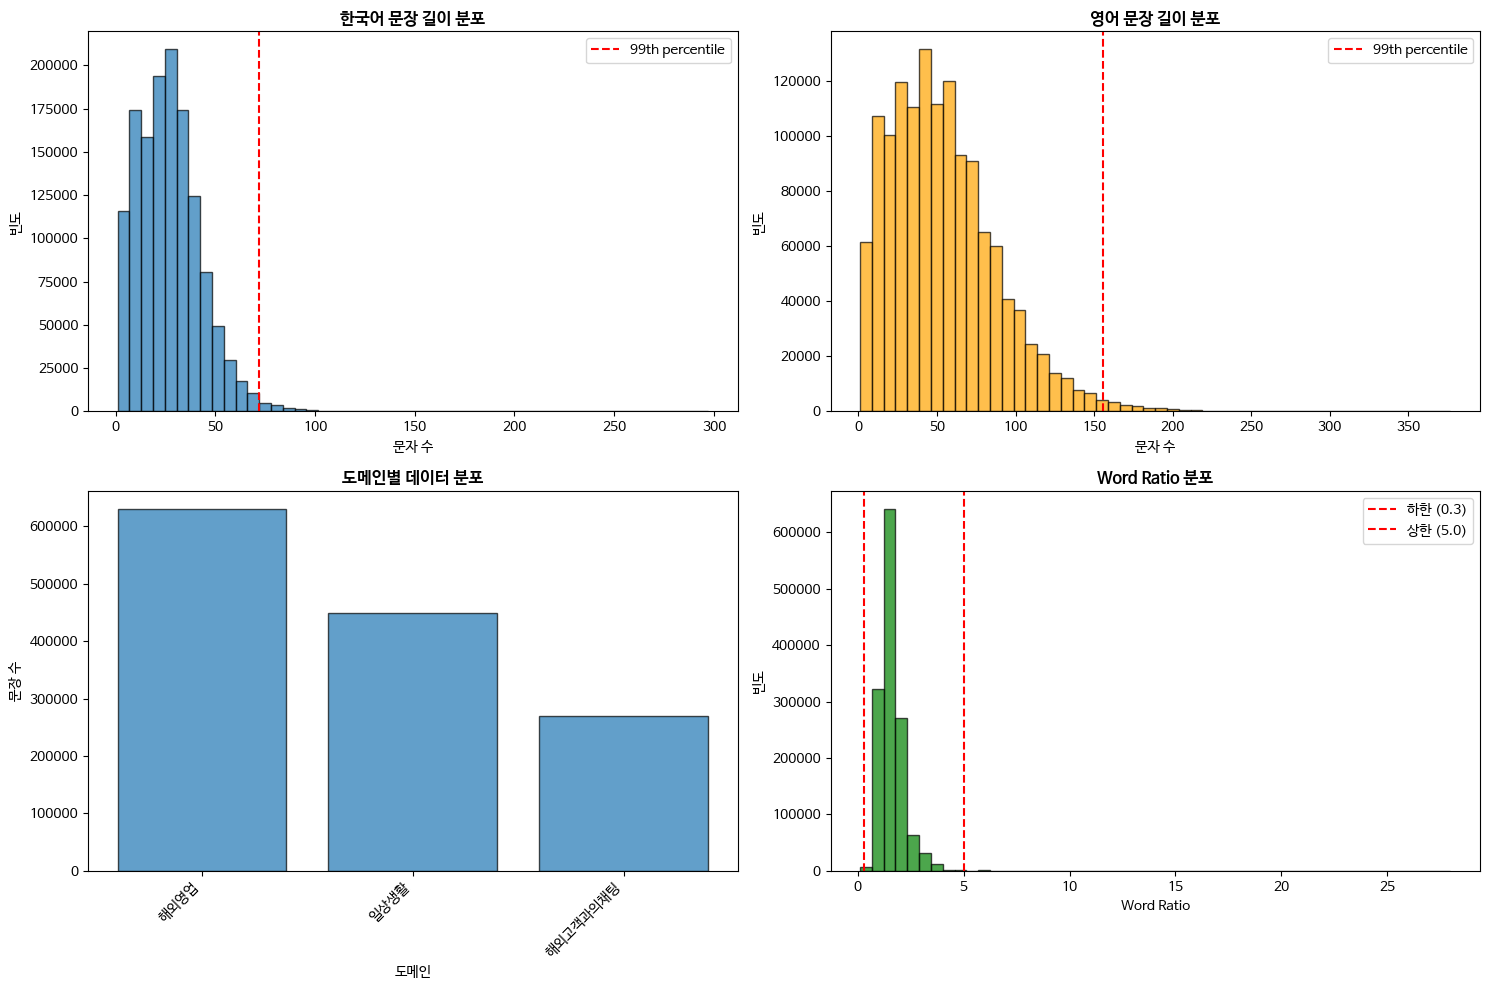


✓ 시각화 저장: data_analysis.png

[3] 데이터 품질 검사
----------------------------------------
중복 문장 비율: 12.06%
빈 한국어 문장: 0개
빈 영어 문장: 0개

특수 문자 상위 10개:
  '>': 317,854회
  '~': 14,476회
  '%': 9,258회
  ''': 4,808회
  '"': 4,805회
  ')': 4,793회
  '(': 4,715회
  '-': 4,194회
  '/': 3,049회
  ':': 1,150회
Train
Step 4: 데이터 전처리
------------------------------------------------------------
Valid
Step 4: 데이터 전처리
------------------------------------------------------------

Step 5: 전처리 결과 분석
------------------------------------------------------------

[TRAIN 전처리 통계]
----------------------------------------
처리 완료: 1,031,323개
제거된 데이터:
  - 빈 값: 0개
  - 길이 초과: 16,833개
  - word_ratio 범위 초과: 1,262개
  - 중복: 150,582개
  - 총 제거: 168,677개
  - 제거율: 14.06%

[VALID 전처리 통계]
----------------------------------------
처리 완료: 136,175개
제거된 데이터:
  - 빈 값: 0개
  - 길이 초과: 2,095개
  - word_ratio 범위 초과: 149개
  - 중복: 11,581개
  - 총 제거: 13,825개
  - 제거율: 9.22%

[전체 통합 통계]
----------------------------------------
총 처리 완료: 1,167,498개
총 제거: 182,50

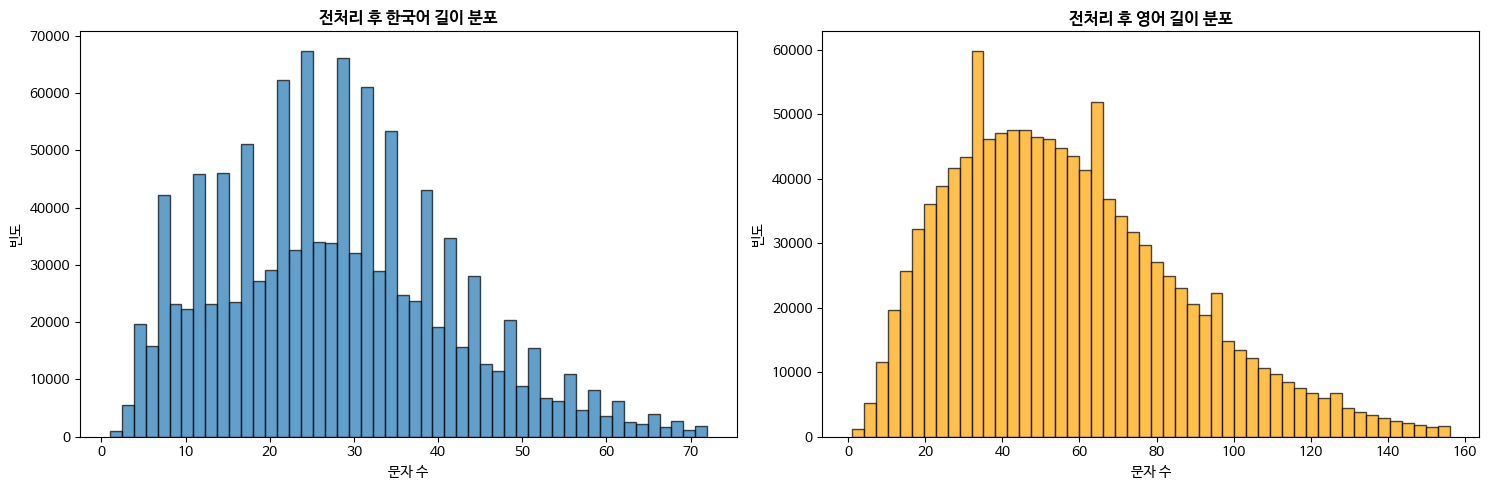


✓ 전처리 분석 시각화 저장: cleaned_analysis.png

[전처리 샘플 (처음 3개)]
----------------------------------------

샘플 1:
  ko: 원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.
  mt: if you reply to the color you want, we will start making it right away.

샘플 2:
  ko: 형님 제일 웃긴 그림이 뭔지 알아요.
  mt: i know what the funniest picture is.

샘플 3:
  ko: 속옷을?
  mt: underwear?
Step 6: 전처리 데이터 저장
------------------------------------------------------------
✓ clean_train.json 저장: 1,031,323개
✓ clean_valid.json 저장: 136,175개


Zipping:   0%|          | 0/2 [00:00<?, ?it/s]

✓ clean_data.zip 생성 완료
  저장 위치: /content/temp/clean_data.zip

✓ 전처리 파이프라인 완료


In [ ]:
# # 전처리 파이프라인 실행
preprocessor = TranslationDataPreprocessor(drive_temp_path)
preprocessor.run_pipeline()

## >설명< 전처리 중복 실행 최소화
- 전처리 결과를 파일로 저장하고
    - 전처리 파일을 클라우드 서버에 업로드 하여 학습시 해당 파일을 다운로드 받아서 진행하도록 하였습니다.

# >프로그램< 전처리 데이터 읽어오기

In [ ]:
# https://drive.google.com/file/d/1BJha3iuE9oB3Tdq1XCGuZDMUm6HLlh48/view?usp=sharing
# import gdown
# if not os.path.exists(drive_temp_download_path):
#     url = "https://drive.google.com/uc?id=1BJha3iuE9oB3Tdq1XCGuZDMUm6HLlh48"
#     gdown.download(url, drive_temp_download_path, quiet=False)
# # 다운로드 파일 사이즈
# logger.info(f"다운로드 파일 : {drive_temp_download_path} {os.path.getsize(drive_temp_download_path)} bytes")
url_clean_zip = r'https://fs.mybox.naver.com/file/download.api?resourceKey=YzB6MGN8MzQ3MjU5Nzk1MjIxMDgyNTgyNHxGfDA&svcType=MYBOX-WEB&time=1760506982930'
drive_temp_url_clean_zip = os.path.join(drive_temp_path, r'일상생활및_구체어_clean_data.zip')
download_http(url_clean_zip, drive_temp_url_clean_zip, ignore=False)  # ignore=True로 재다운로드 방지
drive_temp_url_clean_zip_unzip = unzip([drive_temp_url_clean_zip], remove_zip=False)[0]
logger.info(f"다운로드 파일 : {drive_temp_url_clean_zip} {os.path.getsize(drive_temp_url_clean_zip)} bytes")
# 2025-10-15 13:17:42 [I] 다운로드 파일 : d:\temp\일상생활및_구체어_clean_data.zip 65726573 bytes

다운로드 완료: /content/temp/일상생활및_구체어_clean_data.zip


압축 해제 중: 일상생활및_구체어_clean_data.zip:   0%|          | 0/2 [00:00<?, ?file/s]

2025-10-17 13:24:16 [I] 다운로드 파일 : /content/temp/일상생활및_구체어_clean_data.zip 65726573 bytes


압축 해제 완료: /content/temp/일상생활및_구체어_clean_data.zip.unzip


In [ ]:
# 2. 사전 다운로드
url_mecab_ko_dic_zip = r'https://github.com/Pusnow/mecab-ko-msvc/releases/download/release-0.999/mecab-ko-dic.zip'
drive_temp_mecab_ko_dic_zip = os.path.join(drive_temp_path, r'mecab-ko-dic.zip')
download_http(url_mecab_ko_dic_zip, drive_temp_mecab_ko_dic_zip, ignore=False)  # ignore=True로 재다운로드 방지
drive_temp_mecab_ko_dic_zip_unzip = unzip([drive_temp_mecab_ko_dic_zip], remove_zip=False)[0]

def get_mecab_ko_dic_path() -> Optional[str]:
    """
    MeCab 한국어 사전(mecab-ko-dic) 경로를 반환하고, 환경변수를 설정합니다.

    주요 기능:
        - 다운로드 및 압축 해제된 mecab-ko-dic 경로를 반환
        - 필수 사전 파일(sys.dic, matrix.bin, char.bin) 존재 여부 검증
        - 환경변수 MECAB_DIC_DIR을 해당 경로로 설정 (MeCab이 자동 인식 가능하도록)
        - 경로가 유효하지 않으면 None 반환 및 에러 로그 출력

    Returns:
        Optional[str]: mecab-ko-dic 경로 (존재하지 않으면 None)
    """

    mecab_dic_path = Path(drive_temp_mecab_ko_dic_zip_unzip) / 'mecab-ko-dic'

    if mecab_dic_path.exists():
        return str(mecab_dic_path)
    else:
        logger.error(f"MeCab 사전 경로 없음: {mecab_dic_path}")
        return None

# 3. 경로 검증
mecab_path = get_mecab_ko_dic_path()
if mecab_path:
    logger.info(f"MeCab 사전 경로: {mecab_path}")

    # 4. MeCab 초기화 테스트
    try:
        import MeCab
        test_tagger = MeCab.Tagger(f"-d {mecab_path}")
        test_result = test_tagger.parse("테스트")
        logger.info("MeCab 초기화 성공")
        del test_tagger
    except Exception as e:
        logger.error(f"MeCab 초기화 실패: {e}")
else:
    logger.error("MeCab 사전 경로 설정 실패 다시 실행 필요")

In [ ]:
# 2. BaseTokenizer
class BaseTokenizer(ABC):
    """
    모든 토크나이저의 공통 인터페이스 추상 클래스.

    - tokenize(text): 텍스트를 토큰 리스트로 변환
    - detokenize(tokens): 토큰 리스트를 텍스트로 복원
    - get_tokenizer_name(): 토크나이저 이름 반환

    상속받는 클래스는 반드시 위 메서드를 구현해야 함.
    """

    @abstractmethod
    def tokenize(self, text: str) -> List[str]:
        """
        입력된 텍스트를 토큰 리스트로 변환합니다.

        Args:
            text (str): 토큰화할 입력 텍스트

        Returns:
            List[str]: 토큰 리스트
        """
        pass

    @abstractmethod
    def detokenize(self, tokens: List[str]) -> str:
        """
        토큰 리스트를 텍스트로 복원합니다.

        Args:
            tokens (List[str]): 복원할 토큰 리스트

        Returns:
            str: 복원된 텍스트
        """
        pass

    @abstractmethod
    def get_tokenizer_name(self) -> str:
        """
        토크나이저의 이름을 반환합니다.

        Returns:
            str: 토크나이저 이름 (예: 'jamo', 'syllable', 'morpheme')
        """

        pass


# 3. JamoTokenizer (자소 분해)
class JamoTokenizer(BaseTokenizer):
    """
    한글 자소(초성, 중성, 종성) 단위로 분해 및 복원을 지원하는 토크나이저.

    특징:
        - 한글 음절을 초성/중성/종성으로 분해하여 토큰화
        - 영어, 숫자, 특수문자는 그대로 토큰화
        - 5단계 Fallback 복원 로직으로 자소 시퀀스를 한글 음절로 재조합
        - 복원 실패 시 개별 문자로 처리

    Methods:
        - tokenize(text): 입력 텍스트를 자소 리스트로 분해
        - detokenize(tokens): 자소 리스트를 한글 문자열로 복원 (5단계 Fallback)
        - get_tokenizer_name(): 토크나이저 이름 반환 ('jamo')
    """

    def __init__(self):
        """
        JamoTokenizer 클래스의 생성자.

        - 한글 초성, 중성, 종성 리스트 및 유니코드 범위 상수 초기화
        - 자소 분해/조합에 필요한 내부 테이블을 준비
        """

        # 초성 19개
        self.CHO = ['ㄱ', 'ㄲ', 'ㄴ', 'ㄷ', 'ㄸ', 'ㄹ', 'ㅁ', 'ㅂ', 'ㅃ',
                    'ㅅ', 'ㅆ', 'ㅇ', 'ㅈ', 'ㅉ', 'ㅊ', 'ㅋ', 'ㅌ', 'ㅍ', 'ㅎ']
        # 중성 21개
        self.JUNG = ['ㅏ', 'ㅐ', 'ㅑ', 'ㅒ', 'ㅓ', 'ㅔ', 'ㅕ', 'ㅖ', 'ㅗ', 'ㅘ',
                     'ㅙ', 'ㅚ', 'ㅛ', 'ㅜ', 'ㅝ', 'ㅞ', 'ㅟ', 'ㅠ', 'ㅡ', 'ㅢ', 'ㅣ']
        # 종성 28개 (빈 종성 포함)
        self.JONG = ['', 'ㄱ', 'ㄲ', 'ㄳ', 'ㄴ', 'ㄵ', 'ㄶ', 'ㄷ', 'ㄹ', 'ㄺ',
                     'ㄻ', 'ㄼ', 'ㄽ', 'ㄾ', 'ㄿ', 'ㅀ', 'ㅁ', 'ㅂ', 'ㅄ', 'ㅅ',
                     'ㅆ', 'ㅇ', 'ㅈ', 'ㅊ', 'ㅋ', 'ㅌ', 'ㅍ', 'ㅎ']

        self.HANGEUL_BASE = 0xAC00
        self.HANGEUL_END = 0xD7A3

    def _is_hangeul(self, char: str) -> bool:
        """
        입력된 문자가 한글 음절(가~힣)인지 판별합니다.

        Args:
            char (str): 검사할 문자 (길이 1의 문자열)

        Returns:
            bool: 한글 음절이면 True, 아니면 False
        """

        if len(char) != 1:
            return False
        code = ord(char)
        return self.HANGEUL_BASE <= code <= self.HANGEUL_END

    def _decompose_char(self, char: str) -> List[str]:
        """
        한글 1글자를 자소(초성, 중성, 종성)로 분해합니다.

        Args:
            char (str): 분해할 한글 문자 (길이 1의 문자열)

        Returns:
            List[str]: [초성, 중성, (종성)] 형태의 자소 리스트
                       한글이 아니면 [char] 반환
        """

        if not self._is_hangeul(char):
            return [char]  # 한글이 아니면 그대로 반환

        code = ord(char) - self.HANGEUL_BASE
        jong_idx = code % 28
        jung_idx = ((code - jong_idx) // 28) % 21
        cho_idx = ((code - jong_idx) // 28) // 21

        jamos = [self.CHO[cho_idx], self.JUNG[jung_idx]]
        if jong_idx > 0:
            jamos.append(self.JONG[jong_idx])

        return jamos

    def _compose_jamos(self, jamos: List[str]) -> str:
        """
        자소 리스트를 한글 음절(가~힣)로 복원합니다.

        Args:
            jamos (List[str]): [초성, 중성, (종성)] 형태의 자소 리스트

        Returns:
            str: 조합된 한글 음절(1글자). 조합 불가 시 입력 자소를 그대로 이어붙인 문자열 반환.

        Note:
            - 입력이 2개(초성+중성) 또는 3개(초성+중성+종성)일 때만 정상적으로 조합됩니다.
            - 자소가 한글 범위에 맞지 않거나 조합 불가 시, 입력 자소를 그대로 반환합니다.
        """

        if len(jamos) < 2:
            return ''.join(jamos)

        cho = jamos[0]
        jung = jamos[1]
        jong = jamos[2] if len(jamos) > 2 else ''

        try:
            cho_idx = self.CHO.index(cho)
            jung_idx = self.JUNG.index(jung)
            jong_idx = self.JONG.index(jong)

            code = self.HANGEUL_BASE + (cho_idx * 21 + jung_idx) * 28 + jong_idx
            return chr(code)
        except (ValueError, IndexError):
            return ''.join(jamos)

    def tokenize(self, text: str) -> List[str]:
        """
        입력된 텍스트를 자소(초성, 중성, 종성) 단위로 분해하여 토큰 리스트로 반환합니다.

        Args:
            text (str): 토큰화할 입력 텍스트

        Returns:
            List[str]: 자소 단위로 분해된 토큰 리스트
                - 한글 음절은 초성/중성/(종성)으로 분해
                - 영어, 숫자, 특수문자는 그대로 토큰화
        """

        tokens = []
        for char in text:
            if self._is_hangeul(char):
                tokens.extend(self._decompose_char(char))
            else:
                tokens.append(char)  # 영어, 숫자, 공백, 구두점 등
        return tokens

    def detokenize(self, tokens: List[str]) -> str:
        """
        토큰 리스트(자소)를 텍스트(한글 문자열)로 복원합니다.
        5단계 Fallback 로직을 사용하여 자소 시퀀스를 한글 음절로 재조합합니다.

        Args:
            tokens (List[str]): 복원할 자소 토큰 리스트

        Returns:
            str: 복원된 한글 문자열
                - 자소 패턴에 따라 초성/중성/(종성) 조합
                - 조합 불가 시 개별 문자로 처리

        자소 토큰을 텍스트로 복원 (5단계 Fallback)

        우선순위:
            1. 5자소 [초중종][초중] (예: "글자")
            2. 4자소 [초중][초중] (예: "하세")
            3. 3자소 [초중종] (예: "한")
            4. 2자소 [초중] (예: "하")
            5. 1자소 (조합 불가)
        """
        result = []
        i = 0

        while i < len(tokens):
            consumed = False

            # ===== 1순위: 5자소 [초중종][초중] =====
            if i + 4 < len(tokens):
                t0, t1, t2, t3, t4 = tokens[i:i+5]

                # 패턴: [초중종][초중] (종성이 다음 초성으로 사용 가능)
                if (t0 in self.CHO and t1 in self.JUNG and t2 in self.JONG[1:] and
                    t2 in self.CHO and t3 in self.JUNG):

                    char1 = self._compose_jamos([t0, t1, t2])  # 첫 글자 (초+중+종)
                    char2 = self._compose_jamos([t3, t4])      # 둘째 글자 (초+중)

                    if self._is_hangeul(char1) and self._is_hangeul(char2):
                        result.append(char1)
                        result.append(char2)
                        i += 5
                        consumed = True

            # ===== 2순위: 4자소 [초중][초중] =====
            if not consumed and i + 3 < len(tokens):
                t0, t1, t2, t3 = tokens[i:i+4]

                # 패턴: [초중][초중]
                if (t0 in self.CHO and t1 in self.JUNG and
                    t2 in self.CHO and t3 in self.JUNG):

                    char1 = self._compose_jamos([t0, t1])  # 첫 글자 (초+중)
                    char2 = self._compose_jamos([t2, t3])  # 둘째 글자 (초+중)

                    if self._is_hangeul(char1) and self._is_hangeul(char2):
                        result.append(char1)
                        result.append(char2)
                        i += 4
                        consumed = True

            # ===== 3순위: 3자소 [초중종] =====
            if not consumed and i + 2 < len(tokens):
                char = self._compose_jamos(tokens[i:i+3])
                if self._is_hangeul(char):
                    result.append(char)
                    i += 3
                    consumed = True

            # ===== 4순위: 2자소 [초중] =====
            if not consumed and i + 1 < len(tokens):
                char = self._compose_jamos(tokens[i:i+2])
                if self._is_hangeul(char):
                    result.append(char)
                    i += 2
                    consumed = True

            # ===== 5순위: 개별 토큰 =====
            if not consumed:
                result.append(tokens[i])
                i += 1

        return ''.join(result)

    def get_tokenizer_name(self) -> str:
        return "jamo"


# 4. SyllableTokenizer (음절)
class SyllableTokenizer(BaseTokenizer):
    """
    음절(한글 문자) 단위로 토큰화 및 복원을 수행하는 토크나이저.

    특징:
        - 한글, 영문, 숫자, 특수문자 등 모든 문자를 개별 음절 단위로 분리
        - 복원 시 토큰 리스트를 그대로 이어붙여 원문을 재구성
        - 자소(Jamo)와 달리 복원 로직이 필요 없음 (단순 결합)
        - 한국어 처리에 최적화, 어휘 사전 크기는 자소보다 크고 형태소보다 작음

    Methods:
        - tokenize(text): 입력 텍스트를 음절(문자) 리스트로 분리
        - detokenize(tokens): 음절 리스트를 텍스트로 결합
        - get_tokenizer_name(): 토크나이저 이름 반환 ('syllable')
    """

    def tokenize(self, text: str) -> List[str]:
        """텍스트를 음절(문자) 단위로 분리"""
        return list(text)

    def detokenize(self, tokens: List[str]) -> str:
        """음절 토큰을 텍스트로 결합"""
        return ''.join(tokens)

    def get_tokenizer_name(self) -> str:
        return "syllable"


# 5. MorphemeTokenizer (형태소)
class MorphemeTokenizer(BaseTokenizer):
    """
    형태소(Morpheme) 단위로 토큰화 및 복원을 수행하는 토크나이저.

    특징:
        - MeCab-ko 형태소 분석기를 활용하여 한국어 문장을 의미 단위(형태소)로 분리
        - 영어 등 비한글 문장은 음절 단위로 fallback 처리
        - 복원 시 토큰 리스트를 그대로 이어붙여 원문을 재구성 (공백 없이 결합)
        - 어휘 사전 크기가 가장 크고, 문맥 파악에 유리하나 전처리 시간이 오래 걸림

    Methods:
        - tokenize(text): 입력 텍스트를 형태소 리스트로 분리 (MeCab 사용)
        - detokenize(tokens): 형태소 리스트를 텍스트로 결합
        - get_tokenizer_name(): 토크나이저 이름 반환 ('morpheme')
    """

    def __init__(self, use_mecab: bool = True, dic_path: Optional[str] = None):
        """
        MorphemeTokenizer 클래스의 생성자.

        Args:
            use_mecab (bool): MeCab 형태소 분석기 사용 여부. False면 fallback(음절 단위)로 동작.
            dic_path (Optional[str]): MeCab 사전 경로. None이면 get_mecab_ko_dic_path()로 자동 탐색.

        주요 동작:
            - use_mecab=True일 때 MeCab-ko 형태소 분석기 초기화 시도
            - dic_path가 지정되지 않으면 get_mecab_ko_dic_path()로 경로 자동 탐색
            - MeCab 초기화 실패 시 use_mecab=False로 fallback (음절 토크나이저로 동작)
            - 환경변수 MECAB_DIC_DIR 설정 (Tagger 초기화 전)
            - 3단계 Fallback: 환경변수/명시적 -d 옵션/-r 옵션 순서로 Tagger 초기화
        """

        self.use_mecab = use_mecab
        self.mecab = None

        if not use_mecab:
            return

        try:
            import MeCab

            # 경로 결정
            if dic_path is None:
                dic_path = get_mecab_ko_dic_path()

            # 경로 검증
            if dic_path is None or not Path(dic_path).exists():
                raise RuntimeError(f"MeCab 사전 경로 없음: {dic_path}")

            # 환경변수 설정 (중요: Tagger 초기화 전)
            os.environ['MECAB_DIC_DIR'] = str(dic_path)

            # 3단계 Tagger 초기화
            try:
                # 시도 1: 환경변수 자동 인식
                self.mecab = MeCab.Tagger()
                logger.debug(f"MeCab 초기화 성공 (환경변수)")
            except RuntimeError:
                try:
                    # 시도 2: -d 옵션 명시
                    self.mecab = MeCab.Tagger(f"-d {dic_path}")
                    logger.debug(f"MeCab 초기화 성공 (-d 옵션)")
                except RuntimeError:
                    # 시도 3: -r 옵션 추가 (mecabrc 무시)
                    self.mecab = MeCab.Tagger(f"-d {dic_path} -r /dev/null")
                    logger.debug(f"MeCab 초기화 성공 (-r 옵션)")

            logger.info(f"MeCab 한국어 사전 로드 성공: {dic_path}")

        except ImportError as e:
            logger.error(f"MeCab 미설치: {e}")
            logger.warning("음절 토크나이저로 fallback")
            self.use_mecab = False
            raise RuntimeError("MeCab 미설치")
        except RuntimeError as e:
            logger.error(f"MeCab 초기화 실패: {e}")
            logger.warning("음절 토크나이저로 fallback")
            self.use_mecab = False
            raise RuntimeError("MeCab 초기화 실패")

    def tokenize(self, text: str) -> List[str]:
        """
        입력된 텍스트를 형태소 단위로 분리하여 토큰 리스트로 반환합니다.

        Args:
            text (str): 토큰화할 입력 텍스트

        Returns:
            List[str]: 형태소 단위로 분리된 토큰 리스트
                - MeCab이 정상 동작하면 형태소 단위로 분리
                - MeCab 미사용 또는 실패 시 음절(문자) 단위로 fallback
        """

        if self.use_mecab and self.mecab:
            parsed = self.mecab.parse(text)
            tokens = []
            for line in parsed.split('\n'):
                if '\t' in line:
                    token = line.split('\t')[0]
                    tokens.append(token)
            return tokens
        else:
            # Mecab 없으면 음절 단위로 fallback
            return list(text)

    def detokenize(self, tokens: List[str]) -> str:
        """
        토큰 리스트를 텍스트로 복원합니다.

        Args:
            tokens (List[str]): 복원할 토큰 리스트

        Returns:
            str: 복원된 텍스트
                - 자소(Jamo): 5단계 Fallback 로직으로 한글 음절 복원
                - 음절(Syllable), 형태소(Morpheme): 토큰을 단순 결합하여 원문 복원
        """

        return ''.join(tokens)

    def get_tokenizer_name(self) -> str:
        return "morpheme"


# 6. BaseVocabulary (추상 클래스)
class BaseVocabulary(ABC):
    """
    어휘 사전 추상 클래스 (Vocabulary Abstract Base Class)

    - token2idx: 토큰(str) → 인덱스(int) 매핑 딕셔너리
    - idx2token: 인덱스(int) → 토큰(str) 매핑 딕셔너리
    - PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX: 특수 토큰 인덱스 상수

    주요 메서드:
        - build_vocab: 토큰 리스트에서 어휘 사전 구축 (상속 클래스에서 구현)
        - encode: 토큰 리스트를 인덱스 리스트로 변환
        - decode: 인덱스 리스트를 토큰 리스트로 변환
        - save/load: 어휘 사전 파일 저장/로드
        - __len__: 어휘 사전 크기 반환

    상속 클래스:
        - JamoVocabulary: 자소 기반 고정 어휘
        - DynamicVocabulary: 음절/형태소 기반 동적 어휘
    """

    def __init__(self):
        """
        BaseVocabulary 생성자

        - token2idx: 토큰(str) → 인덱스(int) 매핑 딕셔너리 초기화
        - idx2token: 인덱스(int) → 토큰(str) 매핑 딕셔너리 초기화
        - PAD_IDX, UNK_IDX, SOS_IDX, EOS_IDX: 특수 토큰 인덱스 상수 지정
        - _init_special_tokens(): 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>)을 어휘 사전에 등록
        """

        self.token2idx: Dict[str, int] = {}
        self.idx2token: Dict[int, str] = {}
        self.PAD_IDX = 0
        self.UNK_IDX = 1
        self.SOS_IDX = 2
        self.EOS_IDX = 3

        # 특수 토큰 초기화
        self._init_special_tokens()

    def _init_special_tokens(self):
        """
        특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>)을 어휘 사전에 등록합니다.

        - token2idx: 토큰(str) → 인덱스(int) 매핑에 특수 토큰 추가
        - idx2token: 인덱스(int) → 토큰(str) 매핑에 특수 토큰 추가
        - 어휘 사전의 0~3번 인덱스는 항상 특수 토큰에 할당됨
        """

        special_tokens = ['<PAD>', '<UNK>', '<SOS>', '<EOS>']
        for idx, token in enumerate(special_tokens):
            self.token2idx[token] = idx
            self.idx2token[idx] = token

    @abstractmethod
    def build_vocab(self, tokens_list: List[List[str]], min_freq: int = 1):
        """
        토큰 리스트에서 어휘 사전을 구축합니다.

        Args:
            tokens_list (List[List[str]]): 전체 데이터의 토큰화된 리스트(문장별 토큰 시퀀스).
            min_freq (int, optional): 토큰 최소 등장 빈도. 이 값 미만은 어휘에 포함하지 않음. 기본값 1.

        주요 동작:
            - Counter로 전체 토큰 빈도 계산
            - min_freq 이상인 토큰만 어휘 사전에 추가 (중복 없이)
            - 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>) 이후 인덱스부터 할당
            - token2idx, idx2token 딕셔너리 동시 구축
            - 최종 어휘 크기 로깅
        """
        pass

    def encode(self, tokens: List[str]) -> List[int]:
        """
        토큰 리스트를 인덱스 리스트로 변환합니다.

        Args:
            tokens (List[str]): 변환할 토큰 리스트

        Returns:
            List[int]: 각 토큰에 해당하는 인덱스 리스트
                - 어휘 사전에 없는 토큰은 UNK_IDX로 변환
        """
        return [self.token2idx.get(token, self.UNK_IDX) for token in tokens]

    def decode(self, indices: List[int]) -> List[str]:
        """
        인덱스 리스트를 토큰 리스트로 변환합니다.

        Args:
            indices (List[int]): 변환할 인덱스 리스트

        Returns:
            List[str]: 각 인덱스에 해당하는 토큰 리스트
                - 어휘 사전에 없는 인덱스는 '<UNK>'로 변환
        """
        return [self.idx2token.get(idx, '<UNK>') for idx in indices]

    def __len__(self) -> int:
        """
        어휘 사전의 크기(토큰 개수)를 반환합니다.

        Returns:
            int: 어휘 사전에 포함된 전체 토큰 개수
        """
        return len(self.token2idx)

    def save(self, path: str):
        """
        어휘 사전을 JSON 파일로 저장합니다.

        Args:
            path (str): 저장할 파일 경로

        주요 동작:
            - token2idx, idx2token 딕셔너리를 JSON 형식으로 저장
            - idx2token의 키는 int로 변환하여 저장
        """
        with open(path, 'w', encoding='utf-8') as f:
            json.dump({
                'token2idx': self.token2idx,
                'idx2token': {int(k): v for k, v in self.idx2token.items()}
            }, f, ensure_ascii=False, indent=2)

    def load(self, path: str):
        """
        어휘 사전을 JSON 파일에서 로드합니다.

        Args:
            path (str): 로드할 파일 경로

        주요 동작:
            - JSON 파일에서 token2idx, idx2token 딕셔너리를 읽어옴
            - idx2token의 키는 int로 변환하여 저장
        """
        with open(path, 'r', encoding='utf-8') as f:
            data = json.load(f)
            self.token2idx = data['token2idx']
            self.idx2token = {int(k): v for k, v in data['idx2token'].items()}


# 7. JamoVocabulary (자소 어휘)
class JamoVocabulary(BaseVocabulary):
    """
    자소 기반 고정 어휘 사전 클래스.

    특징:
        - 한글 자소(초성, 중성, 종성), 영문자, 숫자, 주요 구두점/기호를 포함한 고정 어휘 사전 생성
        - 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>)은 항상 0~3번 인덱스에 할당
        - build_vocab()은 불필요(초기화 시 고정 어휘 자동 구축)
        - encode()/decode()로 토큰-인덱스 변환 지원
        - save()/load()로 JSON 파일 저장/로드 지원

    사용 예시:
        >>> vocab = JamoVocabulary()
        >>> idx = vocab.encode(['ㅎ', 'ㅏ', 'ㄴ'])
        >>> tokens = vocab.decode(idx)
    """

    def __init__(self):
        """
        JamoVocabulary 클래스의 생성자.

        - 상위(BaseVocabulary) 생성자 호출로 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>)을 초기화합니다.
        - _build_fixed_vocab()을 호출하여 한글 자소(초성, 중성, 종성), 영문자, 숫자, 주요 구두점/기호 등
          고정 어휘 사전을 자동으로 구축합니다.
        - 자소 기반 번역 모델에서 어휘 사전 재현성을 보장합니다.
        """
        super().__init__()
        self._build_fixed_vocab()

    def _build_fixed_vocab(self):
        """
        자소 기반 고정 어휘 사전을 구축합니다.

        - 한글 초성, 중성, 종성(종성은 빈값 포함), 영문자(대소문자), 숫자(0~9), 주요 구두점/기호를 포함합니다.
        - 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>) 이후 인덱스부터 순차적으로 할당합니다.
        - 어휘 사전의 재현성을 위해 항상 동일한 순서로 토큰을 추가합니다.
        - 이미 등록된 토큰은 중복 추가하지 않습니다.
        """
        # 초성
        cho = ['ㄱ', 'ㄲ', 'ㄴ', 'ㄷ', 'ㄸ', 'ㄹ', 'ㅁ', 'ㅂ', 'ㅃ',
               'ㅅ', 'ㅆ', 'ㅇ', 'ㅈ', 'ㅉ', 'ㅊ', 'ㅋ', 'ㅌ', 'ㅍ', 'ㅎ']
        # 중성
        jung = ['ㅏ', 'ㅐ', 'ㅑ', 'ㅒ', 'ㅓ', 'ㅔ', 'ㅕ', 'ㅖ', 'ㅗ', 'ㅘ',
                'ㅙ', 'ㅚ', 'ㅛ', 'ㅜ', 'ㅝ', 'ㅞ', 'ㅟ', 'ㅠ', 'ㅡ', 'ㅢ', 'ㅣ']
        # 종성
        jong = ['ㄱ', 'ㄲ', 'ㄳ', 'ㄴ', 'ㄵ', 'ㄶ', 'ㄷ', 'ㄹ', 'ㄺ',
                'ㄻ', 'ㄼ', 'ㄽ', 'ㄾ', 'ㄿ', 'ㅀ', 'ㅁ', 'ㅂ', 'ㅄ', 'ㅅ',
                'ㅆ', 'ㅇ', 'ㅈ', 'ㅊ', 'ㅋ', 'ㅌ', 'ㅍ', 'ㅎ']

        # 영어 소문자, 대문자
        alphabet = [chr(i) for i in range(ord('a'), ord('z')+1)]
        alphabet += [chr(i) for i in range(ord('A'), ord('Z')+1)]

        # 숫자
        digits = [str(i) for i in range(10)]

        # 구두점 및 기호
        punctuation = [' ', '.', ',', '!', '?', ';', ':', '-', '(', ')',
                      '"', "'", '/', '&', '@', '#', '$', '%']

        # 모든 토큰 합치기
        all_tokens = cho + jung + jong + alphabet + digits + punctuation

        # 인덱스 할당 (특수 토큰 이후부터)
        current_idx = 4  # PAD, UNK, SOS, EOS 이후
        for token in all_tokens:
            if token not in self.token2idx:
                self.token2idx[token] = current_idx
                self.idx2token[current_idx] = token
                current_idx += 1

    def build_vocab(self, tokens_list: List[List[str]], min_freq: int = 1):
        """
        토큰 리스트에서 어휘 사전을 구축합니다.

        Args:
            tokens_list (List[List[str]]): 전체 데이터의 토큰화된 리스트(문장별 토큰 시퀀스).
            min_freq (int, optional): 토큰 최소 등장 빈도. 이 값 미만은 어휘에 포함하지 않음. 기본값 1.

        주요 동작:
            - Counter로 전체 토큰 빈도 계산
            - min_freq 이상인 토큰만 어휘 사전에 추가 (중복 없이)
            - 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>) 이후 인덱스부터 할당
            - token2idx, idx2token 딕셔너리 동시 구축
            - 최종 어휘 크기 로깅
        """
        pass  # 이미 초기화 시 구축됨


# 8. DynamicVocabulary (동적 어휘)
class DynamicVocabulary(BaseVocabulary):
    """
    동적 어휘 사전 클래스 (음절/형태소 기반).

    특징:
        - 입력 데이터의 토큰 빈도 기반으로 어휘 사전을 동적으로 생성
        - min_freq 미만 토큰은 어휘에서 제외 (OOV 처리)
        - 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>)은 항상 0~3번 인덱스에 고정
        - encode()/decode()로 토큰-인덱스 변환 지원
        - save()/load()로 JSON 파일 저장/로드 지원

    사용 예시:
        >>> vocab = DynamicVocabulary()
        >>> vocab.build_vocab([['안', '녕'], ['하', '세', '요']], min_freq=1)
        >>> idx = vocab.encode(['안', '녕'])
        >>> tokens = vocab.decode(idx)
    """

    def build_vocab(self, tokens_list: List[List[str]], min_freq: int = 1):
        """
        데이터 기반 어휘 사전 구축 함수.

        Args:
            tokens_list (List[List[str]]): 전체 데이터의 토큰화된 리스트(문장별 토큰 시퀀스).
            min_freq (int, optional): 토큰 최소 등장 빈도. 이 값 미만은 어휘에 포함하지 않음. 기본값 1.

        주요 동작:
            - Counter로 전체 토큰 빈도 계산
            - min_freq 이상인 토큰만 어휘 사전에 추가 (중복 없이)
            - 특수 토큰(<PAD>, <UNK>, <SOS>, <EOS>) 이후 인덱스부터 할당
            - token2idx, idx2token 딕셔너리 동시 구축
            - 최종 어휘 크기 로깅
        """
        # 토큰 빈도 계산
        counter = Counter()
        for tokens in tokens_list:
            counter.update(tokens)

        # 빈도 필터링 및 인덱스 할당
        current_idx = 4  # 특수 토큰 이후
        for token, freq in counter.items():
            if freq >= min_freq and token not in self.token2idx:
                self.token2idx[token] = current_idx
                self.idx2token[current_idx] = token
                current_idx += 1

        logger.debug(f"Vocabulary size: {len(self.token2idx)}")


# 9. DataPipeline (통합 파이프라인)
class DataPipeline:
    """
    통합 데이터 전처리 및 토크나이징 파이프라인 클래스.

    주요 기능:
        - 토크나이저 타입(jamo, syllable, morpheme)별로 토크나이저 인스턴스 자동 생성
        - JSON 데이터 로드 및 전체 데이터셋 토큰화
        - 어휘 사전(Vocabulary) 자동 구축 (자소: 고정, 그 외: 동적)
        - 토큰 인덱스 변환 및 패딩, 트렁케이션 지원
        - TensorDataset 및 DataLoader 생성
        - 파이프라인별 로깅 및 디버깅 지원

    Args:
        tokenizer_type (str): 사용할 토크나이저 타입 ('jamo', 'syllable', 'morpheme')
    """

    def __init__(self, tokenizer_type='jamo'):
        """
        DataPipeline 클래스의 생성자.

        Args:
            tokenizer_type (str): 사용할 토크나이저 타입 ('jamo', 'syllable', 'morpheme').

        주요 동작:
            - tokenizer_type에 따라 한글/영문 토크나이저 인스턴스 자동 생성
            - 'jamo'는 JamoTokenizer, 'syllable'은 SyllableTokenizer, 'morpheme'은 MorphemeTokenizer 사용
            - 'morpheme' 타입의 경우 영어는 SyllableTokenizer로 처리
            - 잘못된 타입 입력 시 ValueError 발생
            - 파이프라인 초기화 로그 기록
        """

        self.tokenizer_type = tokenizer_type

        # 토크나이저 선택
        if tokenizer_type == 'jamo':
            self.ko_tokenizer = JamoTokenizer()
            self.mt_tokenizer = JamoTokenizer()
        elif tokenizer_type == 'syllable':
            self.ko_tokenizer = SyllableTokenizer()
            self.mt_tokenizer = SyllableTokenizer()
        elif tokenizer_type == 'morpheme':
            self.ko_tokenizer = MorphemeTokenizer()
            self.mt_tokenizer = SyllableTokenizer()  # 영어는 음절
        else:
            raise ValueError(f"Unknown tokenizer type: {tokenizer_type}")

        logger.debug(f"Initialized with {tokenizer_type} tokenizer")

    def load_data(self, json_path: str) -> List[Dict]:
        """
        JSON 파일에서 데이터를 로드합니다.

        Args:
            json_path (str): 불러올 JSON 파일 경로

        Returns:
            List[Dict]: 데이터 샘플의 리스트 (각 샘플은 딕셔너리)

        주요 동작:
            - 지정된 경로의 JSON 파일을 읽어 리스트 형태로 반환
            - 로드된 샘플 개수와 경로를 로그로 기록
        """
        with open(json_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        logger.debug(f"Loaded {len(data)} samples from {json_path}")
        return data

    def tokenize_dataset(self, data: List[Dict]) -> List[Dict]:
        """
        전체 데이터셋을 토크나이즈합니다.

        Args:
            data (List[Dict]): {'ko': ..., 'mt': ...} 형태의 데이터 리스트

        Returns:
            List[Dict]: {'ko_tokens': [...], 'mt_tokens': [...]} 형태의 토큰화된 데이터 리스트

        주요 동작:
            - 각 샘플의 'ko', 'mt' 필드를 각각 ko_tokenizer, mt_tokenizer로 토큰화
            - tqdm으로 진행 상황 표시
            - 토큰화 결과를 리스트에 저장하여 반환
        """
        tokenized = []
        for sample in tqdm(data, desc="Tokenizing"):
            ko_tokens = self.ko_tokenizer.tokenize(sample['ko'])
            mt_tokens = self.mt_tokenizer.tokenize(sample['mt'])

            tokenized.append({
                'ko_tokens': ko_tokens,
                'mt_tokens': mt_tokens
            })

        return tokenized

    def build_vocabularies(self, tokenized_data: List[Dict], min_freq: int = 1):
        """
        토큰화된 데이터로부터 한글/영문 어휘 사전을 구축합니다.

        Args:
            tokenized_data (List[Dict]): {'ko_tokens': [...], 'mt_tokens': [...]} 형태의 토큰화된 데이터 리스트
            min_freq (int, optional): 어휘에 포함될 최소 등장 빈도. 기본값 1.

        Returns:
            Tuple[BaseVocabulary, BaseVocabulary]: (한국어 어휘 사전, 영어 어휘 사전)

        주요 동작:
            - 토크나이저 타입에 따라 어휘 사전 클래스 선택
                * 'jamo'는 JamoVocabulary(고정 어휘), 그 외는 DynamicVocabulary(동적 어휘)
            - 동적 어휘의 경우 build_vocab()으로 실제 데이터 기반 어휘 생성
            - 각 어휘 사전의 크기 및 구축 로그 출력
        """
        # 어휘 클래스 선택
        if self.tokenizer_type == 'jamo':
            ko_vocab = JamoVocabulary()
            mt_vocab = JamoVocabulary()
        else:
            ko_vocab = DynamicVocabulary()
            mt_vocab = DynamicVocabulary()

            # 동적 어휘는 build 필요
            ko_tokens_list = [s['ko_tokens'] for s in tokenized_data]
            mt_tokens_list = [s['mt_tokens'] for s in tokenized_data]

            logger.debug("Building Korean vocabulary...")
            ko_vocab.build_vocab(ko_tokens_list, min_freq)

            logger.debug("Building English vocabulary...")
            mt_vocab.build_vocab(mt_tokens_list, min_freq)

        return ko_vocab, mt_vocab

    def pad_sequence(self, tokens: List[str], vocab: BaseVocabulary,
                     max_length: int, add_eos: bool = True) -> List[int]:
        """
        토큰 리스트를 인덱스 시퀀스로 변환하고, 지정된 길이에 맞게 패딩(PAD) 또는 트렁케이션(truncation) 처리합니다.

        Args:
            tokens (List[str]): 입력 토큰 리스트
            vocab (BaseVocabulary): 사용할 어휘 사전 객체
            max_length (int): 시퀀스 최대 길이
            add_eos (bool, optional): 시퀀스 끝에 EOS 토큰 추가 여부 (기본값: True)

        Returns:
            List[int]: 패딩/트렁케이션이 적용된 인덱스 시퀀스 리스트

        주요 동작:
            - tokens를 vocab.encode()로 인덱스 리스트로 변환
            - add_eos=True면 EOS 인덱스 추가
            - max_length보다 길면 마지막 토큰을 EOS로 대체하여 자름(truncation)
            - max_length보다 짧으면 PAD 인덱스로 패딩
        """
        indices = vocab.encode(tokens)

        if add_eos:
            indices.append(vocab.EOS_IDX)

        # 트렁케이션
        if len(indices) > max_length:
            indices = indices[:max_length-1] + [vocab.EOS_IDX]
        else:
            indices += [vocab.PAD_IDX] * (max_length - len(indices))

        return indices

    def encode_dataset(self, tokenized_data: List[Dict],
                      ko_vocab: BaseVocabulary,
                      mt_vocab: BaseVocabulary,
                      max_length: int = 200) -> List[Tuple]:
        """
        토큰화된 데이터셋을 인덱스 시퀀스로 변환하고, 패딩 및 트렁케이션을 적용합니다.

        Args:
            tokenized_data (List[Dict]): {'ko_tokens': [...], 'mt_tokens': [...]} 형태의 토큰화된 데이터 리스트
            ko_vocab (BaseVocabulary): 한국어 어휘 사전 객체
            mt_vocab (BaseVocabulary): 영어 어휘 사전 객체
            max_length (int, optional): 시퀀스 최대 길이 (기본값: 200)

        Returns:
            List[Tuple]: (src, tgt_input, tgt_output) 튜플 리스트
                - src: 패딩된 소스 인덱스 시퀀스 (한국어)
                - tgt_input: <SOS> + 타겟 인덱스 시퀀스 (Teacher Forcing용)
                - tgt_output: 타겟 인덱스 시퀀스 + <EOS> (정답 시퀀스)

        주요 동작:
            - 각 샘플의 ko_tokens, mt_tokens를 어휘 사전으로 인덱스 변환
            - pad_sequence()로 길이 맞춤 (PAD/EOS 처리)
            - tgt_input: <SOS> + 타겟 인덱스, tgt_output: 타겟 인덱스 + <EOS>
            - 길이 초과 시 마지막 토큰을 EOS로 대체하여 자름
            - 길이 부족 시 PAD로 패딩
        """
        encoded = []

        for sample in tqdm(tokenized_data, desc="Encoding"):
            # Source (한국어)
            src = self.pad_sequence(sample['ko_tokens'], ko_vocab, max_length)

            # Target input (Teacher Forcing용)
            tgt_tokens = sample['mt_tokens']
            tgt_input = [mt_vocab.SOS_IDX] + mt_vocab.encode(tgt_tokens)

            if len(tgt_input) > max_length:
                tgt_input = tgt_input[:max_length]
            else:
                tgt_input += [mt_vocab.PAD_IDX] * (max_length - len(tgt_input))

            # Target output
            tgt_output = mt_vocab.encode(tgt_tokens) + [mt_vocab.EOS_IDX]

            if len(tgt_output) > max_length:
                tgt_output = tgt_output[:max_length-1] + [mt_vocab.EOS_IDX]
            else:
                tgt_output += [mt_vocab.PAD_IDX] * (max_length - len(tgt_output))

            encoded.append((src, tgt_input, tgt_output))

        return encoded

    def create_dataloader(self, encoded_data: List[Tuple],
                          batch_size: int = 128,
                          num_workers: int = 2,
                          shuffle: bool = False
                          ) -> DataLoader:
        """
        인코딩된 데이터(패딩/트렁케이션된 인덱스 시퀀스)로부터 TensorDataset 및 DataLoader를 생성합니다.

        Args:
            encoded_data (List[Tuple]): (src, tgt_input, tgt_output) 튜플 리스트
                - src: 소스 인덱스 시퀀스 (한국어)
                - tgt_input: <SOS> + 타겟 인덱스 시퀀스 (Teacher Forcing용)
                - tgt_output: 타겟 인덱스 시퀀스 + <EOS> (정답 시퀀스)
            batch_size (int, optional): 배치 크기 (기본값: 128)
            num_workers (int, optional): DataLoader의 워커 수 (기본값: 2)
            shuffle (bool, optional): 데이터 셔플 여부 (기본값: False)

        Returns:
            DataLoader: 학습/평가용 PyTorch DataLoader 객체

        주요 동작:
            - 각 튜플(src, tgt_input, tgt_output)을 torch.LongTensor로 변환
            - TensorDataset으로 묶어 DataLoader 생성
            - pin_memory는 CUDA 사용 시 True
            - 배치 단위로 모델 학습/평가에 사용
        """
        # 텐서 데이터
        data_src = torch.tensor([x[0] for x in encoded_data], dtype=torch.long)
        data_tgt_in = torch.tensor([x[1] for x in encoded_data], dtype=torch.long)
        data_tgt_out = torch.tensor([x[2] for x in encoded_data], dtype=torch.long)
        tensor_dataset = TensorDataset(data_src, data_tgt_in, data_tgt_out)
        logger.debug(f"Loader dataset size: {len(tensor_dataset)}")

        # DataLoader
        loader = DataLoader(
            tensor_dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=torch.cuda.is_available()
        )
        logger.debug(f"Loader batches: {len(loader)}")

        return loader

logger.info("파이프라인 모듈 로드 완료")

## >설명< 자소 복원
- JamoTokenizer
    - 자소 복원이 정상적으로 동작하지 않음
        - 자소 복원을 위해 자소 분리 글자 5개를 판단하도록 프로그램 로직 수정
            - 5 : 자모자 모자... = 초중종 ...
            - 4 : 자모 자모... = 초중 ...
            - 3 : 자모자<끝> = 초중종
            - 2 : 자모<끝> = 초중
            - 1 : ㅋㅋㅋ 인터넷 슬랭
        - 자소 복원에 대하여 추가 연구 중
            - 따로 프로젝트를 만들어 연구 중
                - https://github.com/c0z0c/hangul_jamo


In [ ]:
def test_jamo_5step_fallback():
    """
    자소(Jamo) 토크나이저의 5단계 Fallback 복원 로직을 검증하는 테스트 함수.

    주요 기능:
        - 다양한 한글/비한글 케이스에 대해 자소 분해 및 복원 결과를 비교
        - 4자소, 5자소, 혼합, 슬랭 등 edge case 포함
        - 복원 결과가 원본과 일치하는지 로그로 출력

    테스트 케이스:
        1. 4자소 패턴: "하세" → ['ㅎ', 'ㅏ', 'ㅅ', 'ㅔ']
        2. 5자소 패턴: "글자" → ['ㄱ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅏ']
        3. 혼합 패턴: "하세요", "안녕"
        4. 슬랭/비한글: "ㄱㄴㄷ", "a한b"
        5. 실제 토큰화 결과 확인: "안녕하세요"

    복원 결과가 원본과 다를 경우 ✗, 일치하면 ✓로 표시
    """
    tokenizer = JamoTokenizer()

    test_cases = [
        # 4자소 패턴 (기존 실패 케이스)
        ("하세", ['ㅎ', 'ㅏ', 'ㅅ', 'ㅔ']),
        ("안녕하세요", None),  # 실제 토큰 확인

        # 5자소 패턴
        ("글자", ['ㄱ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅏ']),
        ("한글", ['ㅎ', 'ㅏ', 'ㄴ', 'ㄱ', 'ㅡ', 'ㄹ']),

        # 혼합 패턴
        ("하세요", ['ㅎ', 'ㅏ', 'ㅅ', 'ㅔ', 'ㅇ', 'ㅛ']),
        ("안녕", ['ㅇ', 'ㅏ', 'ㄴ', 'ㄴ', 'ㅕ', 'ㅇ']),

        # Edge Cases
        ("ㄱㄴㄷ", ['ㄱ', 'ㄴ', 'ㄷ']),  # 조합 불가
        ("a한b", ['a', 'ㅎ', 'ㅏ', 'ㄴ', 'b']),  # 비한글 혼합
    ]

    logger.info("="*80)
    logger.info("5단계 Fallback 테스트")
    logger.info("="*80)

    for expected, tokens in test_cases:
        if tokens is None:
            tokens = tokenizer.tokenize(expected)

        result = tokenizer.detokenize(tokens)
        status = "✓" if result == expected else "✗"

        logger.info(f"{status} 원본: {expected}")
        logger.info(f"   토큰: {tokens}")
        logger.info(f"   복원: {result}")
        logger.info(f"   일치: {result == expected}")
        logger.info("")

    logger.info("="*80)

# 실행
test_jamo_5step_fallback()

2025-10-17 13:24:16 [I] ================================================================================
2025-10-17 13:24:16 [I] 5단계 Fallback 테스트
2025-10-17 13:24:16 [I] ================================================================================
2025-10-17 13:24:16 [I] ✓ 원본: 하세
2025-10-17 13:24:16 [I]    토큰: ['ㅎ', 'ㅏ', 'ㅅ', 'ㅔ']
2025-10-17 13:24:16 [I]    복원: 하세
2025-10-17 13:24:16 [I]    일치: True
2025-10-17 13:24:16 [I] 
2025-10-17 13:24:16 [I] ✓ 원본: 안녕하세요
2025-10-17 13:24:16 [I]    토큰: ['ㅇ', 'ㅏ', 'ㄴ', 'ㄴ', 'ㅕ', 'ㅇ', 'ㅎ', 'ㅏ', 'ㅅ', 'ㅔ', 'ㅇ', 'ㅛ']
2025-10-17 13:24:16 [I]    복원: 안녕하세요
2025-10-17 13:24:16 [I]    일치: True
2025-10-17 13:24:16 [I] 
2025-10-17 13:24:16 [I] ✓ 원본: 글자
2025-10-17 13:24:16 [I]    토큰: ['ㄱ', 'ㅡ', 'ㄹ', 'ㅈ', 'ㅏ']
2025-10-17 13:24:16 [I]    복원: 글자
2025-10-17 13:24:16 [I]    일치: True
2025-10-17 13:24:16 [I] 
2025-10-17 13:24:16 [I] ✓ 원본: 한글
2025-10-17 13:24:16 [I]    토큰: ['ㅎ', 'ㅏ', 'ㄴ', 'ㄱ', 'ㅡ', 'ㄹ']
2025-10-17 13:24:16 [I]    복원: 한글
2025-10-17 13:24:16 [I]    일치

In [ ]:
# 모든 토크나이저 테스트
def test_all_tokenizers(text: str = "안녕하세요"):
    """
    3가지 토크나이저(Jamo, Syllable, Morpheme)로 입력 문장에 대해 토큰화 및 복원 테스트를 수행합니다.

    Args:
        text (str): 테스트할 입력 문장 (기본값: "안녕하세요")

    검증 항목:
        1. 각 토크나이저의 토큰화 결과 출력
        2. 디토큰화(복원) 결과가 원본과 일치하는지 확인
        3. MorphemeTokenizer의 MeCab Fallback 동작 검증

    로그:
        - 토크나이저별 토큰 리스트, 복원 결과, 성공/실패 여부를 logger로 출력
    """
    tokenizers = {
        'jamo': JamoTokenizer(),
        'syllable': SyllableTokenizer(),
        'morpheme': MorphemeTokenizer(use_mecab=True, dic_path=get_mecab_ko_dic_path())
    }

    logger.info("="*80)
    logger.info(f"토크나이저 테스트: '{text}'")
    logger.info("="*80)

    for name, tokenizer in tokenizers.items():
        logger.info(f"\n[{name.upper()}]")

        # 1. 토큰화
        tokens = tokenizer.tokenize(text)
        logger.info(f"   토큰: {tokens}")

        # 2. 디토큰화
        restored = tokenizer.detokenize(tokens)
        logger.info(f"   복원: {restored}")

        # 3. 검증
        if restored == text:
            logger.info(f"   결과: 복원 성공")
        else:
            logger.warning(f"   결과: 복원 실패 (원문 != 복원)")
            logger.warning(f"      원문: {text}")
            logger.warning(f"      복원: {restored}")

    logger.info("="*80)

# 테스트 실행
test_all_tokenizers("안녕하세요")

2025-10-17 13:24:16 [D] MeCab 초기화 성공 (-r 옵션)
2025-10-17 13:24:16 [I] MeCab 한국어 사전 로드 성공: /content/temp/mecab-ko-dic.zip.unzip/mecab-ko-dic
2025-10-17 13:24:16 [I] ================================================================================
2025-10-17 13:24:16 [I] 토크나이저 테스트: '안녕하세요'
2025-10-17 13:24:16 [I] ================================================================================
2025-10-17 13:24:16 [I] 
[JAMO]
2025-10-17 13:24:16 [I]    토큰: ['ㅇ', 'ㅏ', 'ㄴ', 'ㄴ', 'ㅕ', 'ㅇ', 'ㅎ', 'ㅏ', 'ㅅ', 'ㅔ', 'ㅇ', 'ㅛ']
2025-10-17 13:24:16 [I]    복원: 안녕하세요
2025-10-17 13:24:16 [I]    결과: 복원 성공
2025-10-17 13:24:16 [I] 
[SYLLABLE]
2025-10-17 13:24:16 [I]    토큰: ['안', '녕', '하', '세', '요']
2025-10-17 13:24:16 [I]    복원: 안녕하세요
2025-10-17 13:24:16 [I]    결과: 복원 성공
2025-10-17 13:24:16 [I] 
[MORPHEME]
2025-10-17 13:24:16 [I]    토큰: ['안녕', '하', '세요']
2025-10-17 13:24:16 [I]    복원: 안녕하세요
2025-10-17 13:24:16 [I]    결과: 복원 성공
2025-10-17 13:24:16 [I] ============================================================

In [ ]:
def extract_dataset_from_zip(zip_path: str) -> str:
    """
    ZIP 파일을 압축 해제하고, 데이터 디렉토리 경로를 반환합니다.

    Args:
        zip_path (str): 압축 해제할 ZIP 파일 경로

    Returns:
        str: 압축 해제된 데이터 디렉토리 경로

    주요 동작:
        - 이미 압축 해제된 디렉토리가 존재하면 재해제하지 않고 경로만 반환
        - helper_utils.unzip()을 사용하여 압축 해제
        - 압축 해제 후 실제 데이터 디렉토리 경로를 반환
        - 압축 해제 실패 시 RuntimeError 발생
    """
    extract_dir = zip_path + ".unzip"

    # 이미 압축 해제된 경우 스킵
    if os.path.exists(extract_dir) and os.listdir(extract_dir):
        logger.info(f"압축 해제됨 {extract_dir}")
        return extract_dir

    # helper_utils.unzip() 사용
    logger.debug(f"압축 해제 {zip_path} to {extract_dir}...")
    extracted_paths = unzip([zip_path], remove_zip=False)

    if not extracted_paths:
        raise RuntimeError(f"Failed to extract {zip_path}")

    # unzip()은 압축 해제 후 디렉토리 리스트 반환
    actual_extract_dir = extracted_paths[0]

    logger.info(f"압축 해제 완료. 파일: {os.listdir(actual_extract_dir)}")
    return actual_extract_dir

# >프로그램< Loader 함수

In [ ]:
def create_loader(data_download_path: str,
                  tokenizer_type: str='jamo',
                  batch_size=128,
                  num_workers=1,
                  DEBUG_ON: bool = False,
                  test_size: int = 1000):
    """
    토큰화 파이프라인 실행 및 DataLoader 생성

    Args:
        data_download_path (str): 다운로드된 ZIP 파일 경로
        tokenizer_type (str, optional): 사용할 토크나이저 타입 ('jamo', 'syllable', 'morpheme'). 기본값 'jamo'
        batch_size (int, optional): 배치 크기. 기본값 128
        num_workers (int, optional): DataLoader 워커 수. 기본값 1
        DEBUG_ON (bool, optional): 디버그 모드. True면 데이터 일부만 사용. 기본값 False
        test_size (int, optional): 테스트 데이터 샘플 수. 기본값 1000

    Returns:
        Tuple[DataLoader, DataLoader, DataLoader, BaseVocabulary, BaseVocabulary]:
            - train_loader: 학습용 DataLoader
            - valid_loader: 검증용 DataLoader
            - test_loader: 테스트용 DataLoader
            - ko_vocab: 한국어 어휘 사전
            - mt_vocab: 영어 어휘 사전

    주요 동작:
        1. ZIP 압축 해제 및 데이터 디렉토리 탐색
        2. DataPipeline 생성 및 토크나이저 선택
        3. 전처리된 train/valid JSON 파일 로드
        4. 토큰화 및 어휘 사전 구축 (min_freq=2)
        5. 인덱스 변환 및 패딩/트렁케이션 적용
        6. DataLoader 생성 (학습/검증/테스트)
        7. 어휘 사전 저장 (임시 경로)
        8. 샘플 배치 shape 출력 (디버그)
    """
    # 1. ZIP 압축 해제
    data_dir = extract_dataset_from_zip(data_download_path)
    logger.info(f"Step 1: Data directory: {data_dir}")

    # 2. 파이프라인 생성
    pipeline = DataPipeline(tokenizer_type=tokenizer_type)
    logger.info(f"Step 2: Pipeline created with tokenizer {pipeline.tokenizer_type}")

    # 3. 데이터 로드 (동적 경로)
    train_json_path = os.path.join(data_dir, 'clean_train.json')
    valid_json_path = os.path.join(data_dir, 'clean_valid.json')
    logger.info(f"Step 3: {train_json_path} {os.path.exists(train_json_path)} {valid_json_path} {os.path.exists(valid_json_path)}")

    train_data = pipeline.load_data(train_json_path)
    valid_data = pipeline.load_data(valid_json_path)
    if DEBUG_ON:
        test_size = 100
        train_data = train_data[:200]
        valid_data = valid_data[:100]
        logger.info(f"DEBUG_ON: Using subset of data {len(train_data)}, {len(valid_data)}")

    # 4. 토큰화
    tokenized_train = pipeline.tokenize_dataset(train_data)
    tokenized_valid = pipeline.tokenize_dataset(valid_data)
    # tokenized_train 데이터 일부만 사용 (최대 1% 또는 test_size)
    tokenized_train, tokenized_test = train_test_split(
        tokenized_train,
        test_size=min(test_size, len(tokenized_train) // 100),  # 최대 1%
        random_state=SEED,
        shuffle=True
    )

    logger.info(f'Step 4: 토큰 후 사이즈 {len(tokenized_train)}, {len(tokenized_valid)} {len(tokenized_test)}')

    # 5. 어휘 사전 구축
    ko_vocab, mt_vocab = pipeline.build_vocabularies(tokenized_train, min_freq=2)
    logger.info(f'Step 5: 어휘 사전 크기 {len(ko_vocab)}, {len(mt_vocab)}')

    # 6. 인코딩
    encoded_train = pipeline.encode_dataset(tokenized_train, ko_vocab, mt_vocab, max_length=200)
    encoded_valid = pipeline.encode_dataset(tokenized_valid, ko_vocab, mt_vocab, max_length=200)
    encoded_test = pipeline.encode_dataset(tokenized_test, ko_vocab, mt_vocab, max_length=200)
    logger.info(f'Step 6: 인코딩 후 사이즈 {len(encoded_train)}, {len(encoded_valid)}, {len(encoded_test)}')

    # 7. DataLoader 생성
    train_loader = pipeline.create_dataloader(encoded_train, batch_size=batch_size, num_workers=num_workers, shuffle=True)
    valid_loader = pipeline.create_dataloader(encoded_valid, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    test_loader = pipeline.create_dataloader(encoded_test, batch_size=batch_size, num_workers=num_workers, shuffle=False)
    logger.info(f'Step 7: DataLoader 생성 완료')

    # 8. 어휘 사전 저장 (동적 경로)
    vocab_dir = get_path_temp('vocab')
    os.makedirs(vocab_dir, exist_ok=True)

    ko_vocab_path = os.path.join(vocab_dir, 'ko_vocab.json')
    mt_vocab_path = os.path.join(vocab_dir, 'mt_vocab.json')

    ko_vocab.save(ko_vocab_path)
    mt_vocab.save(mt_vocab_path)

    logger.info(f"Step 8: Vocabularies saved to {vocab_dir}")

    # 9. 샘플 출력
    for batch in train_loader:
        src, tgt_in, tgt_out = batch
        logger.debug(f"Source shape: {src.shape}")
        logger.debug(f"Target input shape: {tgt_in.shape}")
        logger.debug(f"Target output shape: {tgt_out.shape}")
        break

    logger.info("Step 9: Tokenization pipeline ready!")
    return train_loader, valid_loader, test_loader, ko_vocab, mt_vocab



# >프로그램< Loader

In [ ]:
if not RUN_PROCESS['전체 파이프라인']:
    train_loader, valid_loader, test_loader, ko_vocab, mt_vocab = create_loader(
        data_download_path=drive_temp_download_path,
        tokenizer_type=RUN_PROCESS['TOKENIZER'][0],
        DEBUG_ON=DEBUG_ON
        )
    logger.info(f"Train batches: {len(train_loader)}, Valid batches: {len(valid_loader)}, Test batches: {len(test_loader)}")
    logger.info(f"Korean Vocab size: {len(ko_vocab)}, English Vocab size: {len(mt_vocab)}")

# >프로그램< 모델 클래스

In [ ]:
# 모델 학습 클래스

"""
기계 번역 프로젝트: 모델 학습 및 평가 파이프라인

모델:
- BasicSeq2Seq: GRU 기반 Encoder-Decoder
- AttentionSeq2Seq: Bahdanau Attention 적용
- TransformerSeq2Seq: Transformer 기반 (선택)

주요 기능:
- 학습 파이프라인: 모델 학습, 검증, 체크포인트 저장
- 평가 파이프라인: BLEU, 샘플 번역 출력
- 시각화: 학습 곡선, Attention 히트맵
"""

# 1. 모델 클래스들
class Encoder(nn.Module):
    """
    GRU 기반 인코더 클래스.

    Args:
        vocab_size (int): 입력 어휘 사전 크기.
        embed_dim (int): 임베딩 차원.
        hidden_dim (int): GRU 은닉 상태 차원.
        num_layers (int, optional): GRU 레이어 수. 기본값 1.
        dropout (float, optional): 드롭아웃 비율. 기본값 0.1.

    주요 동작:
        - 입력 시퀀스를 임베딩 후 GRU로 인코딩.
        - 마지막 은닉 상태(hidden)를 디코더에 전달.
        - 배치 단위 입력 지원(batch_first=True).
        - num_layers > 1일 때만 드롭아웃 적용.

    Returns:
        outputs: [batch_size, seq_len, hidden_dim] - 전체 시퀀스의 은닉 상태
        hidden: [num_layers, batch_size, hidden_dim] - 마지막 은닉 상태
    """

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int,
                 num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        """
        Encoder 클래스 생성자.

        Args:
            vocab_size (int): 입력 어휘 사전 크기 (Embedding 레이어 크기).
            embed_dim (int): 임베딩 차원.
            hidden_dim (int): GRU 은닉 상태 차원.
            num_layers (int, optional): GRU 레이어 수. 기본값 1.
            dropout (float, optional): 드롭아웃 비율. 기본값 0.1.

        주요 동작:
            - nn.Embedding: 입력 시퀀스를 임베딩 벡터로 변환.
            - nn.GRU: 임베딩 벡터를 GRU로 인코딩 (batch_first=True).
            - nn.Dropout: 임베딩에 드롭아웃 적용.
            - num_layers > 1일 때만 GRU에 드롭아웃 적용.

        Returns:
            None
        """

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        """
        인코더의 순전파(forward) 함수.

        Args:
            src (torch.Tensor): 입력 시퀀스 텐서 [batch_size, seq_len]
                - 각 값은 토큰 인덱스(어휘 사전 기준)

        Returns:
            outputs (torch.Tensor): 전체 시퀀스의 은닉 상태 [batch_size, seq_len, hidden_dim]
            hidden (torch.Tensor): 마지막 은닉 상태 [num_layers, batch_size, hidden_dim]

        주요 동작:
            1. 입력 시퀀스를 임베딩 벡터로 변환 (nn.Embedding)
            2. 드롭아웃 적용 (nn.Dropout)
            3. GRU로 인코딩 (nn.GRU)
                - outputs: 모든 시점의 은닉 상태
                - hidden: 마지막 시점의 은닉 상태 (디코더에 전달)
        """
        embedded = self.dropout(self.embedding(src))
        outputs, hidden = self.gru(embedded)
        return outputs, hidden


class Decoder(nn.Module):
    """
    GRU 기반 디코더 클래스.

    Args:
        vocab_size (int): 출력 어휘 사전 크기.
        embed_dim (int): 임베딩 차원.
        hidden_dim (int): GRU 은닉 상태 차원.
        num_layers (int, optional): GRU 레이어 수. 기본값 1.
        dropout (float, optional): 드롭아웃 비율. 기본값 0.1.

    주요 동작:
        - 입력 시퀀스를 임베딩 후 GRU로 디코딩.
        - Teacher Forcing 지원: 이전 타겟 시퀀스를 입력으로 사용.
        - GRU 출력에 대해 분류층(fc)로 어휘 분포 예측.
        - 배치 단위 입력 지원(batch_first=True).
        - num_layers > 1일 때만 드롭아웃 적용.

    Returns:
        output: [batch_size, seq_len, vocab_size] - 각 시점별 예측 확률 분포
        hidden: [num_layers, batch_size, hidden_dim] - 마지막 은닉 상태
    """

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int,
                 num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        """
        Decoder 클래스 생성자.

        Args:
            vocab_size (int): 출력 어휘 사전 크기 (Embedding 및 출력 레이어 크기).
            embed_dim (int): 임베딩 차원.
            hidden_dim (int): GRU 은닉 상태 차원.
            num_layers (int, optional): GRU 레이어 수. 기본값 1.
            dropout (float, optional): 드롭아웃 비율. 기본값 0.1.

        주요 동작:
            - nn.Embedding: 입력 시퀀스를 임베딩 벡터로 변환.
            - nn.GRU: 임베딩 벡터를 GRU로 디코딩 (batch_first=True).
            - nn.Linear: GRU 출력 → 어휘 분포 예측.
            - nn.Dropout: 임베딩에 드롭아웃 적용.
            - num_layers > 1일 때만 GRU에 드롭아웃 적용.

        Returns:
            None
        """
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, hidden):
        """
        디코더의 순전파(forward) 함수.

        Args:
            tgt (torch.Tensor): 입력 시퀀스 텐서 [batch_size, seq_len]
                - 이전 타겟 시퀀스(Teacher Forcing용), 각 값은 토큰 인덱스
            hidden (torch.Tensor): 인코더에서 전달받은 은닉 상태 [num_layers, batch_size, hidden_dim]

        Returns:
            output (torch.Tensor): 각 시점별 예측 확률 분포 [batch_size, seq_len, vocab_size]
            hidden (torch.Tensor): 마지막 은닉 상태 [num_layers, batch_size, hidden_dim]

        주요 동작:
            1. 입력 시퀀스를 임베딩 벡터로 변환 (nn.Embedding)
            2. 드롭아웃 적용 (nn.Dropout)
            3. GRU로 디코딩 (nn.GRU)
                - output: 모든 시점의 GRU 출력
                - hidden: 마지막 시점의 은닉 상태
            4. GRU 출력에 대해 분류층(fc)로 어휘 분포 예측 (nn.Linear)
        """
        embedded = self.dropout(self.embedding(tgt))
        output, hidden = self.gru(embedded, hidden)
        output = self.fc(output)
        return output, hidden


class BahdanauAttention(nn.Module):
    """
    Bahdanau 어텐션(Bahdanau Attention) 메커니즘 클래스.

    Args:
        hidden_dim (int): 인코더/디코더 은닉 상태 차원.

    주요 동작:
        - 디코더의 현재 은닉 상태(query)와 인코더의 모든 은닉 상태(keys)를 입력받아
          각 소스 토큰에 대한 어텐션 스코어를 계산.
        - 어텐션 가중치(softmax)를 통해 컨텍스트 벡터(context)를 생성.
        - 컨텍스트 벡터는 디코더 입력에 결합되어 번역 품질을 향상시킴.

    수식:
        e_{ij} = v^T tanh(W_1 h_j + W_2 s_i)
        α_{ij} = softmax(e_{ij})
        c_i = Σ_j α_{ij} h_j

    Returns:
        context (torch.Tensor): 컨텍스트 벡터 [batch_size, 1, hidden_dim]
        attention_weights (torch.Tensor): 어텐션 가중치 [batch_size, 1, src_seq_len]
    """

    def __init__(self, hidden_dim: int):
        super().__init__()
        """
        BahdanauAttention 클래스의 생성자.

        Args:
            hidden_dim (int): 인코더/디코더 은닉 상태 차원.
                - 어텐션 스코어 계산 및 컨텍스트 벡터 생성에 사용되는 차원.
        주요 동작:
            - W1, W2: 은닉 상태 차원에서 차원 변환을 위한 선형 레이어.
            - V: 어텐션 스코어를 1차원으로 변환하는 선형 레이어.
        """
        self.W1 = nn.Linear(hidden_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, query, keys):
        """
        BahdanauAttention의 순전파(forward) 함수.

        Args:
            query (torch.Tensor): 디코더의 현재 은닉 상태 [batch_size, 1, hidden_dim]
            keys (torch.Tensor): 인코더의 전체 은닉 상태 [batch_size, seq_len, hidden_dim]

        Returns:
            context (torch.Tensor): 어텐션 컨텍스트 벡터 [batch_size, 1, hidden_dim]
            attention_weights (torch.Tensor): 어텐션 가중치 [batch_size, 1, src_seq_len]

        주요 동작:
            1. query와 keys를 선형 변환(W1, W2) 후 합산하여 tanh 활성화.
            2. V를 통해 어텐션 스코어 계산 후 softmax로 가중치 산출.
            3. 가중치로 keys를 가중합하여 context 벡터 생성.
        """
        # query: [batch_size, 1, hidden_dim]
        # keys: [batch_size, seq_len, hidden_dim]

        # Compute attention scores
        scores = self.V(torch.tanh(
            self.W1(query) + self.W2(keys)
        ))  # [batch_size, seq_len, 1]

        # Attention weights
        attention_weights = torch.softmax(scores, dim=1)  # [batch_size, seq_len, 1]

        # Context vector
        context = torch.sum(attention_weights * keys, dim=1, keepdim=True)  # [batch_size, 1, hidden_dim]

        return context, attention_weights.transpose(1, 2)  # [batch_size, 1, seq_len]


class AttentionDecoder(nn.Module):
    """
    Bahdanau 어텐션(Bahdanau Attention)을 적용한 GRU 기반 디코더 클래스.

    Args:
        vocab_size (int): 출력 어휘 사전 크기.
        embed_dim (int): 임베딩 차원.
        hidden_dim (int): GRU 은닉 상태 차원.
        num_layers (int, optional): GRU 레이어 수. 기본값 1.
        dropout (float, optional): 드롭아웃 비율. 기본값 0.1.

    주요 동작:
        - 입력 시퀀스를 임베딩 후, 각 디코딩 시점마다 인코더 은닉 상태와 어텐션 연산.
        - BahdanauAttention을 통해 컨텍스트 벡터 생성 후 GRU 입력에 결합.
        - GRU 출력에 대해 분류층(fc)로 어휘 분포 예측.
        - Teacher Forcing 및 배치 단위 입력 지원.
        - 어텐션 가중치 반환(시각화 및 분석용).

    Returns:
        output: [batch_size, seq_len, vocab_size] - 각 시점별 예측 확률 분포
        hidden: [num_layers, batch_size, hidden_dim] - 마지막 은닉 상태
        attention_weights: [batch_size, seq_len, src_seq_len] - 어텐션 가중치
    """

    def __init__(self, vocab_size: int, embed_dim: int, hidden_dim: int,
                 num_layers: int = 1, dropout: float = 0.1):
        super().__init__()
        """
        AttentionDecoder 클래스의 생성자.

        Args:
            vocab_size (int): 출력 어휘 사전 크기 (Embedding 및 출력 레이어 크기).
            embed_dim (int): 임베딩 차원.
            hidden_dim (int): GRU 은닉 상태 차원.
            num_layers (int, optional): GRU 레이어 수. 기본값 1.
            dropout (float, optional): 드롭아웃 비율. 기본값 0.1.

        주요 동작:
            - nn.Embedding: 입력 시퀀스를 임베딩 벡터로 변환.
            - BahdanauAttention: 인코더 은닉 상태와 디코더 은닉 상태로 어텐션 가중치 및 컨텍스트 벡터 생성.
            - nn.GRU: 임베딩 벡터와 컨텍스트 벡터를 결합하여 디코딩 (batch_first=True).
            - nn.Linear: GRU 출력 → 어휘 분포 예측.
            - nn.Dropout: 임베딩에 드롭아웃 적용.
            - num_layers > 1일 때만 GRU에 드롭아웃 적용.

        Returns:
            None
        """
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim)
        self.gru = nn.GRU(
            embed_dim + hidden_dim,  # embedded + context
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, tgt, hidden, encoder_outputs):
        """
        AttentionDecoder의 순전파(forward) 함수.

        Args:
            tgt (torch.Tensor): 입력 시퀀스 텐서 [batch_size, seq_len]
                - 이전 타겟 시퀀스(Teacher Forcing용), 각 값은 토큰 인덱스
            hidden (torch.Tensor): 인코더에서 전달받은 은닉 상태 [num_layers, batch_size, hidden_dim]
            encoder_outputs (torch.Tensor): 인코더의 전체 은닉 상태 [batch_size, src_seq_len, hidden_dim]

        Returns:
            output (torch.Tensor): 각 시점별 예측 확률 분포 [batch_size, seq_len, vocab_size]
            hidden (torch.Tensor): 마지막 은닉 상태 [num_layers, batch_size, hidden_dim]
            attention_weights (torch.Tensor): 어텐션 가중치 [batch_size, seq_len, src_seq_len]

        주요 동작:
            1. 입력 시퀀스를 임베딩 벡터로 변환 (nn.Embedding)
            2. 각 디코딩 시점마다 BahdanauAttention으로 컨텍스트 벡터 생성
            3. 임베딩 벡터와 컨텍스트 벡터를 결합하여 GRU 입력으로 사용
            4. GRU 출력에 대해 분류층(fc)로 어휘 분포 예측
            5. 모든 시점의 출력과 어텐션 가중치 리스트 반환
        """
        batch_size = tgt.size(0)
        seq_len = tgt.size(1)

        embedded = self.dropout(self.embedding(tgt))  # [batch_size, seq_len, embed_dim]

        outputs = []
        attention_weights_list = []

        for t in range(seq_len):
            # 현재 시점의 embedded input
            input_t = embedded[:, t:t+1, :]  # [batch_size, 1, embed_dim]

            # Attention
            context, attn_weights = self.attention(
                hidden[-1:].transpose(0, 1),  # [batch_size, 1, hidden_dim]
                encoder_outputs
            )
            attention_weights_list.append(attn_weights)

            # Concat embedded input and context
            rnn_input = torch.cat([input_t, context], dim=2)  # [batch_size, 1, embed_dim + hidden_dim]

            # GRU step
            output, hidden = self.gru(rnn_input, hidden)

            # Output projection
            output = self.fc(output)  # [batch_size, 1, vocab_size]
            outputs.append(output)

        outputs = torch.cat(outputs, dim=1)  # [batch_size, seq_len, vocab_size]
        attention_weights = torch.cat(attention_weights_list, dim=1)  # [batch_size, seq_len, src_seq_len]

        return outputs, hidden, attention_weights


class BasicSeq2Seq(nn.Module):
    """
    기본 Seq2Seq(Encoder-Decoder) 기계 번역 모델 클래스.

    Args:
        config (Dict): 모델 하이퍼파라미터 및 어휘 정보 딕셔너리
            - src_vocab_size (int): 소스(한국어) 어휘 사전 크기
            - tgt_vocab_size (int): 타겟(영어) 어휘 사전 크기
            - embed_dim (int): 임베딩 차원
            - hidden_dim (int): GRU 은닉 상태 차원
            - num_layers (int): GRU 레이어 수
            - dropout (float): 드롭아웃 비율

    주요 동작:
        - Encoder: 입력 시퀀스를 임베딩 후 GRU로 인코딩, 마지막 은닉 상태 반환
        - Decoder: Teacher Forcing 방식으로 이전 타겟 시퀀스를 입력받아 GRU로 디코딩
        - 인코더의 마지막 은닉 상태만 디코더에 전달 (어텐션 미적용)
        - 각 시점별 예측 확률 분포 반환

    Returns:
        output (torch.Tensor): [batch_size, tgt_seq_len, vocab_size] 각 시점별 예측 확률 분포
    """

    def __init__(self, config: Dict):
        super().__init__()
        """
        BasicSeq2Seq 클래스의 생성자.

        Args:
            config (Dict): 모델 하이퍼파라미터 및 어휘 정보 딕셔너리
                - src_vocab_size (int): 소스(한국어) 어휘 사전 크기
                - tgt_vocab_size (int): 타겟(영어) 어휘 사전 크기
                - embed_dim (int): 임베딩 차원
                - hidden_dim (int): GRU 은닉 상태 차원
                - num_layers (int): GRU 레이어 수
                - dropout (float): 드롭아웃 비율

        주요 동작:
            - Encoder: 입력 시퀀스를 임베딩 후 GRU로 인코딩
            - Decoder: Teacher Forcing 방식으로 이전 타겟 시퀀스를 입력받아 GRU로 디코딩
            - 인코더의 마지막 은닉 상태만 디코더에 전달 (어텐션 미적용)
        """

        self.config = config

        self.encoder = Encoder(
            vocab_size=config['src_vocab_size'],
            embed_dim=config['embed_dim'],
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout']
        )

        self.decoder = Decoder(
            vocab_size=config['tgt_vocab_size'],
            embed_dim=config['embed_dim'],
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout']
        )

    def forward(self, src, tgt):
        """
        모델의 순전파(forward) 함수.

        Args:
            src (torch.Tensor): 소스 시퀀스 (한국어) [batch_size, src_seq_len]
            tgt (torch.Tensor): 타겟 시퀀스 (영어, Teacher Forcing용) [batch_size, tgt_seq_len]

        Returns:
            output (torch.Tensor): 각 시점별 예측 확률 분포 [batch_size, tgt_seq_len, vocab_size]

        동작:
            1. 인코더에 src 입력 → encoder_outputs, hidden 반환
            2. 디코더에 tgt와 hidden 입력 → output 반환
            3. output: 각 시점별 어휘 분포 (CrossEntropyLoss 등에서 사용)
        """
        encoder_outputs, hidden = self.encoder(src)
        output, _ = self.decoder(tgt, hidden)
        return output


class AttentionSeq2Seq(nn.Module):
    """
    Bahdanau Attention이 적용된 Seq2Seq 기계 번역 모델 클래스.

    Args:
        config (Dict): 모델 하이퍼파라미터 및 어휘 정보 딕셔너리
            - src_vocab_size (int): 소스(한국어) 어휘 사전 크기
            - tgt_vocab_size (int): 타겟(영어) 어휘 사전 크기
            - embed_dim (int): 임베딩 차원
            - hidden_dim (int): GRU 은닉 상태 차원
            - num_layers (int): GRU 레이어 수
            - dropout (float): 드롭아웃 비율

    주요 동작:
        - Encoder: 입력 시퀀스를 임베딩 후 GRU로 인코딩, 전체 은닉 상태 반환
        - AttentionDecoder: 각 디코딩 시점마다 인코더 은닉 상태와 어텐션 연산
        - BahdanauAttention: 디코더 은닉 상태와 인코더 은닉 상태로 어텐션 가중치 및 컨텍스트 벡터 생성
        - Teacher Forcing 방식으로 이전 타겟 시퀀스를 입력받아 디코딩
        - 각 시점별 예측 확률 분포와 어텐션 가중치 반환

    Returns:
        output (torch.Tensor): [batch_size, tgt_seq_len, vocab_size] 각 시점별 예측 확률 분포
        attention_weights (torch.Tensor): [batch_size, tgt_seq_len, src_seq_len] 어텐션 가중치
    """

    def __init__(self, config: Dict):
        super().__init__()
        """
        AttentionSeq2Seq 클래스의 생성자.

        Args:
            config (Dict): 모델 하이퍼파라미터 및 어휘 정보 딕셔너리
                - src_vocab_size (int): 소스(한국어) 어휘 사전 크기
                - tgt_vocab_size (int): 타겟(영어) 어휘 사전 크기
                - embed_dim (int): 임베딩 차원
                - hidden_dim (int): GRU 은닉 상태 차원
                - num_layers (int): GRU 레이어 수
                - dropout (float): 드롭아웃 비율

        주요 동작:
            - Encoder: 입력 시퀀스를 임베딩 후 GRU로 인코딩, 전체 은닉 상태 반환
            - AttentionDecoder: 각 디코딩 시점마다 인코더 은닉 상태와 어텐션 연산
            - BahdanauAttention: 디코더 은닉 상태와 인코더 은닉 상태로 어텐션 가중치 및 컨텍스트 벡터 생성
            - Teacher Forcing 방식으로 이전 타겟 시퀀스를 입력받아 디코딩
            - 각 시점별 예측 확률 분포와 어텐션 가중치 반환
        """

        self.config = config

        self.encoder = Encoder(
            vocab_size=config['src_vocab_size'],
            embed_dim=config['embed_dim'],
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout']
        )

        self.decoder = AttentionDecoder(
            vocab_size=config['tgt_vocab_size'],
            embed_dim=config['embed_dim'],
            hidden_dim=config['hidden_dim'],
            num_layers=config['num_layers'],
            dropout=config['dropout']
        )

    def forward(self, src, tgt):
        """
        모델의 순전파(forward) 함수.

        Args:
            src (torch.Tensor): 소스 시퀀스 (한국어) [batch_size, src_seq_len]
            tgt (torch.Tensor): 타겟 시퀀스 (영어, Teacher Forcing용) [batch_size, tgt_seq_len]

        Returns:
            output (torch.Tensor): 각 시점별 예측 확률 분포 [batch_size, tgt_seq_len, vocab_size]

        동작:
            1. 인코더에 src 입력 → encoder_outputs, hidden 반환
            2. 디코더에 tgt와 hidden 입력 → output 반환
            3. output: 각 시점별 어휘 분포 (CrossEntropyLoss 등에서 사용)
        """
        encoder_outputs, hidden = self.encoder(src)
        output, _, attention_weights = self.decoder(tgt, hidden, encoder_outputs)
        return output, attention_weights

# 평가 지표 계산 클래스
class MetricsCalculator:
    """
    번역 평가 지표 계산 클래스.

    주요 기능:
        - 토큰 정확도(Token Accuracy), 시퀀스 정확도(Sequence Accuracy) 계산
        - BLEU, ROUGE-L, chrF 등 번역 품질 지표 계산 (sacrebleu, rouge-score 활용)
        - 인덱스 → 텍스트 변환 및 토크나이저 복원 지원
        - 배치 단위 평가 및 전체 평가 결과 반환

    Args:
        mt_vocab: 타겟(영어) 어휘 사전 객체
        tokenizer: 토크나이저 인스턴스 (자소/음절/형태소)
        enable_rouge (bool): ROUGE-L 계산 활성화 여부
        enable_chrf (bool): chrF 계산 활성화 여부

    Returns:
        dict: 평가 지표 결과 (token_acc, seq_acc, bleu, rouge_l, chrf 등)
    """

    def __init__(self, mt_vocab, tokenizer=None, enable_rouge: bool = False, enable_chrf: bool = False):
        """
        MetricsCalculator 클래스의 생성자.

        Args:
            mt_vocab: 타겟(영어) 어휘 사전 객체 (BaseVocabulary 또는 DynamicVocabulary)
            tokenizer: 토크나이저 인스턴스 (JamoTokenizer, SyllableTokenizer, MorphemeTokenizer 등)
            enable_rouge (bool): ROUGE-L 평가 지표 활성화 여부 (True 시 rouge-score 사용)
            enable_chrf (bool): chrF 평가 지표 활성화 여부 (True 시 sacrebleu.CHRF 사용)

        주요 동작:
            - BLEU, ROUGE-L, chrF 등 번역 품질 지표 객체 초기화
            - PAD/EOS 인덱스 저장 (평가 시 특수 토큰 제외)
            - 토크나이저를 통한 인덱스→텍스트 복원 지원
            - 선택적 평가 지표(ROUGE-L, chrF) 활성화 시 관련 scorer 객체 생성
        """
        self.mt_vocab = mt_vocab
        self.tokenizer = tokenizer
        self.PAD_IDX = mt_vocab.PAD_IDX
        self.EOS_IDX = mt_vocab.EOS_IDX

        # 기존 지표
        self.bleu = sacrebleu.BLEU()

        # 선택적 지표
        self.enable_rouge = enable_rouge
        self.enable_chrf = enable_chrf

        if enable_rouge:
            self.rouge_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
            logger.debug("ROUGE-L 스코어러 초기화 완료")

        if enable_chrf:
            self.chrf = sacrebleu.CHRF(word_order=0)  # character n-gram F-score
            logger.debug("chrF 스코어러 초기화 완료")

    def indices_to_text(self, indices: List[int]) -> str:
        """
        인덱스 시퀀스를 텍스트(문장)로 변환하는 함수.

        Args:
            indices (List[int]): 어휘 사전 인덱스 리스트 (PAD/EOS/UNK/SOS 포함 가능)

        Returns:
            str: 복원된 텍스트 문자열 (특수 토큰 제거 + detokenize)

        주요 동작:
            - PAD, UNK, SOS, EOS 인덱스 제거
            - 어휘 사전(idx2token)으로 토큰 리스트 복원
            - 토크나이저가 있으면 detokenize로 원문 복원, 없으면 단순 결합
        """
        filtered = [
            idx for idx in indices
            if idx not in [self.PAD_IDX, self.mt_vocab.UNK_IDX, self.mt_vocab.SOS_IDX, self.EOS_IDX]
        ]

        tokens = self.mt_vocab.decode(filtered)

        if self.tokenizer and hasattr(self.tokenizer, 'detokenize'):
            text = self.tokenizer.detokenize(tokens)
        else:
            text = ''.join(tokens)

        return text

    def compute_token_accuracy(self, pred_indices: torch.Tensor, tgt_indices: torch.Tensor) -> float:
        """
        토큰 단위 정확도(Token-level Accuracy)를 계산하는 함수.

        Args:
            pred_indices (torch.Tensor): 모델이 예측한 토큰 인덱스 시퀀스 [batch, seq_len]
            tgt_indices (torch.Tensor): 정답 토큰 인덱스 시퀀스 [batch, seq_len]

        Returns:
            float: PAD 토큰을 제외한 토큰 단위 정확도 (0.0 ~ 1.0)

        주요 동작:
            - tgt_indices에서 PAD 인덱스가 아닌 위치만 마스크(mask)로 선택
            - 예측값과 정답값이 일치하는 토큰 개수(correct) 집계
            - 전체 비교 가능한 토큰 개수(total)로 나누어 정확도 반환
        """
        mask = (tgt_indices != self.PAD_IDX)
        correct = ((pred_indices == tgt_indices) & mask).sum().item()
        total = mask.sum().item()
        return correct / total if total > 0 else 0.0

    def compute_sequence_accuracy(self, pred_indices: torch.Tensor, tgt_indices: torch.Tensor) -> float:
        """
        시퀀스 단위 정확도(Sequence-level Accuracy, Exact Match)를 계산하는 함수.

        Args:
            pred_indices (torch.Tensor): 모델이 예측한 토큰 인덱스 시퀀스 [batch, seq_len]
            tgt_indices (torch.Tensor): 정답 토큰 인덱스 시퀀스 [batch, seq_len]

        Returns:
            float: 배치 내에서 EOS 토큰 전까지 예측 시퀀스와 정답 시퀀스가 완전히 일치한 비율 (0.0 ~ 1.0)

        주요 동작:
            - 각 배치별로 예측/정답 시퀀스에서 EOS 토큰 위치를 탐색
            - EOS 이전까지의 길이가 다르면 불일치로 처리
            - EOS 이전까지의 모든 토큰이 일치하면 exact_matches 카운트 증가
            - 전체 배치 대비 exact_matches 비율 반환
        """
        batch_size = pred_indices.size(0)
        exact_matches = 0

        for i in range(batch_size):
            pred_eos_pos = (pred_indices[i] == self.EOS_IDX).nonzero(as_tuple=True)[0]
            tgt_eos_pos = (tgt_indices[i] == self.EOS_IDX).nonzero(as_tuple=True)[0]

            pred_len = pred_eos_pos[0].item() if len(pred_eos_pos) > 0 else len(pred_indices[i])
            tgt_len = tgt_eos_pos[0].item() if len(tgt_eos_pos) > 0 else len(tgt_indices[i])

            if pred_len != tgt_len:
                continue

            if torch.equal(pred_indices[i, :pred_len], tgt_indices[i, :tgt_len]):
                exact_matches += 1

        return exact_matches / batch_size if batch_size > 0 else 0.0

    def compute_bleu(self, pred_texts: List[str], ref_texts: List[str]) -> float:
        """
        번역 결과에 대한 BLEU(Bilingual Evaluation Understudy) 점수를 계산하는 함수.

        Args:
            pred_texts (List[str]): 모델이 예측한 번역문 리스트.
            ref_texts (List[str]): 정답(참조) 번역문 리스트.

        Returns:
            float: 전체 코퍼스 기준 BLEU 점수 (0.0 ~ 100.0)

        주요 동작:
            - pred_texts와 ref_texts가 비어있으면 0.0 반환
            - sacrebleu 라이브러리의 corpus_score를 사용하여 BLEU 점수 계산
            - 예외 발생 시 0.0 반환 및 경고 로그 출력
        """
        if not pred_texts or not ref_texts:
            return 0.0

        refs_formatted = [[ref] for ref in ref_texts]

        try:
            bleu_score = self.bleu.corpus_score(pred_texts, refs_formatted)
            return bleu_score.score
        except Exception as e:
            logger.warning(f"BLEU 계산 실패: {e}")
            return 0.0

    def compute_rouge_l(self, pred_texts: List[str], ref_texts: List[str]) -> float:
        """
        ROUGE-L F1-score를 계산하는 함수.

        Args:
            pred_texts (List[str]): 모델이 예측한 번역문 리스트.
            ref_texts (List[str]): 정답(참조) 번역문 리스트.

        Returns:
            float: 평균 ROUGE-L F1 점수 (0.0 ~ 1.0)

        주요 동작:
            - enable_rouge가 False거나 입력이 비어있으면 0.0 반환
            - rouge_scorer.score(ref, pred)로 각 문장별 ROUGE-L F1 계산
            - 예외 발생 시 0.0 반환 및 경고 로그 출력
        """
        if not self.enable_rouge or not pred_texts or not ref_texts:
            return 0.0

        try:
            scores = []
            for pred, ref in zip(pred_texts, ref_texts):
                # 빈 문자열 처리
                if not pred.strip() or not ref.strip():
                    scores.append(0.0)
                    continue

                score = self.rouge_scorer.score(ref, pred)
                scores.append(score['rougeL'].fmeasure)

            return sum(scores) / len(scores) if scores else 0.0
        except Exception as e:
            logger.warning(f"ROUGE-L 계산 실패: {e}")
            return 0.0

    def compute_chrf(self, pred_texts: List[str], ref_texts: List[str]) -> float:
        """
        chrF score 계산 함수 (sacrebleu 기반, 문자 단위 F-score).

        Args:
            pred_texts (List[str]): 모델이 예측한 번역문 리스트.
            ref_texts (List[str]): 정답(참조) 번역문 리스트.

        Returns:
            float: chrF 점수 (0 ~ 100)

        주요 동작:
            - enable_chrf가 False거나 입력이 비어있으면 0.0 반환
            - sacrebleu.CHRF.corpus_score로 전체 코퍼스 chrF 점수 계산
            - 예외 발생 시 0.0 반환 및 경고 로그 출력
        """
        if not self.enable_chrf or not pred_texts or not ref_texts:
            return 0.0

        refs_formatted = [[ref] for ref in ref_texts]

        try:
            chrf_score = self.chrf.corpus_score(pred_texts, refs_formatted)
            return chrf_score.score
        except Exception as e:
            logger.warning(f"chrF 계산 실패: {e}")
            return 0.0

    def compute_batch_metrics(
        self,
        pred_indices: torch.Tensor,
        tgt_indices: torch.Tensor
    ) -> Dict[str, float]:
        """
        배치 단위 번역 평가 지표를 계산합니다.

        Args:
            pred_indices (torch.Tensor): 모델이 예측한 토큰 인덱스 시퀀스 [batch, seq_len]
            tgt_indices (torch.Tensor): 정답 토큰 인덱스 시퀀스 [batch, seq_len]

        Returns:
            dict: {
                'token_acc': float,   # 토큰 단위 정확도
                'seq_acc': float,     # 시퀀스 단위 정확도(Exact Match)
                'bleu': float,        # BLEU 점수
                'rouge_l': float,     # ROUGE-L 점수 (옵션)
                'chrf': float         # chrF 점수 (옵션)
            }

        주요 동작:
            - 토큰/시퀀스 정확도 계산 (PAD/EOS 제외)
            - 인덱스 → 텍스트 변환 후 BLEU/ROUGE-L/chrF 계산
            - enable_rouge, enable_chrf 옵션에 따라 선택적 지표 포함
        """
        # 1. Token/Seq Accuracy (빠름)
        token_acc = self.compute_token_accuracy(pred_indices, tgt_indices)
        seq_acc = self.compute_sequence_accuracy(pred_indices, tgt_indices)

        # 2. 텍스트 변환 (BLEU/ROUGE/chrF용)
        pred_texts = [self.indices_to_text(pred_indices[i].tolist()) for i in range(pred_indices.size(0))]
        ref_texts = [self.indices_to_text(tgt_indices[i].tolist()) for i in range(tgt_indices.size(0))]

        # 3. BLEU (필수)
        bleu = self.compute_bleu(pred_texts, ref_texts)

        # 4. ROUGE-L (선택)
        rouge_l = self.compute_rouge_l(pred_texts, ref_texts) if self.enable_rouge else 0.0

        # 5. chrF (선택)
        chrf = self.compute_chrf(pred_texts, ref_texts) if self.enable_chrf else 0.0

        return {
            'token_acc': token_acc,
            'seq_acc': seq_acc,
            'bleu': bleu,
            'rouge_l': rouge_l,
            'chrf': chrf
        }

# WAMDB 설정
class WandbLogger:
    """
    Weights & Biases(WandB) 로깅을 위한 헬퍼 클래스.

    주요 기능:
        - 프로젝트/엔티티/이름/태그/설정 등 wandb.init 파라미터 관리
        - 학습/평가 단계별 지표(wandb.log) 기록
        - 이어학습(run_id) 및 그룹(group) 지원
        - 코드 자동 업로드 차단 옵션(save_code)
        - 세션 종료(wandb.finish) 지원

    Args:
        entity (str, optional): WandB 엔티티(팀/사용자명)
        project (str, optional): 프로젝트명
        name (str, optional): 실험 이름
        job_type (str, optional): job 유형('training', 'evaluation' 등)
        tags (List[str], optional): 태그 리스트
        config (Dict, optional): 실험 설정 딕셔너리
        wandb_run_id (str, optional): 이어학습용 run id
        group (str, optional): 그룹명
        save_code (bool, optional): 코드 업로드 차단 여부

    사용 예시:
        >>> wlog = WandbLogger(entity="c0z0c-dev-home", project="sprint_mission_11", name="TRAIN_Seq2Seq")
        >>> wlog.init()
        >>> wlog.log_train(epoch=1, train_loss=0.5, valid_loss=0.4, valid_metrics={'bleu': 10.2}, duration=120)
        >>> wlog.finish()
    """

    def __init__(self,
                 entity: Optional[str] = None,
                 project: Optional[str] = None,
                 name: Optional[str] = None,
                 job_type: str = 'etc',
                 tags: Optional[List[str]] = None,
                 config: Optional[Dict] = None,
                 wandb_run_id: Optional[str] = None,
                 group: Optional[str] = None,
                 save_code=False,
                 ):
        self.entity = entity
        self.project = project
        self.name = name
        self.job_type = job_type
        self.tags = tags
        self.config = config
        self.run = None
        self.wandb_run_id = wandb_run_id
        self.group = group

        self.kwargs = {
            'project': project,
            'entity': entity,
            'name': name,
            'job_type': job_type,
            'mode': 'online',
            'settings': wandb.Settings(
                start_method='thread',
                console='off',
                save_code=save_code,
                _disable_stats=save_code,
                _disable_meta=save_code,
            )
        }

        # wandb_run_id가 주어지면 이어서 기록
        if self.wandb_run_id is not None:
            self.kwargs['id'] = self.wandb_run_id  # type: ignore
            self.kwargs['resume'] = 'allow'  # type: ignore

        if self.group is not None:
            self.kwargs['group'] = self.group  # type: ignore

        # tags가 None이 아니고 비어있지 않을 때만 추가
        if self.tags is not None and len(self.tags) > 0:
            self.kwargs['tags'] = self.tags  # type: ignore List[str] 타입 그대로 전달 (wandb가 지원)

        # config가 None이 아니고 비어있지 않을 때만 추가
        if self.config is not None and len(self.config) > 0:
            self.kwargs['config'] = self.config  # type: ignore Dict 타입 그대로 전달 (wandb가 지원)

        logger.info(f"Wandb initialized for project: {self.project}")

    def init(self,
                 entity: Optional[str] = None,
                 project: Optional[str] = None,
                 name: Optional[str] = None,
                 job_type: str = 'etc',
                 tags: Optional[List[str]] = None,
                 config: Optional[Dict] = None,
                 wandb_run_id: Optional[str] = None,
                 group: Optional[str] = None,
                 ):
        self.entity = entity
        self.project = project
        self.name = name
        self.job_type = job_type
        self.tags = tags
        self.config = config
        self.group = group

        if self.project is not None:
            self.kwargs['project'] = self.project

        if self.entity is not None:
            self.kwargs['entity'] = self.entity

        if self.name is not None:
            self.kwargs['name'] = self.name

        if self.job_type is not None:
            self.kwargs['job_type'] = self.job_type

        if self.group is not None:
            self.kwargs['group'] = self.group

        if self.tags is not None and len(self.tags) > 0:
            self.kwargs['tags'] = self.tags

        if self.config is not None and len(self.config) > 0:
            self.kwargs['config'] = self.config

        # wandb_run_id가 주어지면 이어서 기록
        if wandb_run_id is not None:
            self.kwargs['id'] = wandb_run_id
            self.kwargs['resume'] = 'allow'

        self.run = wandb.init(**self.kwargs) # type: ignore
        self.wandb_run_id = self.run.id

        logger.info(f"Wandb initialized for project: {project}")
        logger.info(f"Wandb self.kwargs: {self.kwargs}")

    def log_train(self, epoch: int, train_loss: float, valid_loss: float, valid_metrics: Dict[str, float], duration: int):
        """지표 로깅"""
        log_dict = {
            'epoch': epoch,
            'train_loss': train_loss,
            'valid_loss': valid_loss,
            'duration': duration,
        }

        # valid_metrics를 safe하게 병합
        for key, value in valid_metrics.items():
            if isinstance(value, (int, float)):  # 숫자만 허용
                log_dict[key] = value

        wandb.log(log_dict, step=epoch, commit=True)

    def log_evaluate(self, metrics: Dict[str, float]):
        """지표 로깅"""
        safe_metrics = {
            k: v for k, v in metrics.items()
            if isinstance(v, (int, float))  # 숫자만 필터링
        }
        wandb.log(safe_metrics, commit=True)

    def finish(self):
        """Wandb 세션 종료"""
        if self.run:
            # 자동 업로드 방지
            # self.run.finish(quiet=True)
            self.run.finish()
        logger.info("Wandb session finished")

# 2. 학습 파이프라인 클래스
class TrainingPipeline:
    """
    모델 학습 전체 파이프라인 클래스.

    주요 기능:
        - 모델 생성 및 초기화 (BasicSeq2Seq, AttentionSeq2Seq 지원)
        - Optimizer, Scheduler, Loss 함수 설정
        - 이어학습(Resume) 및 체크포인트 로드/저장
        - 학습 루프(train), 에폭별 학습(train_epoch), 검증(validate) 분리
        - 학습 이력(history) 관리 및 best model 저장
        - MetricsCalculator로 BLEU, ROUGE-L, chrF, Token/Seq Accuracy 등 평가
        - WandbLogger 연동 시 실험 기록 자동 업로드
        - 학습 곡선 및 품질 지표 시각화 지원

    Args:
        model_name (str): 모델 이름 ('BasicSeq2Seq', 'AttentionSeq2Seq')
        config (Dict): 모델 및 학습 하이퍼파라미터
        device (str): 학습 디바이스 ('cuda' 또는 'cpu')
        ko_vocab: 한국어 어휘 사전
        mt_vocab: 영어 어휘 사전
        tokenizer_type (str): 토크나이저 타입 ('jamo', 'syllable', 'morpheme')
        enable_rouge (bool): ROUGE-L 평가 활성화
        enable_chrf (bool): chrF 평가 활성화
        wlog (WandbLogger, optional): Wandb 로깅 객체
        resume_from (str, optional): 이어학습 체크포인트 경로

    사용 예시:
        >>> pipeline = TrainingPipeline(model_name='AttentionSeq2Seq', config=..., device='cuda', ...)
        >>> pipeline.train(train_loader, valid_loader, num_epochs=20, save_dir='./models')
    """

    def __init__(
        self,
        model_name: str,
        config: Dict,
        device: str = 'cuda',
        ko_vocab=None,
        mt_vocab=None,
        tokenizer_type: str = 'jamo',
        enable_rouge: bool = False,
        enable_chrf: bool = False,
        wlog: Optional[WandbLogger] = None,
        resume_from: Optional[str] = None  # 체크포인트 경로
    ):
        """
        TrainingPipeline 클래스의 생성자.

        Args:
            model_name (str): 사용할 모델 이름 ('BasicSeq2Seq', 'AttentionSeq2Seq').
            config (Dict): 모델 및 학습 하이퍼파라미터 설정 딕셔너리.
            device (str, optional): 학습 디바이스 ('cuda' 또는 'cpu'). 기본값 'cuda'.
            ko_vocab: 한국어 어휘 사전 객체.
            mt_vocab: 영어 어휘 사전 객체.
            tokenizer_type (str, optional): 토크나이저 타입 ('jamo', 'syllable', 'morpheme'). 기본값 'jamo'.
            enable_rouge (bool, optional): ROUGE-L 평가 활성화 여부. 기본값 False.
            enable_chrf (bool, optional): chrF 평가 활성화 여부. 기본값 False.
            wlog (Optional[WandbLogger], optional): Wandb 로깅 객체. 기본값 None.
            resume_from (Optional[str], optional): 이어학습 체크포인트 경로. 기본값 None.

        주요 동작:
            - 모델 생성 및 디바이스 할당
            - Optimizer, Scheduler, Loss 함수 초기화
            - 이어학습 체크포인트 로드 (resume_from 지정 시)
            - MetricsCalculator 초기화 (평가 지표 계산용)
            - WandbLogger 연동 (wlog 지정 시)
            - 학습 이력(history) 및 best model 관리
        """
        self.model_name = model_name
        self.config = config
        self.device = device
        self.wlog = wlog
        self.resume_from = resume_from

        # 모델 생성
        if model_name == 'BasicSeq2Seq':
            self.model = BasicSeq2Seq(config).to(device)
        elif model_name == 'AttentionSeq2Seq':
            self.model = AttentionSeq2Seq(config).to(device)
        else:
            raise ValueError(f"Unknown model: {model_name}")

        # Optimizer & Scheduler
        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=config.get('lr', 0.001),
            weight_decay=config.get('weight_decay', 1e-5)
        )

        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer,
            mode='min',
            factor=0.5,
            patience=3
        )

        # Loss function
        self.criterion = nn.CrossEntropyLoss(ignore_index=0)

        # History 초기화
        self.history = {
            'train_loss': [],
            'valid_loss': [],
            'valid_token_acc': [],
            'valid_seq_acc': [],
            'valid_bleu': [],
            'valid_rouge_l': [],
            'valid_chrf': [],
            'epoch': [],
            'train_time': [],
        }

        self.start_epoch = 1  # 시작 에폭
        self.best_loss = float('inf')
        self.best_metrics = None

        # 체크포인트 로드 (이어학습)
        if self.resume_from is not None:
            if not os.path.exists(self.resume_from):
                self.resume_from = None
                logger.warning(f"체크포인트 파일이 없습니다: {self.resume_from}")
            else:
                self.load_checkpoint(self.resume_from)

        # Metrics Calculator 초기화
        if mt_vocab is not None:
            if tokenizer_type == 'jamo':
                tokenizer = JamoTokenizer()
            elif tokenizer_type == 'syllable':
                tokenizer = SyllableTokenizer()
            elif tokenizer_type == 'morpheme':
                tokenizer = MorphemeTokenizer()
            else:
                tokenizer = None

            self.metrics_calculator = MetricsCalculator(
                mt_vocab,
                tokenizer,
                enable_rouge=enable_rouge,
                enable_chrf=enable_chrf
            )
        else:
            self.metrics_calculator = None
            logger.warning("mt_vocab이 None입니다. 지표 계산이 비활성화됩니다.")

    def train_epoch(self, train_loader: DataLoader, pbar: tqdm | None = None) -> float:
        """
        1 에폭(epoch) 동안 모델을 학습하는 함수.

        Args:
            train_loader (DataLoader): 학습 데이터 로더 (배치 단위 제공).
            pbar (tqdm | None, optional): 진행 상황 표시용 tqdm 객체. 기본값 None.

        Returns:
            float: 에폭별 평균 손실값 (loss).

        주요 동작:
            - 모델을 train 모드로 설정
            - 각 배치에 대해 입력/타겟 시퀀스 분리 및 디바이스 할당
            - optimizer 초기화 및 forward/backward/step 수행
            - 모델 종류(BasicSeq2Seq/AttentionSeq2Seq)에 따라 forward 방식 분기
            - CrossEntropyLoss로 손실 계산 (PAD 인덱스 무시)
            - gradient clipping 적용 (max_norm=1.0)
            - tqdm으로 배치별 손실값 표시
            - 전체 배치 손실값 평균 반환
        """
        self.model.train()
        total_loss = 0
        pbar = create_or_reset_tqdm(pbar=pbar, iterable=train_loader, total=len(train_loader), desc="Training")
        for batch in pbar:
            src, tgt_in, tgt_out = [x.to(self.device) for x in batch]

            self.optimizer.zero_grad()

            # Forward
            if self.model_name == 'BasicSeq2Seq':
                output = self.model(src, tgt_in)
            else:  # AttentionSeq2Seq
                output, _ = self.model(src, tgt_in)

            # Loss 계산
            loss = self.criterion(
                output.reshape(-1, output.size(-1)),
                tgt_out.reshape(-1)
            )

            # Backward
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            total_loss += loss.item()
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})

        return total_loss / len(train_loader)

    def validate(self, valid_loader: DataLoader, pbar: tqdm | None = None) -> Tuple[float, Dict[str, float]]:
        """
        검증(Validation) 단계에서 모델의 성능을 평가하는 함수.

        Args:
            valid_loader (DataLoader): 검증 데이터 로더 (배치 단위 제공).
            pbar (tqdm | None, optional): 진행 상황 표시용 tqdm 객체. 기본값 None.

        Returns:
            Tuple[float, Dict[str, float]]:
                - 평균 손실값 (loss)
                - 평가 지표 딕셔너리 (token_acc, seq_acc, bleu 등)

        주요 동작:
            - 모델을 eval 모드로 설정 (gradient 비활성화)
            - 각 배치에 대해 입력/타겟 시퀀스 분리 및 디바이스 할당
            - forward 수행 후 손실값 계산 (PAD 인덱스 무시)
            - 예측값(argmax)과 정답값을 전체 배치별로 수집
            - MetricsCalculator로 토큰/시퀀스 정확도, BLEU 등 평가 지표 계산
            - tqdm으로 배치별 손실값 표시
            - 전체 배치 손실값 평균 및 평가 지표 반환
        """
        self.model.eval()
        total_loss = 0
        all_pred_indices = []
        all_tgt_indices = []

        with torch.no_grad():
            pbar = create_or_reset_tqdm(pbar=pbar, iterable=valid_loader, total=len(valid_loader), desc="Validating")
            for batch in pbar:
                src, tgt_in, tgt_out = [x.to(self.device) for x in batch]

                # Forward
                if self.model_name == 'BasicSeq2Seq':
                    output = self.model(src, tgt_in)
                else:
                    output, _ = self.model(src, tgt_in)

                # Loss
                loss = self.criterion(
                    output.reshape(-1, output.size(-1)),
                    tgt_out.reshape(-1)
                )
                total_loss += loss.item()

                # 예측 인덱스 수집 (argmax)
                pred_indices = output.argmax(dim=-1)  # [batch_size, seq_len]
                all_pred_indices.append(pred_indices.cpu())
                all_tgt_indices.append(tgt_out.cpu())

        avg_loss = total_loss / len(valid_loader)

        # Metrics 계산 (전체 검증 데이터에 대해)
        if self.metrics_calculator is not None:
            all_pred = torch.cat(all_pred_indices, dim=0)
            all_tgt = torch.cat(all_tgt_indices, dim=0)

            metrics = self.metrics_calculator.compute_batch_metrics(all_pred, all_tgt)
        else:
            metrics = {'token_acc': 0.0, 'seq_acc': 0.0, 'bleu': 0.0}

        return avg_loss, metrics

    def train(self, train_loader: DataLoader, valid_loader: DataLoader,
              num_epochs: int, save_dir: str) -> Dict:
        """
        전체 학습 프로세스를 실행하는 함수.

        Args:
            train_loader (DataLoader): 학습 데이터 로더 (배치 단위 제공).
            valid_loader (DataLoader): 검증 데이터 로더 (배치 단위 제공).
            num_epochs (int): 전체 학습 에폭 수.
            save_dir (str): 모델 및 결과 저장 디렉토리 경로.

        Returns:
            Dict: 학습 결과 정보 딕셔너리.
                - 'model': 학습 완료된 모델 객체
                - 'history': 학습 이력(손실, 정확도 등)
                - 'model_dir': 저장 디렉토리 경로
                - 'best_loss': 최고 검증 손실값
                - 'best_metrics': 최고 검증 지표(BLEU 등)

        주요 동작:
            - 저장 디렉토리 및 타임스탬프 생성
            - 이어학습(resume_from) 여부에 따라 저장 경로 결정
            - WandbLogger 초기화 및 이전 기록 복원
            - 에폭별 학습(train_epoch), 검증(validate) 반복
            - 학습 이력(history) 및 best model 관리
            - 체크포인트(best/final) 및 config/history 파일 저장
            - 학습 곡선 시각화 및 Wandb 업로드(옵션)
            - 최종 결과 딕셔너리 반환
        """

        # 저장 디렉토리 생성
        kst = pytz.timezone('Asia/Seoul')
        timestamp = datetime.now(kst).strftime('%Y%m%d_%H%M%S')

        model_dir_Path = Path(save_dir) / f"{self.model_name}_{self.config['tokenizer_type']}_{self.config['embed_dim']}_{timestamp}"
        model_dir = str(model_dir_Path)

        if self.resume_from is not None:
            model_dir = os.path.dirname(self.resume_from)
            logger.info(f"이어학습 모드: {self.resume_from}")
            logger.info(f"이어학습 모드: 저장 디렉토리: {model_dir}")
        else:
            os.makedirs(model_dir, exist_ok=True)

        if self.wlog is not None:
            model_cur_dir_name = os.path.basename(model_dir)
            self.wlog.init(name=model_cur_dir_name)

            # 이어학습 시 기존 기록 복원
            for i in range(1, self.start_epoch):
                duration = 0
                if i <= len(self.history['train_time']):
                    train_time_entry = self.history['train_time'][i-1]
                    duration = train_time_entry.get('duration', 0)

                self.wlog.log_train(epoch=i,
                                    train_loss = self.history['train_loss'][i-1],
                                    valid_loss = self.history['valid_loss'][i-1],
                                    valid_metrics = {
                                        'token_acc': self.history['valid_token_acc'][i-1],
                                        'seq_acc': self.history['valid_seq_acc'][i-1],
                                        'bleu': self.history['valid_bleu'][i-1],
                                        'rouge_l': self.history['valid_rouge_l'][i-1],
                                        'chrf': self.history['valid_chrf'][i-1],
                                    },
                                    duration=duration
                                    )

        logger.debug(f"Training {self.model_name}")
        logger.debug(f"Save directory: {model_dir}")
        logger.debug(f"Config: {self.config}")
        logger.debug(f"Start epoch: {self.start_epoch} / Total epochs: {num_epochs}")
        logger.debug("-" * 80)

        train_loss = None
        valid_loss = None
        valid_metrics = None

        if len(self.history['train_loss']) > 0:
            train_loss = self.history['train_loss'][-1]
        if len(self.history['valid_loss']) > 0:
            valid_loss = self.history['valid_loss'][-1]
        if len(self.history['valid_bleu']) > 0:
            valid_metrics = {
                'token_acc': self.history['valid_token_acc'][-1],
                'seq_acc': self.history['valid_seq_acc'][-1],
                'bleu': self.history['valid_bleu'][-1],
                'rouge_l': self.history['valid_rouge_l'][-1],
                'chrf': self.history['valid_chrf'][-1],
            }

        pbarEpochs = None
        pbarTrain = None
        pbarValid = None

        # start_epoch부터 시작
        pbarEpochs = create_or_reset_tqdm(
            pbar=pbarEpochs,
            iterable=range(self.start_epoch, num_epochs + 1),
            total=num_epochs - self.start_epoch + 1,
            desc="Epochs"
        )

        for epoch in pbarEpochs:
            #train_start_time = datetime.now(kst).isoformat(timespec='seconds')
            train_start_time = datetime.now(kst)

            train_loss = self.train_epoch(train_loader=train_loader, pbar=pbarTrain)
            valid_loss, valid_metrics = self.validate(valid_loader=valid_loader, pbar=pbarValid)
            self.scheduler.step(valid_loss)

            train_end_time = datetime.now(kst)

            # History 저장
            duration = (train_end_time - train_start_time)
            self.history['epoch'].append(epoch)
            self.history['train_time'].append({'start': train_start_time.isoformat(timespec='seconds'),
                                               'end': train_end_time.isoformat(timespec='seconds'),
                                               'duration': int(duration.total_seconds())})

            self.history['train_loss'].append(train_loss)
            self.history['valid_loss'].append(valid_loss)
            self.history['valid_token_acc'].append(valid_metrics['token_acc'])
            self.history['valid_seq_acc'].append(valid_metrics['seq_acc'])
            self.history['valid_bleu'].append(valid_metrics['bleu'])
            self.history['valid_rouge_l'].append(valid_metrics.get('rouge_l', 0.0))
            self.history['valid_chrf'].append(valid_metrics.get('chrf', 0.0))

            if self.wlog is not None:
                self.wlog.log_train(epoch=epoch,
                                    train_loss=train_loss,
                                    valid_loss=valid_loss,
                                    valid_metrics=valid_metrics,
                                    duration=int(duration.total_seconds())
                                    )

            # Best model 저장
            if valid_loss < self.best_loss or self.best_metrics is None:
                self.best_loss = valid_loss
                self.best_metrics = valid_metrics
                best_path = os.path.join(model_dir, f"{self.model_name}_best.pth")
                self.save_checkpoint(best_path, epoch, valid_loss)

        # 최종 저장
        final_path = os.path.join(model_dir, f"{self.model_name}_final.pth")
        self.save_checkpoint(final_path, num_epochs, valid_loss)

        # History 저장
        history_path = os.path.join(model_dir, 'history.json')
        with open(history_path, 'w') as f:
            json.dump(self.history, f, indent=2)

        # Config 저장
        config_path = os.path.join(model_dir, 'config.json')
        with open(config_path, 'w') as f:
            json.dump(self.config, f, indent=2)

        logger.debug(f"{'.'*80}")
        logger.debug(f"Training completed!")
        logger.debug(f"Model directory: {model_dir}")
        logger.debug(f"Best valid loss: {self.best_loss:.4f}")
        logger.debug(f"{'='*80}")

        return {
            'model': self.model,
            'history': self.history,
            'model_dir': model_dir,
            'best_loss': self.best_loss,
            'best_metrics': self.best_metrics,
        }

    def save_checkpoint(self, path: str, epoch: int, loss: float):
        """
        모델 체크포인트를 저장하는 함수.

        Args:
            path (str): 체크포인트 저장 경로 (.pth 파일).
            epoch (int): 현재 에폭 번호.
            loss (float): 현재 손실값.

        주요 동작:
            - 모델 가중치(state_dict), optimizer/scheduler 상태, 학습 이력(history) 저장
            - best_loss, best_metrics 등 성능 정보 포함
            - wandb_run_id가 있으면 함께 저장 (WandbLogger 연동 시)
            - torch.save로 직렬화하여 파일로 저장
        """
        checkpoint={
            'epoch': epoch,
            'model_name': self.model_name,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'loss': loss,
            'config': self.config,
            'history': self.history,
            'best_loss': self.best_loss,
            'best_metrics': self.best_metrics,
        }
        if self.wlog:
            checkpoint['wandb_run_id'] = self.wlog.wandb_run_id

        torch.save(checkpoint, path)

    def load_checkpoint(self, checkpoint_path: str):
        """
        체크포인트 파일(.pth)로부터 모델 및 학습 상태를 복원하는 함수.

        Args:
            checkpoint_path (str): 체크포인트 파일 경로 (.pth).

        주요 동작:
            - 파일 존재 여부 확인, 없으면 FileNotFoundError 발생
            - torch.load로 checkpoint 딕셔너리 로드 (map_location=device)
            - 모델명 및 핵심 config(embed_dim, hidden_dim 등) 일치 여부 검증
            - 모델 가중치(state_dict), optimizer/scheduler 상태 복원
            - 학습 이력(history), best_loss, best_metrics 복원
            - 이어학습 시 start_epoch 설정 (중단된 지점 다음부터)
            - wandb_run_id가 있으면 WandbLogger에 복원
        """
        if not os.path.exists(checkpoint_path):
            raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")

        logger.info(f"체크포인트 로드: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=self.device)

        # 1. 모델명 검증
        if checkpoint.get('model_name') != self.model_name:
            raise ValueError(
                f"모델명 불일치: 현재={self.model_name}, "
                f"체크포인트={checkpoint.get('model_name')}"
            )

        # 2. 핵심 Config 검증 (embed_dim, hidden_dim, num_layers)
        ckpt_config = checkpoint.get('config', {})
        critical_keys = ['embed_dim', 'hidden_dim', 'num_layers',
                        'src_vocab_size', 'tgt_vocab_size']

        for key in critical_keys:
            if ckpt_config.get(key) != self.config.get(key):
                print_dic_tree(ckpt_config)
                raise ValueError(
                    f"Config 불일치 [{key}]: "
                    f"현재={self.config.get(key)}, "
                    f"체크포인트={ckpt_config.get(key)}"
                )

        logger.debug("   ✓ 모델 구조 검증 통과")

        # 모델 가중치 복원
        try:
            self.model.load_state_dict(checkpoint['model_state_dict'])
            logger.debug("   ✓ 모델 가중치 복원 완료")
        except RuntimeError as e:
            raise RuntimeError(f"가중치 로드 실패 (구조 불일치 가능성): {e}")

        # Optimizer 상태 복원
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        logger.debug("   ✓ Optimizer 상태 복원 완료")

        # Scheduler 상태 복원 (있는 경우)
        if 'scheduler_state_dict' in checkpoint:
            self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
            logger.debug("   ✓ Scheduler 상태 복원 완료")

        # 학습 이력 복원
        self.history = checkpoint.get('history', self.history)
        self.best_loss = checkpoint.get('best_loss', float('inf'))
        self.best_metrics = checkpoint.get('best_metrics', None)

        # 시작 에폭 설정 (중단된 지점 다음부터)
        self.start_epoch = checkpoint.get('epoch', 0) + 1

        logger.info(f"   이어학습 시작 에폭: {self.start_epoch}")
        logger.info(f"   복원된 Best Loss: {self.best_loss:.4f}")
        if self.best_metrics:
            logger.debug(f"   복원된 Best Metrics: {self.best_metrics}")

        if self.wlog and 'wandb_run_id' in checkpoint:
            self.wlog.wandb_run_id = checkpoint['wandb_run_id']
            logger.debug("   ✓ wandb_run_id 복원 완료")

# 3. 평가 파이프라인 클래스
class EvaluationPipeline:
    """
    모델 평가 전체 파이프라인 클래스.

    주요 기능:
        - 모델 체크포인트(.pth)로부터 모델 및 학습 이력 복원
        - MetricsCalculator로 BLEU, ROUGE-L, chrF, Token/Seq Accuracy 등 평가
        - 테스트 데이터셋에 대해 평가(평균 손실, 퍼플렉시티, 품질 지표) 수행
        - 무작위 샘플 번역 및 Attention 히트맵 시각화 지원
        - WandbLogger 연동 시 평가 결과 자동 업로드
        - 토크나이저 타입(jamo, syllable, morpheme)별 복원 및 평가 지원

    Args:
        model_path (str): 평가할 모델 체크포인트 경로 (.pth)
        ko_vocab: 한국어 어휘 사전 객체
        mt_vocab: 영어 어휘 사전 객체
        device (str): 평가 디바이스 ('cuda' 또는 'cpu')
        wlog (Optional[WandbLogger]): Wandb 로깅 객체 (옵션)
        tokenizer_type (str): 토크나이저 타입 ('jamo', 'syllable', 'morpheme')
        enable_rouge (bool): ROUGE-L 평가 활성화
        enable_chrf (bool): chrF 평가 활성화

    사용 예시:
        >>> pipeline = EvaluationPipeline(model_path, ko_vocab, mt_vocab, device='cuda')
        >>> results = pipeline.evaluate(test_loader)
        >>> samples = pipeline.sample_translations(test_loader, num_samples=5)
    """

    def __init__(
        self,
        model_path: str,
        ko_vocab,
        mt_vocab,
        device: str = 'cuda',
        wlog: Optional[WandbLogger] = None,
        tokenizer_type: str = 'jamo',
        enable_rouge: bool = True,
        enable_chrf: bool = True
    ):
        """
        EvaluationPipeline 클래스의 생성자.

        Args:
            model_path (str): 평가할 모델 체크포인트 경로 (.pth)
            ko_vocab: 한국어 어휘 사전 객체
            mt_vocab: 영어 어휘 사전 객체
            device (str, optional): 평가 디바이스 ('cuda' 또는 'cpu'). 기본값 'cuda'
            wlog (Optional[WandbLogger], optional): Wandb 로깅 객체. 기본값 None
            tokenizer_type (str, optional): 토크나이저 타입 ('jamo', 'syllable', 'morpheme'). 기본값 'jamo'
            enable_rouge (bool, optional): ROUGE-L 평가 활성화. 기본값 True
            enable_chrf (bool, optional): chrF 평가 활성화. 기본값 True

        주요 동작:
            - 토크나이저 타입에 따라 MetricsCalculator용 토크나이저 생성
            - MetricsCalculator 초기화 (BLEU, ROUGE-L, chrF 등)
            - 모델 체크포인트(.pth) 로드 및 모델/이력/성능 정보 복원
            - 모델 구조에 따라 BasicSeq2Seq 또는 AttentionSeq2Seq 인스턴스 생성 및 가중치 로드
            - 평가용 CrossEntropyLoss 함수 초기화
        """
        self.device = device
        self.ko_vocab = ko_vocab
        self.mt_vocab = mt_vocab
        self.wlog = wlog
        self.tokenizer_type = tokenizer_type
        self.enable_rouge = enable_rouge
        self.enable_chrf = enable_chrf

        # 토크나이저 생성 (MetricsCalculator용)
        if tokenizer_type == 'jamo':
            tokenizer = JamoTokenizer()
        elif tokenizer_type == 'syllable':
            tokenizer = SyllableTokenizer()
        elif tokenizer_type == 'morpheme':
            tokenizer = MorphemeTokenizer()
        else:
            logger.warning(f"Unknown tokenizer type: {tokenizer_type}, using None")
            tokenizer = None

        # MetricsCalculator 초기화
        self.metrics_calculator = MetricsCalculator(
            mt_vocab=mt_vocab,
            tokenizer=tokenizer,
            enable_rouge=enable_rouge,
            enable_chrf=enable_chrf
        )
        logger.debug(f"MetricsCalculator 초기화: ROUGE={enable_rouge}, chrF={enable_chrf}")

        # 모델 로드
        checkpoint = torch.load(model_path, map_location=device)
        self.model_name = checkpoint['model_name']
        self.config = checkpoint['config']
        self.history = checkpoint['history']
        self.best_loss = checkpoint['best_loss']
        self.best_metrics = checkpoint['best_metrics']

        # 모델 생성
        if self.model_name == 'BasicSeq2Seq':
            self.model = BasicSeq2Seq(self.config).to(device)
        elif self.model_name == 'AttentionSeq2Seq':
            self.model = AttentionSeq2Seq(self.config).to(device)
        else:
            raise ValueError(f"Unknown model: {self.model_name}")

        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.eval()

        self.criterion = nn.CrossEntropyLoss(ignore_index=0)

    def evaluate(self, test_loader: DataLoader) -> Dict:
        """
        테스트 데이터셋에 대해 모델 성능을 평가하는 함수.

        Args:
            test_loader (DataLoader): 평가할 테스트 데이터셋의 DataLoader.

        Returns:
            dict: 평가 결과 딕셔너리
                - 'test_loss': 평균 손실값 (float)
                - 'perplexity': 퍼플렉시티 (float)
                - 'bleu': BLEU 점수 (float)
                - 'rouge_l': ROUGE-L 점수 (float, 옵션)
                - 'chrf': chrF 점수 (float, 옵션)
                - 'token_acc': 토큰 단위 정확도 (float)
                - 'seq_acc': 시퀀스 단위 정확도 (float)

        주요 동작:
            - 모델을 평가 모드로 설정하고, 테스트 데이터셋 전체에 대해 순전파 수행
            - 각 배치별로 예측값(argmax)과 정답값을 수집
            - 평균 손실값 및 퍼플렉시티 계산
            - MetricsCalculator로 BLEU, ROUGE-L, chrF, Token/Seq Accuracy 등 평가 지표 계산
            - WandbLogger가 활성화된 경우 평가 결과를 자동 업로드
            - 평가 결과를 딕셔너리 형태로 반환
        """

        if self.wlog is not None:
            kst = pytz.timezone('Asia/Seoul')
            timestamp = datetime.now(kst).strftime('%Y%m%d_%H%M%S')
            model_cur_dir_name = f"{self.model_name}_{timestamp}"
            self.wlog.init(name=model_cur_dir_name,
                           tags=["evaluation",
                                 self.model_name,
                                 self.config['tokenizer_type'],
                                 f"embed{self.config['embed_dim']}"
                                 ],
                           config=self.config,
                           )

        self.model.eval()
        total_loss = 0
        all_pred_indices = []
        all_tgt_indices = []

        with torch.no_grad():
            for batch in tqdm(test_loader, desc="Evaluating"):
                src, tgt_in, tgt_out = [x.to(self.device) for x in batch]

                # Forward
                if self.model_name == 'BasicSeq2Seq':
                    output = self.model(src, tgt_in)
                else:
                    output, _ = self.model(src, tgt_in)

                # Loss
                loss = self.criterion(
                    output.reshape(-1, output.size(-1)),
                    tgt_out.reshape(-1)
                )
                total_loss += loss.item()

                # 예측 인덱스 수집
                pred_indices = output.argmax(dim=-1)  # [batch_size, seq_len]
                all_pred_indices.append(pred_indices.cpu())
                all_tgt_indices.append(tgt_out.cpu())

        # Loss & Perplexity
        avg_loss = total_loss / len(test_loader)
        perplexity = np.exp(avg_loss)

        # 전체 데이터에 대한 지표 계산
        all_pred = torch.cat(all_pred_indices, dim=0)
        all_tgt = torch.cat(all_tgt_indices, dim=0)

        metrics = self.metrics_calculator.compute_batch_metrics(all_pred, all_tgt)

        if self.wlog is not None:
            self.wlog.log_evaluate(metrics=metrics)

        # 최종 결과 딕셔너리
        results = {
            'test_loss': avg_loss,
            'perplexity': perplexity,
            'bleu': metrics['bleu'],
            'token_acc': metrics['token_acc'],
            'seq_acc': metrics['seq_acc']
        }

        # 선택적 지표 추가
        if self.enable_rouge:
            results['rouge_l'] = metrics['rouge_l']

        if self.enable_chrf:
            results['chrf'] = metrics['chrf']

        return results

    def translate(self, src_tokens: List[int], max_length: int = 100) -> Tuple[List[int], Optional[np.ndarray]]:
        """
        단일 입력 시퀀스(src_tokens)에 대해 번역 결과(타겟 토큰 시퀀스)와 Attention 가중치(옵션)를 반환하는 함수.

        Args:
            src_tokens (List[int]): 입력 소스 시퀀스(한국어) 토큰 인덱스 리스트.
            max_length (int, optional): 최대 생성 길이. 기본값 100.

        Returns:
            Tuple[List[int], Optional[np.ndarray]]:
                - 번역된 타겟 토큰 인덱스 리스트 (List[int])
                - Attention 가중치 배열 (np.ndarray, AttentionSeq2Seq일 때만, 없으면 None)

        주요 동작:
            - 입력 시퀀스를 텐서로 변환 후 인코더에 입력
            - 디코더를 반복적으로 호출하여 다음 토큰을 생성 (Greedy Decoding)
            - AttentionSeq2Seq 모델인 경우 각 디코딩 스텝의 Attention 가중치 저장
            - EOS 토큰이 생성되면 종료, 아니면 max_length까지 반복
            - 번역 결과와 Attention 가중치(옵션)를 반환
        """
        self.model.eval()

        with torch.no_grad():
            # Source 인코딩
            src = torch.LongTensor([src_tokens]).to(self.device)
            encoder_outputs, hidden = self.model.encoder(src)

            # Decoder 초기화
            tgt = torch.LongTensor([[self.mt_vocab.SOS_IDX]]).to(self.device)

            translated = []
            attention_weights = []

            for _ in range(max_length):
                if self.model_name == 'BasicSeq2Seq':
                    output, hidden = self.model.decoder(tgt, hidden)
                    attn = None
                else:
                    output, hidden, attn = self.model.decoder(tgt, hidden, encoder_outputs)
                    attention_weights.append(attn[0, -1, :].cpu().numpy())

                # 다음 토큰 예측
                next_token = output[0, -1, :].argmax().item()
                translated.append(next_token)

                # EOS 토큰이면 종료
                if next_token == self.mt_vocab.EOS_IDX:
                    break

                # 다음 입력
                tgt = torch.cat([tgt, torch.LongTensor([[next_token]]).to(self.device)], dim=1)

            if attention_weights:
                attention_weights = np.array(attention_weights)
            else:
                attention_weights = None

        return translated, attention_weights

    def sample_translations(self, test_loader: DataLoader, num_samples: int = 5):
        """
        테스트 데이터셋에서 무작위 샘플을 추출하여 번역 결과를 반환하는 함수.

        Args:
            test_loader (DataLoader): 평가용 테스트 데이터셋의 DataLoader.
            num_samples (int, optional): 출력할 샘플 번역 개수. 기본값 5.

        Returns:
            List[Dict]: 번역 샘플 리스트.
                - 각 샘플은 {'source': 원문, 'target': 정답, 'prediction': 번역결과, 'attention': 어텐션가중치(옵션)} 구조.

        주요 동작:
            - 테스트 데이터에서 무작위 배치 추출
            - 각 샘플에 대해 src_tokens를 번역(translate)하여 예측 결과 생성
            - 토큰을 텍스트로 복원하여 원문/정답/예측 결과 반환
            - AttentionSeq2Seq 모델인 경우 어텐션 가중치도 함께 반환
            - num_samples만큼 샘플링 후 리스트 반환
        """
        samples = []

        # 무작위 배치에서 샘플 추출
        for batch in test_loader:
            src, _, tgt_out = batch
            for i in range(min(num_samples, src.size(0))):
                src_tokens = src[i].cpu().tolist()
                tgt_tokens = tgt_out[i].cpu().tolist()

                # 번역
                pred_tokens, attn = self.translate(src_tokens)

                # 토큰을 텍스트로 변환
                src_text = self._tokens_to_text(src_tokens, self.ko_vocab)
                tgt_text = self._tokens_to_text(tgt_tokens, self.mt_vocab)
                pred_text = self._tokens_to_text(pred_tokens, self.mt_vocab)

                samples.append({
                    'source': src_text,
                    'target': tgt_text,
                    'prediction': pred_text,
                    'attention': attn
                })

                if len(samples) >= num_samples:
                    return samples

        return samples

    def _tokens_to_text(self, tokens: List[int], vocab) -> str:
        """
        토큰 인덱스 리스트를 텍스트(문장)로 복원하는 함수.

        Args:
            tokens (List[int]): 어휘 사전 인덱스 리스트 (PAD/UNK/SOS/EOS 포함 가능)
            vocab: 어휘 사전 객체 (BaseVocabulary 또는 DynamicVocabulary)

        Returns:
            str: 복원된 텍스트 문자열 (특수 토큰 제거 및 detokenize 적용)

        주요 동작:
            - PAD, UNK, SOS, EOS 인덱스 제거
            - 어휘 사전(idx2token)으로 토큰 리스트 복원
            - 토크나이저 타입에 따라 detokenize로 원문 복원 (자소: JamoTokenizer, 그 외: 단순 결합)
        """
        # PAD, UNK, SOS, EOS 제거
        filtered_tokens = [
            t for t in tokens
            if t not in [vocab.PAD_IDX, vocab.UNK_IDX, vocab.SOS_IDX, vocab.EOS_IDX]
        ]

        # 토큰을 문자열로 변환
        token_strs = vocab.decode(filtered_tokens)

        # 토크나이저 타입에 따라 복원
        if hasattr(vocab, 'tokenizer') and vocab.tokenizer == 'jamo':
            # 자소 토크나이저인 경우 JamoTokenizer로 복원
            tokenizer = JamoTokenizer()
            text = tokenizer.detokenize(token_strs)
        else:
            # 음절/형태소는 단순 결합
            text = ''.join(token_strs)

        return text


# 4. 시각화 함수들
def plot_training_curves(history: Dict, save_path: Optional[str] = None):
    """
    학습 곡선 및 번역 품질 지표를 시각화하는 함수.

    Args:
        history (Dict): 학습 이력 딕셔너리 (epoch, train_loss, valid_loss, valid_token_acc 등 포함)
        save_path (Optional[str]): 그래프 저장 경로 (None이면 화면에만 표시)

    Returns:
        None

    주요 기능:
        - Figure 1: 학습/검증 손실 곡선 (Loss)
        - Figure 2: 검증 정확도 곡선 (Token/Sequence Accuracy)
        - Figure 3: 번역 품질 지표 곡선 (BLEU, ROUGE-L, chrF)
        - 각 그래프를 PNG 파일로 저장 (save_path 지정 시)
        - WandB 이미지 업로드 지원 (외부에서 wandb.log로 활용)
    """
    epochs = history['epoch']

    # Figure 1: Loss 곡선
    fig1, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(epochs, history['train_loss'], label='Train Loss', marker='o', linewidth=2, color='steelblue')
    ax1.plot(epochs, history['valid_loss'], label='Valid Loss', marker='s', linewidth=2, color='darkorange')
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='best')
    ax1.grid(True, alpha=0.3)

    if save_path:
        loss_path = save_path.replace('.png', '_loss.png')
        plt.savefig(loss_path, dpi=300, bbox_inches='tight')
        logger.debug(f"Loss curve saved: {loss_path}")
    plt.show()

    # Figure 2: Accuracy 지표
    fig2, ax2 = plt.subplots(figsize=(10, 6))
    ax2.plot(epochs, history['valid_token_acc'], label='Token Accuracy',
             marker='o', linewidth=2, color='mediumseagreen')
    ax2.plot(epochs, history['valid_seq_acc'], label='Sequence Accuracy',
             marker='s', linewidth=2, color='mediumpurple')
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Validation Accuracy Metrics', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='best')
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim([0, 1.05])  # Accuracy 0~1 범위 + 여유

    if save_path:
        acc_path = save_path.replace('.png', '_accuracy.png')
        plt.savefig(acc_path, dpi=300, bbox_inches='tight')
        logger.debug(f"Accuracy curve saved: {acc_path}")
    plt.show()

    # Figure 3: 번역 품질 지표
    fig3, ax3 = plt.subplots(figsize=(10, 6))

    # BLEU (0~100 스케일)
    ax3.plot(epochs, history['valid_bleu'], label='BLEU',
             marker='o', linewidth=2, color='forestgreen')

    # ROUGE-L (0~1 → 0~100 스케일 조정)
    if any(history.get('valid_rouge_l', [])):
        rouge_scaled = [x * 100 for x in history['valid_rouge_l']]
        ax3.plot(epochs, rouge_scaled, label='ROUGE-L (x100)',
                 marker='s', linewidth=2, color='mediumpurple')

    # chrF (0~100 스케일)
    if any(history.get('valid_chrf', [])):
        ax3.plot(epochs, history['valid_chrf'], label='chrF',
                 marker='^', linewidth=2, color='crimson')

    ax3.set_xlabel('Epoch', fontsize=12)
    ax3.set_ylabel('Score', fontsize=12)
    ax3.set_title('Translation Quality Metrics', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11, loc='best')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 105])  # 0~100 + 여유

    if save_path:
        quality_path = save_path.replace('.png', '_quality.png')
        plt.savefig(quality_path, dpi=300, bbox_inches='tight')
        logger.debug(f"Quality curve saved: {quality_path}")
    plt.show()

    logger.debug("Training curves visualization completed (3 figures)")

def plot_attention_heatmap(attention: np.ndarray, src_text: str, tgt_text: str,
                          save_path: Optional[str] = None):
    """
    어텐션 가중치 행렬을 히트맵(Heatmap)으로 시각화하는 함수.

    Args:
        attention (np.ndarray): 어텐션 가중치 행렬 [target_len, source_len] 또는 [batch, tgt, src].
        src_text (str): 소스 문장 (한국어 등).
        tgt_text (str): 타겟 문장 (영어 등).
        save_path (Optional[str]): 저장 경로 (None이면 화면에만 표시).

    Returns:
        None

    주요 기능:
        - 어텐션 행렬을 matplotlib로 시각화 (색상: viridis, 자동 크기 조정)
        - x축: 소스 문장 문자/토큰, y축: 타겟 문장 문자/토큰
        - 컬러바(colorbar) 표시로 가중치 분포 확인
        - 저장 경로 지정 시 PNG 파일로 저장
        - 번역 품질 분석 및 어텐션 패턴 확인에 활용
    """
    fig, ax = plt.subplots(figsize=(10, 8))

    im = ax.imshow(attention, cmap='viridis', aspect='auto')

    ax.set_xlabel('Source')
    ax.set_ylabel('Target')
    ax.set_title('Attention Heatmap')

    # 축 레이블
    ax.set_xticks(range(len(src_text)))
    ax.set_xticklabels(list(src_text), rotation=45)

    ax.set_yticks(range(len(tgt_text)))
    ax.set_yticklabels(list(tgt_text))

    plt.colorbar(im, ax=ax)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

def print_evaluation_table(results: Dict, samples: List[Dict]):
    """
    평가 결과를 표 형태로 출력하는 함수.

    Args:
        results (Dict): 평가 결과 메트릭 딕셔너리 (test_loss, perplexity, bleu, token_acc, seq_acc, rouge_l, chrf 등).
        samples (List[Dict]): 샘플 번역 결과 리스트. 각 샘플은 {'source', 'target', 'prediction', 'attention'} 구조.

    주요 기능:
        - 평가 지표(손실, 퍼플렉시티, 정확도, BLEU, ROUGE-L, chrF 등) 요약 출력
        - 샘플 번역 결과(원문, 정답, 예측, 일치 여부) 출력
        - Attention 가중치 등 추가 정보는 별도 시각화 함수에서 처리
        - 로그(logger)로 결과 기록 (콘솔/파일 동시 지원)
    """
    logger.info("="*80)
    logger.info("평가 결과")
    logger.info("."*80)

    # 메트릭 출력
    logger.info(f"Metrics:")
    logger.info(f"   Test Loss:      {results['test_loss']:.4f}")
    logger.info(f"   Perplexity:     {results['perplexity']:.2f}")
    logger.info(f"   Token Accuracy: {results.get('token_acc', 0.0):.4f}")
    logger.info(f"   Seq Accuracy:   {results.get('seq_acc', 0.0):.4f}")
    logger.info(f"   BLEU:           {results.get('bleu', 0.0):.2f}")

    # 선택적 지표 (있으면 출력)
    if 'rouge_l' in results and results['rouge_l'] > 0:
        logger.info(f"   ROUGE-L:        {results['rouge_l']:.4f}")

    if 'chrf' in results and results['chrf'] > 0:
        logger.info(f"   chrF:           {results['chrf']:.2f}")

    # 샘플 번역 출력
    logger.info(f"Sample Translations:")
    logger.info("."*80)

    for i, sample in enumerate(samples, 1):
        logger.info(f"[Sample {i}]")
        logger.info(f"   Source:     {sample['source']}")
        logger.info(f"   Target:     {sample['target']}")
        logger.info(f"   Prediction: {sample['prediction']}")

        # 간단한 매칭 상태 표시
        if sample['target'].lower().strip() == sample['prediction'].lower().strip():
            logger.info(f"   Status:     EXACT MATCH")
        else:
            logger.info(f"   Status:     MISMATCH")

    logger.info("."*80)
    logger.info("="*80)


logger.info('학습 평가 함수 로딩')

2025-10-17 13:24:16 [I] 학습 평가 함수 로딩


# >프로그램< 모델 파이프라인

In [ ]:
# 1. 학습 실행 함수
def run_training(
    model_name: str,
    train_loader,
    valid_loader,
    ko_vocab,
    mt_vocab,
    device,
    save_dir: str = './models',
    num_epochs: int = 20,
    embed_dim: int = 256,
    hidden_dim: int = 512,
    num_layers: int = 2,
    dropout: float = 0.3,
    lr: float = 0.001,
    weight_decay: float = 1e-5,
    tokenizer_type: str = 'jamo',
    use_wandb: bool = False,
    enable_rouge: bool = True,
    enable_chrf: bool = True,
    resume_from: Optional[str] = None,
    group: Optional[str] = None,
):
    """
    모델 학습 실행 함수

    Args:
        model_name: 'BasicSeq2Seq' 또는 'AttentionSeq2Seq'
        train_loader: 학습 데이터로더
        valid_loader: 검증 데이터로더
        ko_vocab: 한국어 어휘 사전
        mt_vocab: 영어 어휘 사전
        save_dir: 모델 저장 경로
        num_epochs: 학습 에폭 수
        embed_dim: 임베딩 차원
        hidden_dim: 은닉층 차원
        num_layers: GRU 레이어 수
        dropout: 드롭아웃 비율
        lr: 학습률
        weight_decay: 가중치 감쇠
        tokenizer_type: 토크나이저 타입 ('jamo', 'syllable', 'morpheme')
        use_wandb: Weights & Biases 사용 여부
        enable_rouge: ROUGE-L 계산 활성화 (검증 시간 +5~8%)
        enable_chrf: chrF 계산 활성화 (검증 시간 +2~3%)
        resume_from: 이어학습할 체크포인트 경로 (None이면 처음부터 학습)

    Returns:
        dict: {
            'model_dir': 모델 저장 경로,
            'best_model_path': 최고 성능 모델 경로,
            'final_model_path': 최종 모델 경로,
            'history': 학습 이력,
            'best_loss': 최고 검증 손실
        }

    Example:
        # 처음부터 학습
        >>> results = run_training(
        ...     model_name='AttentionSeq2Seq',
        ...     train_loader=train_loader,
        ...     valid_loader=valid_loader,
        ...     ko_vocab=ko_vocab,
        ...     mt_vocab=mt_vocab,
        ...     num_epochs=20,
        ...     enable_rouge=True,
        ...     enable_chrf=True
        ... )

        # 이어학습
        >>> results = run_training(
        ...     model_name='AttentionSeq2Seq',
        ...     resume_from='./models/AttentionSeq2Seq_20250112/AttentionSeq2Seq_best.pth',
        ...     num_epochs=50,  # 총 50 에폭까지 학습
        ...     ...
        ... )
    """

    # Config 생성
    config = {
        'src_vocab_size': len(ko_vocab),
        'tgt_vocab_size': len(mt_vocab),
        'embed_dim': embed_dim,
        'hidden_dim': hidden_dim,
        'num_layers': num_layers,
        'dropout': dropout,
        'lr': lr,
        'weight_decay': weight_decay,
        'tokenizer_type': tokenizer_type,
        'enable_rouge': enable_rouge,
        'enable_chrf': enable_chrf,
    }

    logger.debug("="*80)
    logger.info(f"학습시작 START: {model_name}")
    logger.debug("."*80)
    logger.debug(f"Configuration:")
    for key, value in config.items():
        logger.debug(f"   {key}: {value}")
    logger.debug(f"   num_epochs: {num_epochs}")
    logger.debug(f"   save_dir: {save_dir}")
    logger.debug("."*80)

    # 학습 파이프라인 생성
    logger.debug(f"Using device: {__device}")
    wlog = None
    if use_wandb:
        wlog = WandbLogger(entity="c0z0c-dev-home",
                           project="sprint_mission_11",
                            job_type="training",
                            group=group,
                            tags=["training", model_name, tokenizer_type, f"embed{embed_dim}"],
                           config=config,
                           )

    pipeline = TrainingPipeline(
        model_name=model_name,
        config=config,
        device=device,
        wlog=wlog,
        ko_vocab=ko_vocab,
        mt_vocab=mt_vocab,
        tokenizer_type=tokenizer_type,
        enable_rouge=enable_rouge,
        enable_chrf=enable_chrf,
        resume_from=resume_from,
    )

    # 학습 실행
    results = pipeline.train(
        train_loader=train_loader,
        valid_loader=valid_loader,
        num_epochs=num_epochs,
        save_dir=save_dir,
    )

    # 학습 곡선 시각화
    plot_path = os.path.join(results['model_dir'], 'training_curves.png')
    plot_training_curves(results['history'], plot_path)
    logger.debug(f"Training curves saved: {plot_path}")

    if use_wandb:
        # 3개 PNG 파일 경로
        loss_png = plot_path.replace('.png', '_loss.png')
        accuracy_png = plot_path.replace('.png', '_accuracy.png')
        quality_png = plot_path.replace('.png', '_quality.png')

        # 파일 존재 확인 후 로깅
        wandb_images = {}
        if os.path.exists(loss_png):
            wandb_images['valid/loss_img'] = wandb.Image(loss_png)
        if os.path.exists(accuracy_png):
            wandb_images['valid/accuracy_img'] = wandb.Image(accuracy_png)
        if os.path.exists(quality_png):
            wandb_images['valid/quality_img'] = wandb.Image(quality_png)

        if wandb_images:
            wandb.log(wandb_images)
            logger.debug(f"Training curves uploaded to WandB: {len(wandb_images)} images")

    # 결과 정리
    best_model_path = os.path.join(results['model_dir'], f"{model_name}_best.pth")
    final_model_path = os.path.join(results['model_dir'], f"{model_name}_final.pth")

    return_dict = {
        'model_dir': results['model_dir'],
        'best_model_path': best_model_path,
        'final_model_path': final_model_path,
        'history': results['history'],
        'best_loss': results['best_loss'],
        'best_metrics': results['best_metrics'],
    }

    logger.debug("."*80)
    logger.debug("학습 완료")
    logger.debug("="*80)
    logger.debug(f"Model directory: {return_dict['model_dir']}")
    logger.info(f"Best model: {return_dict['best_model_path']}")
    logger.debug(f"Best valid loss: {return_dict['best_loss']:.4f}")
    logger.debug("="*80)

    # Wandb 최종 로깅
    if use_wandb:
        wandb.finish()

    return return_dict


# 2. 평가 실행 함수
def run_evaluation(
    model_path: str,
    test_loader,
    ko_vocab,
    mt_vocab,
    device,
    group: Optional[str] = None,
    num_samples: int = 10,
    save_attention: bool = True,
    tokenizer_type: str = 'jamo',
    use_wandb: bool = False,
    enable_rouge: bool = True,
    enable_chrf: bool = True,

):
    """
    모델 평가 실행 함수

    Args:
        model_path: 평가할 모델 경로 (.pth 파일)
        test_loader: 테스트 데이터로더
        ko_vocab: 한국어 어휘 사전
        mt_vocab: 영어 어휘 사전
        num_samples: 출력할 샘플 번역 개수
        save_attention: Attention 히트맵 저장 여부

    Returns:
        dict: {
            'test_loss': 테스트 손실,
            'perplexity': 퍼플렉시티,
            'samples': 샘플 번역 결과 리스트
        }

    Example:
        >>> results = run_evaluation(
        ...     model_path='./models/AttentionSeq2Seq_20250110/AttentionSeq2Seq_best.pth',
        ...     test_loader=test_loader,
        ...     ko_vocab=ko_vocab,
        ...     mt_vocab=mt_vocab,
        ...     num_samples=5
        ... )
        >>> print(f"Test Loss: {results['test_loss']:.4f}")
        >>> print(f"Perplexity: {results['perplexity']:.2f}")
    """

    logger.debug("="*80)
    logger.info("평가 시작")
    logger.debug("."*80)
    logger.debug(f"Model: {model_path}")
    logger.debug(f"Samples: {num_samples}")
    logger.debug("."*80)

    # 평가 파이프라인 생성
    logger.debug(f"Using device: {__device}")


    wlog = None
    if use_wandb:
        wlog = WandbLogger(entity="c0z0c-dev-home",
                           project="sprint_mission_11",
                           job_type="evaluation",
                           )

    pipeline = EvaluationPipeline(
        model_path=model_path,
        ko_vocab=ko_vocab,
        mt_vocab=mt_vocab,
        device=device,
        wlog=wlog,
        tokenizer_type=tokenizer_type,
        enable_rouge=enable_rouge,
        enable_chrf=enable_chrf,
    )

    # 평가 실행
    logger.debug("Evaluating on test set...")
    results = pipeline.evaluate(test_loader)

    # 샘플 번역
    logger.debug(f"\nGenerating {num_samples} sample translations...")
    samples = pipeline.sample_translations(test_loader, num_samples)

    # 결과 출력
    logger.debug("."*80)
    logger.info("평가 종료")
    logger.debug("."*80)
    logger.debug(f"Metrics:")
    logger.debug(f"   Test Loss: {results['test_loss']:.4f}")
    logger.debug(f"   Perplexity: {results['perplexity']:.2f}")

    logger.debug(f"Sample Translations:")
    logger.debug("."*80)

    for i, sample in enumerate(samples, 1):
        logger.info(f"[Sample {i}]")
        logger.info(f"  Source:     {sample['source']}")
        logger.info(f"  Target:     {sample['target']}")
        logger.info(f"  Prediction: {sample['prediction']}")

        # 간단한 정확도 표시
        if sample['target'].lower() == sample['prediction'].lower():
            logger.info(f"  Status:     정확한 일치")
        else:
            logger.info(f"  Status:     불일치")

    logger.debug("."*80)

    # Attention 시각화 (AttentionSeq2Seq인 경우)
    if save_attention and pipeline.model_name == 'AttentionSeq2Seq':
        logger.debug(f"\nGenerating attention heatmaps...")
        model_dir = os.path.dirname(model_path)

        for i, sample in enumerate(samples[:3]):  # 처음 3개만
            if sample['attention'] is not None:
                save_path = os.path.join(model_dir, f'attention_sample_{i+1}.png')
                plot_attention_heatmap(
                    sample['attention'],
                    sample['source'],
                    sample['prediction'],
                    save_path
                )
                print(f"   Saved: {save_path}")

    logger.debug("."*80)
    logger.debug("평가 종료")
    logger.debug("="*80)

    # Wandb 최종 로깅
    if use_wandb:
        wandb.finish()

    print_evaluation_table(results, samples)

    return {
        'test_loss': results['test_loss'],
        'perplexity': results['perplexity'],
        'samples': samples
    }


# 3. 개별 문장 번역 함수
def run_translation(
    model_path: str,
    input_text: str,
    ko_vocab,
    mt_vocab,
    device,
    tokenizer_type: str = 'jamo',
    max_length: int = 100,
    show_attention: bool = False
):
    """
    개별 문장 번역 실행 함수

    Args:
        model_path: 모델 경로 (.pth 파일)
        input_text: 번역할 한국어 문장
        ko_vocab: 한국어 어휘 사전
        mt_vocab: 영어 어휘 사전
        tokenizer_type: 토크나이저 타입 ('jamo', 'syllable', 'morpheme')
        max_length: 최대 생성 길이
        show_attention: Attention 히트맵 표시 여부

    Returns:
        dict: {
            'input': 입력 문장,
            'output': 번역 결과,
            'tokens_in': 입력 토큰 리스트,
            'tokens_out': 출력 토큰 리스트,
            'attention': Attention 가중치 (있는 경우)
        }

    Example:
        >>> result = run_translation(
        ...     model_path='./models/AttentionSeq2Seq_20250110/AttentionSeq2Seq_best.pth',
        ...     input_text='안녕하세요',
        ...     ko_vocab=ko_vocab,
        ...     mt_vocab=mt_vocab,
        ...     show_attention=True
        ... )
        >>> print(f"입력: {result['input']}")
        >>> print(f"번역: {result['output']}")
    """

    logger.debug("\n" + "="*80)
    logger.debug("TRANSLATION")
    logger.debug("="*80)
    logger.debug(f"Input: {input_text}")
    logger.debug(f"Tokenizer: {tokenizer_type}")
    logger.debug("="*80 + "\n")

    # 토크나이저 로드
    if tokenizer_type == 'jamo':
        tokenizer = JamoTokenizer()
    elif tokenizer_type == 'syllable':
        tokenizer = SyllableTokenizer()
    elif tokenizer_type == 'morpheme':
        tokenizer = MorphemeTokenizer()
    else:
        raise ValueError(f"Unknown tokenizer type: {tokenizer_type}")

    # 텍스트 토큰화
    logger.debug("Tokenizing...")
    tokens = tokenizer.tokenize(input_text)
    logger.debug(f"   Tokens: {tokens[:20]}{'...' if len(tokens) > 20 else ''}")

    # 인덱스 변환
    indices = ko_vocab.encode(tokens)
    logger.debug(f"   Indices: {indices[:20]}{'...' if len(indices) > 20 else ''}")

    # 평가 파이프라인 생성
    pipeline = EvaluationPipeline(
        model_path=model_path,
        ko_vocab=ko_vocab,
        mt_vocab=mt_vocab,
        device=device
    )

    # 번역 실행
    logger.debug("\nTranslating...")
    pred_tokens, attention = pipeline.translate(indices, max_length)

    # 토큰을 텍스트로 변환
    output_text = pipeline._tokens_to_text(pred_tokens, mt_vocab)

    # 결과 출력
    logger.debug("\n" + "="*80)
    logger.debug("TRANSLATION RESULT")
    logger.debug("="*80)
    logger.debug(f"Input:  {input_text}")
    logger.debug(f"Output: {output_text}")
    logger.debug("="*80)

    # Attention 시각화
    if show_attention and attention is not None:
        logger.debug("\nShowing attention heatmap...")
        plot_attention_heatmap(
            attention,
            input_text,
            output_text,
            save_path=None  # 화면에만 표시
        )

    return {
        'input': input_text,
        'output': output_text,
        'tokens_in': tokens,
        'tokens_out': mt_vocab.decode(pred_tokens),
        'attention': attention
    }


# 4. 배치 번역 함수
def run_batch_translation(
    model_path: str,
    input_texts: List[str],
    ko_vocab,
    mt_vocab,
    device,
    tokenizer_type: str = 'jamo',
    max_length: int = 100
):
    """
    여러 문장 배치 번역

    Args:
        model_path: 모델 경로
        input_texts: 번역할 문장 리스트
        ko_vocab: 한국어 어휘 사전
        mt_vocab: 영어 어휘 사전
        tokenizer_type: 토크나이저 타입
        max_length: 최대 생성 길이

    Returns:
        List[dict]: 번역 결과 리스트

    Example:
        >>> texts = ['안녕하세요', '감사합니다', '좋은 하루 되세요']
        >>> results = run_batch_translation(
        ...     model_path='./models/AttentionSeq2Seq_best.pth',
        ...     input_texts=texts,
        ...     ko_vocab=ko_vocab,
        ...     mt_vocab=mt_vocab
        ... )
        >>> for r in results:
        ...     print(f"{r['input']} → {r['output']}")
    """

    logger.debug("\n" + "="*80)
    logger.debug(f"BATCH TRANSLATION ({len(input_texts)} sentences)")
    logger.debug("="*80 + "\n")

    results = []

    for i, text in enumerate(input_texts, 1):
        logger.debug(f"[{i}/{len(input_texts)}] Translating: {text}")

        result = run_translation(
            model_path=model_path,
            input_text=text,
            ko_vocab=ko_vocab,
            mt_vocab=mt_vocab,
            device=device,
            tokenizer_type=tokenizer_type,
            max_length=max_length,
            show_attention=False
        )

        results.append(result)
        logger.debug(f"           → {result['output']}\n")

    logger.debug("="*80)
    logger.debug("BATCH TRANSLATION COMPLETED")
    logger.debug("="*80 + "\n")

    return results


# 5. 전체 파이프라인 실행 함수
def run_full_pipeline(
    train_loader,
    valid_loader,
    test_loader,
    ko_vocab,
    mt_vocab,
    device,
    model_name: str = 'AttentionSeq2Seq',
    tokenizer_type: str = 'jamo',
    embed_dim: int = 256,
    num_epochs: int = 20,
    group: Optional[str] = None,
    test_sentences: List[str] = None,
    DEBUG_ON: bool = False,
):
    """
    학습 → 평가 → 번역 전체 파이프라인 실행

    Example:
        >>> results = run_full_pipeline(
        ...     train_loader=train_loader,
        ...     valid_loader=valid_loader,
        ...     test_loader=test_loader,
        ...     ko_vocab=ko_vocab,
        ...     mt_vocab=mt_vocab,
        ...     model_name='AttentionSeq2Seq',
        ...     num_epochs=20,
        ...     test_sentences=['안녕하세요', '감사합니다']
        ... )
    """

    logger.debug("*"*40)
    logger.info("FULL PIPELINE START")
    logger.debug("*"*40)

    model_name=model_name
    tokenizer_type=tokenizer_type  # 'jamo', 'syllable', 'morpheme'
    embed_dim=embed_dim

    model_name_project = f'{model_name}_{tokenizer_type}_{embed_dim}'
    save_dir = Path(get_path_modeling()) / f'{model_name}_{tokenizer_type}_{embed_dim}'
    save_dir.mkdir(parents=True, exist_ok=True)

    resume_from = None  # 처음부터 학습
    if model_name_project in RESUME_FROM_PATHS:
        resume_from = RESUME_FROM_PATHS[model_name_project]
        if not Path(resume_from).exists():
            logger.warning(f"지정된 이어학습 파일이 존재하지 않음: {resume_from}")
            resume_from = None
        else:
            logger.info(f"이어학습 파일 발견, 이어서 학습: {resume_from}")

    # 1. 학습
    logger.info("STEP 1: TRAINING")
    train_results = run_training(
        model_name=model_name,
        train_loader=train_loader,
        valid_loader=valid_loader,
        ko_vocab=ko_vocab,
        mt_vocab=mt_vocab,
        device=device,
        num_epochs=num_epochs,
        embed_dim=embed_dim,
        hidden_dim=512,
        save_dir=save_dir,
        tokenizer_type=tokenizer_type,
        use_wandb=USE_WANDB,
        enable_rouge=True,
        enable_chrf=True,
        resume_from=str(resume_from) if resume_from else None
    )

    # 2. 평가
    logger.info("STEP 2: EVALUATION")
    eval_results = run_evaluation(
        model_path=train_results['best_model_path'],
        test_loader=test_loader,
        ko_vocab=ko_vocab,
        mt_vocab=mt_vocab,
        device=device,
        num_samples=5
    )

    # 3. 개별 번역 테스트
    if test_sentences:
        logger.info("STEP 3: TRANSLATION TEST")
        translation_results = run_batch_translation(
            model_path=train_results['best_model_path'],
            input_texts=test_sentences,
            ko_vocab=ko_vocab,
            mt_vocab=mt_vocab,
            device=device,
        )
    else:
        translation_results = None

    logger.debug("*"*40)
    logger.info("FULL PIPELINE COMPLETED")
    logger.debug("*"*40)
    logger.info(f"Model saved at: {train_results['model_dir']}")
    logger.info(f"Best valid loss: {train_results['best_loss']:.4f}")
    logger.info(f"Test perplexity: {eval_results['perplexity']:.2f}")
    logger.debug("*"*40)

    return {
        'training': train_results,
        'evaluation': eval_results,
        'translation': translation_results
    }


# >프로그램< 모델 학습 및 평가

In [ ]:
# 1-1. 학습만 실행 (이어서 학습 실행)
train_results = None
if RUN_PROCESS['1-1. 학습만 실행']:
    model_name=RUN_PROCESS['MODEL'][0]
    tokenizer_type=RUN_PROCESS['TOKENIZER'][0]
    embed_dim=256
    save_dir = Path(get_path_modeling()) / f'{model_name}_{tokenizer_type}_{embed_dim}'
    save_dir.mkdir(parents=True, exist_ok=True)

    resume_from = None
    resume_from_Path = Path(get_path_modeling()) / f'{model_name}_{tokenizer_type}_{embed_dim}'
    resume_from_Path = resume_from_Path/ f'{model_name}_{tokenizer_type}_{embed_dim}_20251013_011515' / 'AttentionSeq2Seq_best.pth'

    if not resume_from_Path.exists():
        logger.info(f"이전 파일 없음 새로 학습 시작 {resume_from}")
        resume_from = None  # 처음부터 학습
    else:
        resume_from = str(resume_from_Path)

    train_results = run_training(
        model_name=model_name,
        train_loader=train_loader,
        valid_loader=valid_loader,
        ko_vocab=ko_vocab,
        mt_vocab=mt_vocab,
        device=__device,
        # num_epochs=3 if DEBUG_ON else 30,
        num_epochs=3,
        embed_dim=256,
        hidden_dim=512,
        save_dir=str(save_dir),
        tokenizer_type=tokenizer_type,
        use_wandb=USE_WANDB,
        enable_rouge=True,
        enable_chrf=True,
        resume_from=str(resume_from) if resume_from else None
    )


In [ ]:
# 1-1 학습 결과 best_metrics 출력
if train_results is not None:
    logger.info(f"Valid BLEU (best): {train_results['best_metrics']['bleu']:.2f}")
    logger.info(f"Valid ROUGE-L (best): {train_results['best_metrics']['rouge_l']:.4f}")
    logger.info(f"Valid chrF (best): {train_results['best_metrics']['chrf']:.2f}")
    logger.info(f"Valid Token Acc (best): {train_results['best_metrics']['token_acc']:.4f}")
    print_dic_tree(train_results)

In [ ]:
# 1-2. 평가만 실행
if RUN_PROCESS['1-2. 평가만 실행']:
    if train_results:
        model_path = train_results['best_model_path']
        eval_results = run_evaluation(
            model_path=model_path,
            test_loader=test_loader,
            ko_vocab=ko_vocab,
            mt_vocab=mt_vocab,
            num_samples=3,
            device=__device,
        )

In [ ]:
# 1-3. 번역만 실행
if RUN_PROCESS['1-3. 번역만 실행']:
    if train_results:
        model_path = train_results['best_model_path']
        result = run_translation(
            model_path=model_path,
            input_text='안녕하세요',
            ko_vocab=ko_vocab,
            mt_vocab=mt_vocab,
            show_attention=True,
            device=__device,
        )


# >프로그램< 전체 파이프라인

In [ ]:
def cleanup_cuda_memory(model=None, optimizer=None, scheduler=None, pipeline=None):
    """
    CUDA 메모리 정리 함수.

    Args:
        model (optional): PyTorch 모델 객체. 있으면 CPU로 이동 후 삭제.
        optimizer (optional): Optimizer 객체. 있으면 삭제.
        scheduler (optional): Scheduler 객체. 있으면 삭제.
        pipeline (optional): 파이프라인 객체. 내부에 model 있으면 CPU 이동 후 삭제.

    주요 기능:
        - 모델 및 파이프라인 내 모델을 CPU로 이동하여 GPU 메모리 해제
        - optimizer, scheduler, model, pipeline 객체 삭제
        - 가비지 컬렉션(gc.collect) 및 torch.cuda.empty_cache()로 메모리 완전 정리
        - 정리 후 남은 CUDA 메모리 사용량 로깅
        - 예외 발생 시 경고 로그 출력

    Returns:
        None
    """
    import gc

    try:
        # 모델을 CPU로 이동 후 삭제
        if model is not None:
            try:
                model.to(__device_cpu)
            except Exception:
                pass

        # 파이프라인 내 모델 정리
        if pipeline is not None:
            if hasattr(pipeline, 'model'):
                try:
                    pipeline.model.to(__device_cpu)
                except Exception:
                    pass

        # 객체 삭제
        for obj in [scheduler, optimizer, model, pipeline]:
            if obj is not None:
                del obj

        # 가비지 컬렉션 + CUDA 캐시 정리
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

        logger.debug(f"Memory cleanup: allocated={torch.cuda.memory_allocated()/1e9:.3f}GB")

    except Exception as e:
        logger.warning(f"Memory cleanup failed: {e}")

2025-10-17 13:24:17 [I] ================================================================================
2025-10-17 13:24:17 [I] FULL PIPELINE: Model=BasicSeq2Seq, Tokenizer=syllable
2025-10-17 13:24:17 [I] Memory before: 0.000GB
2025-10-17 13:24:17 [I] 압축 해제됨 /content/temp/일상생활및_구체어_clean_data.zip.unzip
2025-10-17 13:24:17 [I] Step 1: Data directory: /content/temp/일상생활및_구체어_clean_data.zip.unzip
2025-10-17 13:24:17 [D] Initialized with syllable tokenizer
2025-10-17 13:24:17 [I] Step 2: Pipeline created with tokenizer syllable
2025-10-17 13:24:17 [I] Step 3: /content/temp/일상생활및_구체어_clean_data.zip.unzip/clean_train.json True /content/temp/일상생활및_구체어_clean_data.zip.unzip/clean_valid.json True
2025-10-17 13:24:19 [D] Loaded 1031323 samples from /content/temp/일상생활및_구체어_clean_data.zip.unzip/clean_train.json
2025-10-17 13:24:19 [D] Loaded 136175 samples from /content/temp/일상생활및_구체어_clean_data.zip.unzip/clean_valid.json


Tokenizing:   0%|          | 0/1031323 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/136175 [00:00<?, ?it/s]

2025-10-17 13:24:33 [I] Step 4: 토큰 후 사이즈 1030323, 136175 1000
2025-10-17 13:24:34 [D] Building Korean vocabulary...
2025-10-17 13:24:39 [D] Vocabulary size: 1984
2025-10-17 13:24:39 [D] Building English vocabulary...
2025-10-17 13:24:43 [D] Vocabulary size: 165
2025-10-17 13:24:43 [I] Step 5: 어휘 사전 크기 1984, 165


Encoding:   0%|          | 0/1030323 [00:00<?, ?it/s]

Encoding:   0%|          | 0/136175 [00:00<?, ?it/s]

Encoding:   0%|          | 0/1000 [00:00<?, ?it/s]

2025-10-17 13:25:31 [I] Step 6: 인코딩 후 사이즈 1030323, 136175, 1000
2025-10-17 13:26:19 [D] Loader dataset size: 1030323
2025-10-17 13:26:19 [D] Loader batches: 8050
2025-10-17 13:26:26 [D] Loader dataset size: 136175
2025-10-17 13:26:26 [D] Loader batches: 1064
2025-10-17 13:26:26 [D] Loader dataset size: 1000
2025-10-17 13:26:26 [D] Loader batches: 8
2025-10-17 13:26:26 [I] Step 7: DataLoader 생성 완료
2025-10-17 13:26:26 [I] Step 8: Vocabularies saved to /content/temp/vocab
2025-10-17 13:26:26 [D] Source shape: torch.Size([128, 200])
2025-10-17 13:26:26 [D] Target input shape: torch.Size([128, 200])
2025-10-17 13:26:26 [D] Target output shape: torch.Size([128, 200])
2025-10-17 13:26:26 [I] Step 9: Tokenization pipeline ready!
2025-10-17 13:26:29 [D] ****************************************
2025-10-17 13:26:29 [I] FULL PIPELINE START
2025-10-17 13:26:29 [D] ****************************************
2025-10-17 13:26:31 [I] 이어학습 파일 발견, 이어서 학습: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllab

Epochs: 0it [00:00, ?it/s]

2025-10-17 13:26:48 [D] ................................................................................
2025-10-17 13:26:48 [D] Training completed!
2025-10-17 13:26:48 [D] Model directory: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327
2025-10-17 13:26:48 [D] Best valid loss: 0.8041
2025-10-17 13:26:48 [D] ================================================================================
2025-10-17 13:26:50 [D] Loss curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327/training_curves_loss.png


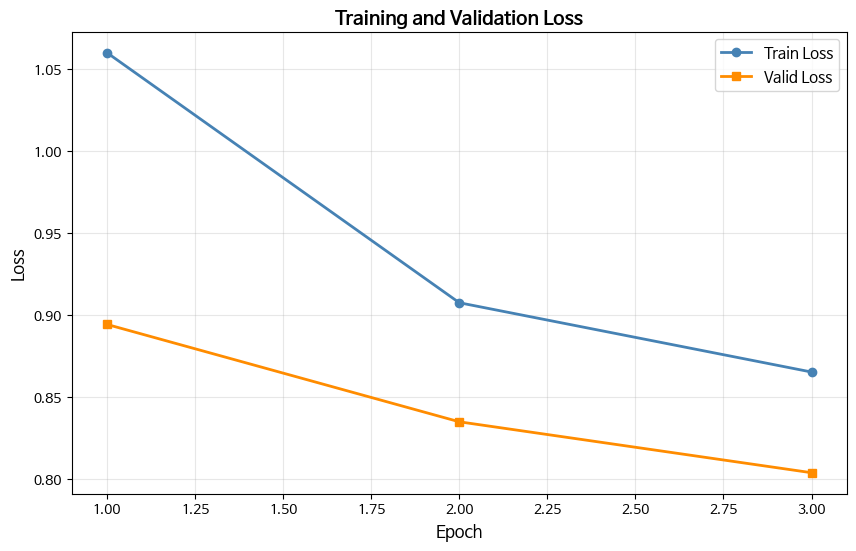

2025-10-17 13:26:51 [D] Accuracy curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327/training_curves_accuracy.png


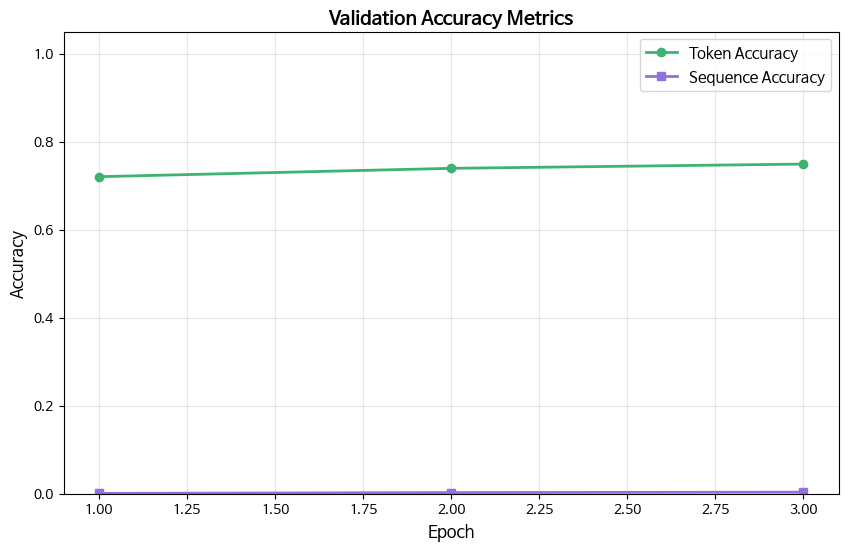

2025-10-17 13:26:52 [D] Quality curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327/training_curves_quality.png


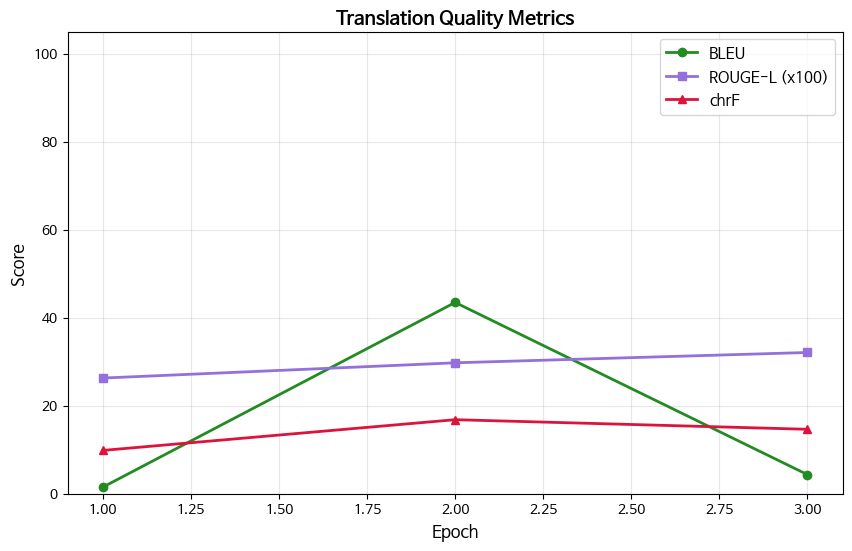

2025-10-17 13:26:53 [D] Training curves visualization completed (3 figures)
2025-10-17 13:26:53 [D] Training curves saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327/training_curves.png
2025-10-17 13:26:53 [D] Training curves uploaded to WandB: 3 images
2025-10-17 13:26:53 [D] ................................................................................
2025-10-17 13:26:53 [D] 학습 완료
2025-10-17 13:26:53 [D] ================================================================================
2025-10-17 13:26:53 [D] Model directory: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327
2025-10-17 13:26:53 [I] Best model: /content/drive/MyDrive/modeling/BasicSeq2Seq_syllable_256/BasicSeq2Seq_syllable_256_20251015_165327/BasicSeq2Seq_best.pth
2025-10-17 13:26:53 [D] Best valid loss: 0.8041
2025-10-17 13:26:53 [D] ==============================================================================

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

2025-10-17 13:26:57 [D] 
Generating 5 sample translations...
2025-10-17 13:26:58 [D] ................................................................................
2025-10-17 13:26:58 [I] 평가 종료
2025-10-17 13:26:58 [D] ................................................................................
2025-10-17 13:26:58 [D] Metrics:
2025-10-17 13:26:58 [D]    Test Loss: 0.8040
2025-10-17 13:26:58 [D]    Perplexity: 2.23
2025-10-17 13:26:58 [D] Sample Translations:
2025-10-17 13:26:58 [D] ................................................................................
2025-10-17 13:26:58 [I] [Sample 1]
2025-10-17 13:26:58 [I]   Source:     기억 나네요, 그렇죠.
2025-10-17 13:26:58 [I]   Target:     >i remember, right.
2025-10-17 13:26:58 [I]   Prediction: >i really.
2025-10-17 13:26:58 [I]   Status:     불일치
2025-10-17 13:26:58 [I] [Sample 2]
2025-10-17 13:26:58 [I]   Source:     하지만 받아본 제품은 나무처럼 보이는 플라스틱 재질로 되어있습니다.
2025-10-17 13:26:58 [I]   Target:     however, the product i received is made of 

Tokenizing:   0%|          | 0/1031323 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/136175 [00:00<?, ?it/s]

...

Encoding:   0%|          | 0/136175 [00:00<?, ?it/s]

Encoding:   0%|          | 0/1000 [00:00<?, ?it/s]

2025-10-17 13:29:18 [I] Step 6: 인코딩 후 사이즈 1030323, 136175, 1000
2025-10-17 13:30:06 [D] Loader dataset size: 1030323
2025-10-17 13:30:06 [D] Loader batches: 8050
2025-10-17 13:30:13 [D] Loader dataset size: 136175
2025-10-17 13:30:13 [D] Loader batches: 1064
2025-10-17 13:30:13 [D] Loader dataset size: 1000
2025-10-17 13:30:13 [D] Loader batches: 8
2025-10-17 13:30:13 [I] Step 7: DataLoader 생성 완료
2025-10-17 13:30:13 [I] Step 8: Vocabularies saved to /content/temp/vocab
2025-10-17 13:30:13 [D] Source shape: torch.Size([128, 200])
2025-10-17 13:30:13 [D] Target input shape: torch.Size([128, 200])
2025-10-17 13:30:13 [D] Target output shape: torch.Size([128, 200])
2025-10-17 13:30:13 [I] Step 9: Tokenization pipeline ready!
2025-10-17 13:30:18 [D] ****************************************
2025-10-17 13:30:18 [I] FULL PIPELINE START
2025-10-17 13:30:18 [D] ****************************************
2025-10-17 13:30:19 [I] 이어학습 파일 발견, 이어서 학습: /content/drive/MyDrive/modeling/BasicSeq2Seq_morphe

Epochs: 0it [00:00, ?it/s]

2025-10-17 13:30:51 [D] ................................................................................
2025-10-17 13:30:51 [D] Training completed!
2025-10-17 13:30:51 [D] Model directory: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907
2025-10-17 13:30:51 [D] Best valid loss: 0.7646
2025-10-17 13:30:51 [D] ================================================================================
2025-10-17 13:30:52 [D] Loss curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907/training_curves_loss.png


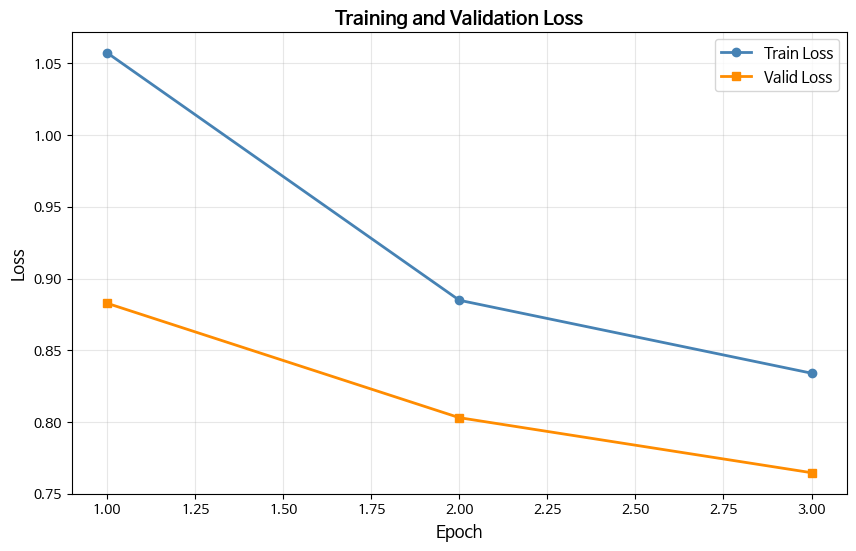

2025-10-17 13:30:53 [D] Accuracy curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907/training_curves_accuracy.png


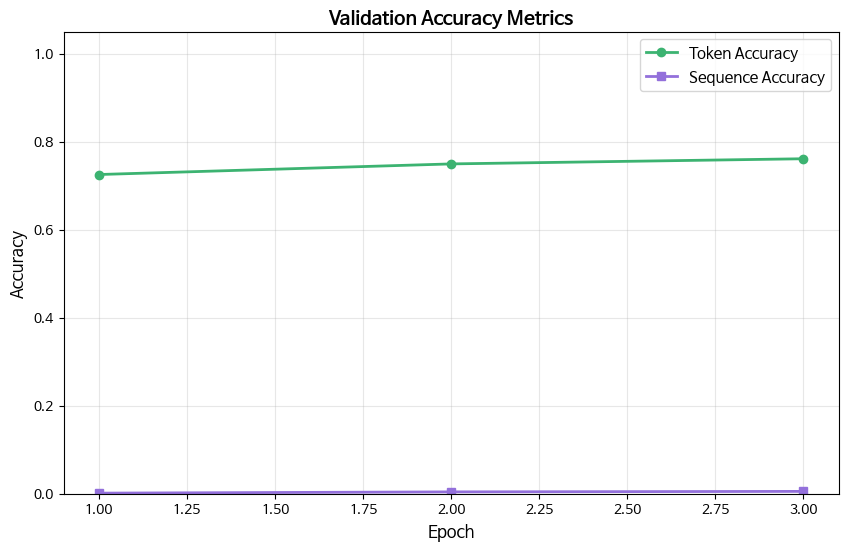

2025-10-17 13:30:55 [D] Quality curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907/training_curves_quality.png


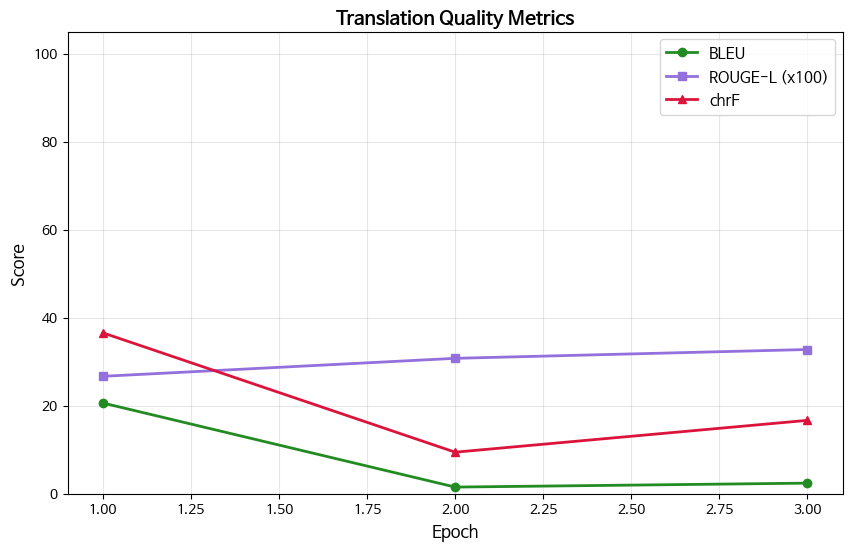

2025-10-17 13:30:55 [D] Training curves visualization completed (3 figures)
2025-10-17 13:30:55 [D] Training curves saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907/training_curves.png
2025-10-17 13:30:55 [D] Training curves uploaded to WandB: 3 images
2025-10-17 13:30:55 [D] ................................................................................
2025-10-17 13:30:55 [D] 학습 완료
2025-10-17 13:30:55 [D] ================================================================================
2025-10-17 13:30:55 [D] Model directory: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907
2025-10-17 13:30:55 [I] Best model: /content/drive/MyDrive/modeling/BasicSeq2Seq_morpheme_256/BasicSeq2Seq_morpheme_256_20251015_172907/BasicSeq2Seq_best.pth
2025-10-17 13:30:55 [D] Best valid loss: 0.7646
2025-10-17 13:30:55 [D] ==============================================================================

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

2025-10-17 13:30:59 [D] 
Generating 5 sample translations...
2025-10-17 13:30:59 [D] ................................................................................
2025-10-17 13:30:59 [I] 평가 종료
2025-10-17 13:30:59 [D] ................................................................................
2025-10-17 13:30:59 [D] Metrics:
2025-10-17 13:30:59 [D]    Test Loss: 0.7642
2025-10-17 13:30:59 [D]    Perplexity: 2.15
2025-10-17 13:30:59 [D] Sample Translations:
2025-10-17 13:30:59 [D] ................................................................................
2025-10-17 13:30:59 [I] [Sample 1]
2025-10-17 13:30:59 [I]   Source:     기억나네요,그렇죠.
2025-10-17 13:30:59 [I]   Target:     >i remember, right.
2025-10-17 13:30:59 [I]   Prediction: > is really more.
2025-10-17 13:30:59 [I]   Status:     불일치
2025-10-17 13:30:59 [I] [Sample 2]
2025-10-17 13:30:59 [I]   Source:     하지만받아본제품은나무처럼보이는플라스틱재질로되어있습니다.
2025-10-17 13:30:59 [I]   Target:     however, the product i received is made of a 

Tokenizing:   0%|          | 0/1031323 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/136175 [00:00<?, ?it/s]

...

Encoding:   0%|          | 0/136175 [00:00<?, ?it/s]

Encoding:   0%|          | 0/1000 [00:00<?, ?it/s]

2025-10-17 13:32:37 [I] Step 6: 인코딩 후 사이즈 1030323, 136175, 1000
2025-10-17 13:33:25 [D] Loader dataset size: 1030323
2025-10-17 13:33:25 [D] Loader batches: 8050
2025-10-17 13:33:32 [D] Loader dataset size: 136175
2025-10-17 13:33:32 [D] Loader batches: 1064
2025-10-17 13:33:32 [D] Loader dataset size: 1000
2025-10-17 13:33:32 [D] Loader batches: 8
2025-10-17 13:33:32 [I] Step 7: DataLoader 생성 완료
2025-10-17 13:33:32 [I] Step 8: Vocabularies saved to /content/temp/vocab
2025-10-17 13:33:32 [D] Source shape: torch.Size([128, 200])
2025-10-17 13:33:32 [D] Target input shape: torch.Size([128, 200])
2025-10-17 13:33:32 [D] Target output shape: torch.Size([128, 200])
2025-10-17 13:33:32 [I] Step 9: Tokenization pipeline ready!
2025-10-17 13:33:37 [D] ****************************************
2025-10-17 13:33:37 [I] FULL PIPELINE START
2025-10-17 13:33:37 [D] ****************************************
2025-10-17 13:33:37 [I] 이어학습 파일 발견, 이어서 학습: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_2

Epochs: 0it [00:00, ?it/s]

2025-10-17 13:33:51 [D] ................................................................................
2025-10-17 13:33:51 [D] Training completed!
2025-10-17 13:33:51 [D] Model directory: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653
2025-10-17 13:33:51 [D] Best valid loss: 0.8139
2025-10-17 13:33:51 [D] ================================================================================
2025-10-17 13:33:52 [D] Loss curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653/training_curves_loss.png


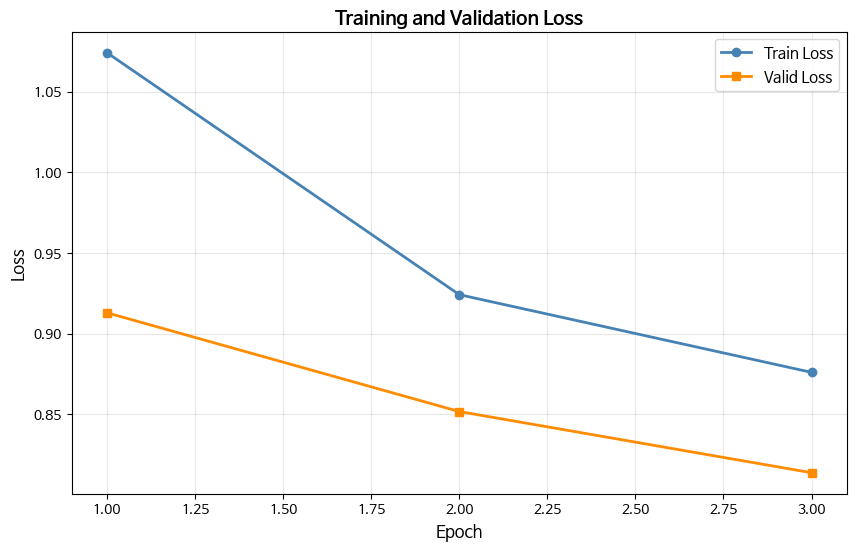

2025-10-17 13:33:54 [D] Accuracy curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653/training_curves_accuracy.png


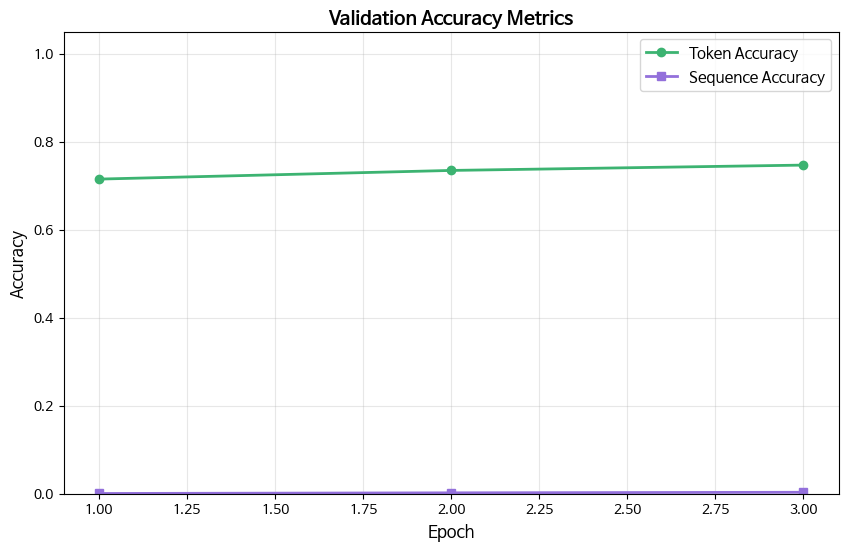

2025-10-17 13:33:55 [D] Quality curve saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653/training_curves_quality.png


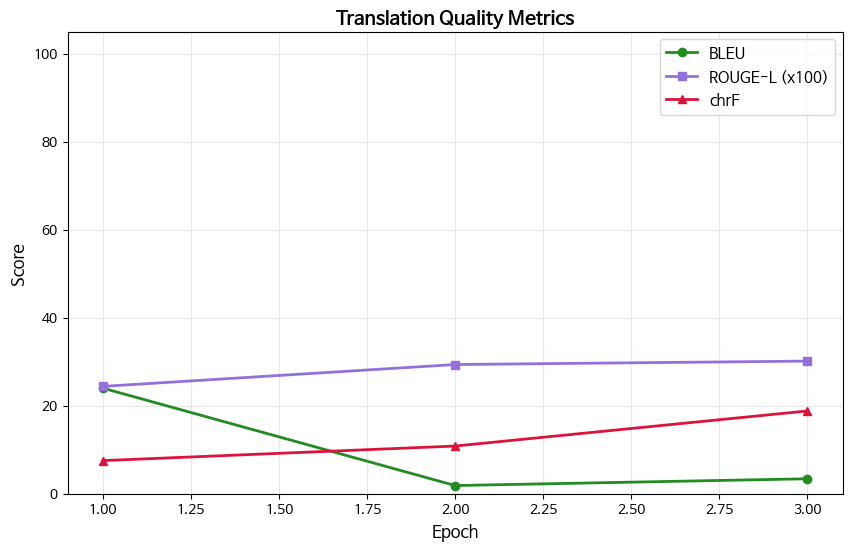

2025-10-17 13:33:55 [D] Training curves visualization completed (3 figures)
2025-10-17 13:33:55 [D] Training curves saved: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653/training_curves.png
2025-10-17 13:33:55 [D] Training curves uploaded to WandB: 3 images
2025-10-17 13:33:55 [D] ................................................................................
2025-10-17 13:33:55 [D] 학습 완료
2025-10-17 13:33:55 [D] ================================================================================
2025-10-17 13:33:55 [D] Model directory: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653
2025-10-17 13:33:55 [I] Best model: /content/drive/MyDrive/modeling/BasicSeq2Seq_jamo_256/BasicSeq2Seq_jamo_256_20251015_180653/BasicSeq2Seq_best.pth
2025-10-17 13:33:55 [D] Best valid loss: 0.8139
2025-10-17 13:33:55 [D] ================================================================================
2025-10-17 13:33:57 [

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

2025-10-17 13:33:58 [D] 
Generating 5 sample translations...
2025-10-17 13:33:59 [D] ................................................................................
2025-10-17 13:33:59 [I] 평가 종료
2025-10-17 13:33:59 [D] ................................................................................
2025-10-17 13:33:59 [D] Metrics:
2025-10-17 13:33:59 [D]    Test Loss: 0.8127
2025-10-17 13:33:59 [D]    Perplexity: 2.25
2025-10-17 13:33:59 [D] Sample Translations:
2025-10-17 13:33:59 [D] ................................................................................
2025-10-17 13:33:59 [I] [Sample 1]
2025-10-17 13:33:59 [I]   Source:     ㄱㅣㅇㅓㄱ ㄴㅏㄴㅔㅇㅛ, ㄱㅡㄹㅓㅎㅈㅛ.
2025-10-17 13:33:59 [I]   Target:     i remember, right.
2025-10-17 13:33:59 [I]   Prediction: the same.
2025-10-17 13:33:59 [I]   Status:     불일치
2025-10-17 13:33:59 [I] [Sample 2]
2025-10-17 13:33:59 [I]   Source:     ㅎㅏㅈㅣㅁㅏㄴ ㅂㅏㄷㅇㅏㅂㅗㄴ ㅈㅔㅍㅜㅁㅇㅡㄴ ㄴㅏㅁㅜㅊㅓㄹㅓㅁ ㅂㅗㅇㅣㄴㅡㄴ ㅍㅡㄹㄹㅏㅅㅡㅌㅣㄱ ㅈㅐㅈㅣㄹㄹㅗ ㄷㅚㅇㅓㅇㅣㅆㅅㅡㅂㄴㅣㄷㅏ.
2025-10-17 13:33:59 [I]   Target

Tokenizing:   0%|          | 0/1031323 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/136175 [00:00<?, ?it/s]

...

Encoding:   0%|          | 0/136175 [00:00<?, ?it/s]

Encoding:   0%|          | 0/1000 [00:00<?, ?it/s]

2025-10-17 13:35:23 [I] Step 6: 인코딩 후 사이즈 1030323, 136175, 1000
2025-10-17 13:36:11 [D] Loader dataset size: 1030323
2025-10-17 13:36:11 [D] Loader batches: 8050
2025-10-17 13:36:17 [D] Loader dataset size: 136175
2025-10-17 13:36:17 [D] Loader batches: 1064
2025-10-17 13:36:17 [D] Loader dataset size: 1000
2025-10-17 13:36:17 [D] Loader batches: 8
2025-10-17 13:36:17 [I] Step 7: DataLoader 생성 완료
2025-10-17 13:36:17 [I] Step 8: Vocabularies saved to /content/temp/vocab
2025-10-17 13:36:18 [D] Source shape: torch.Size([128, 200])
2025-10-17 13:36:18 [D] Target input shape: torch.Size([128, 200])
2025-10-17 13:36:18 [D] Target output shape: torch.Size([128, 200])
2025-10-17 13:36:18 [I] Step 9: Tokenization pipeline ready!
2025-10-17 13:36:23 [D] ****************************************
2025-10-17 13:36:23 [I] FULL PIPELINE START
2025-10-17 13:36:23 [D] ****************************************
2025-10-17 13:36:24 [I] 이어학습 파일 발견, 이어서 학습: /content/drive/MyDrive/modeling/AttentionSeq2Seq_sy

Epochs: 0it [00:00, ?it/s]

2025-10-17 13:36:46 [D] ................................................................................
2025-10-17 13:36:46 [D] Training completed!
2025-10-17 13:36:46 [D] Model directory: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657
2025-10-17 13:36:46 [D] Best valid loss: 0.4777
2025-10-17 13:36:46 [D] ================================================================================
2025-10-17 13:36:47 [D] Loss curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/training_curves_loss.png


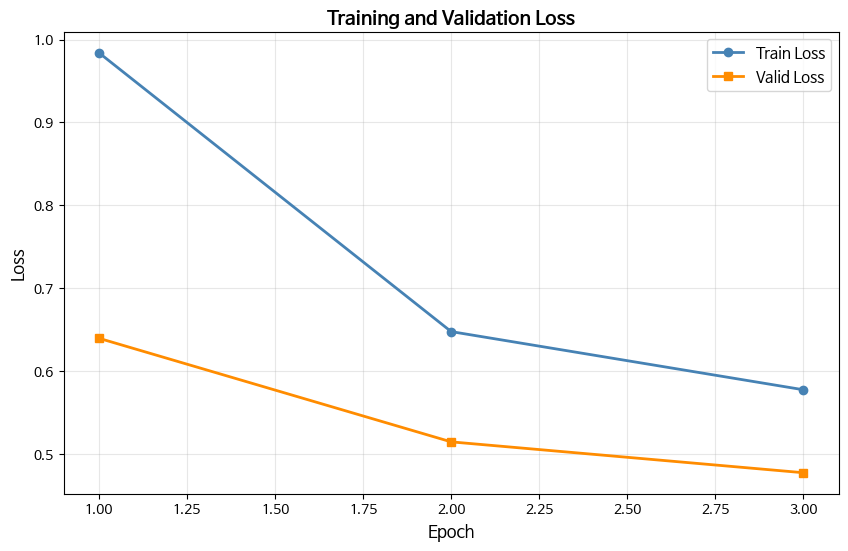

2025-10-17 13:36:48 [D] Accuracy curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/training_curves_accuracy.png


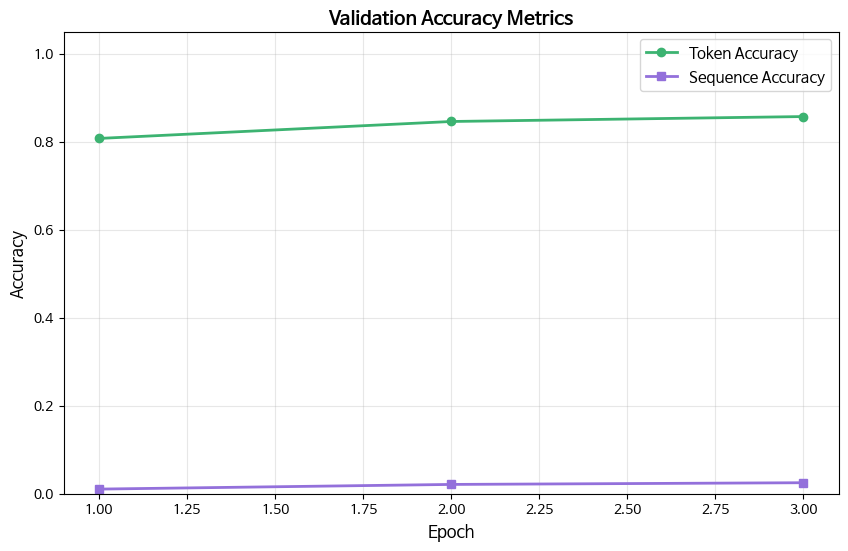

2025-10-17 13:36:50 [D] Quality curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/training_curves_quality.png


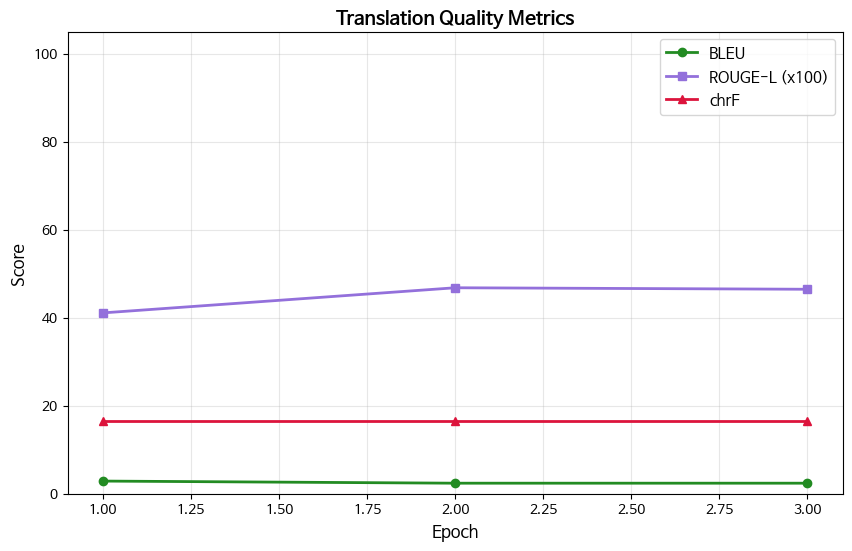

2025-10-17 13:36:50 [D] Training curves visualization completed (3 figures)
2025-10-17 13:36:50 [D] Training curves saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/training_curves.png
2025-10-17 13:36:50 [D] Training curves uploaded to WandB: 3 images
2025-10-17 13:36:50 [D] ................................................................................
2025-10-17 13:36:50 [D] 학습 완료
2025-10-17 13:36:50 [D] ================================================================================
2025-10-17 13:36:50 [D] Model directory: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657
2025-10-17 13:36:50 [I] Best model: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/AttentionSeq2Seq_best.pth
2025-10-17 13:36:50 [D] Best valid loss: 0.4777
2025-10-17 13:36:50 [D] ==================================================

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

2025-10-17 13:36:59 [D] 
Generating 5 sample translations...
2025-10-17 13:37:01 [D] ................................................................................
2025-10-17 13:37:01 [I] 평가 종료
2025-10-17 13:37:01 [D] ................................................................................
2025-10-17 13:37:01 [D] Metrics:
2025-10-17 13:37:01 [D]    Test Loss: 0.4819
2025-10-17 13:37:01 [D]    Perplexity: 1.62
2025-10-17 13:37:01 [D] Sample Translations:
2025-10-17 13:37:01 [D] ................................................................................
2025-10-17 13:37:01 [I] [Sample 1]
2025-10-17 13:37:01 [I]   Source:     기억 나네요, 그렇죠.
2025-10-17 13:37:01 [I]   Target:     >i remember, right.
2025-10-17 13:37:01 [I]   Prediction: i remember.
2025-10-17 13:37:01 [I]   Status:     불일치
2025-10-17 13:37:01 [I] [Sample 2]
2025-10-17 13:37:01 [I]   Source:     하지만 받아본 제품은 나무처럼 보이는 플라스틱 재질로 되어있습니다.
2025-10-17 13:37:01 [I]   Target:     however, the product i received is made of

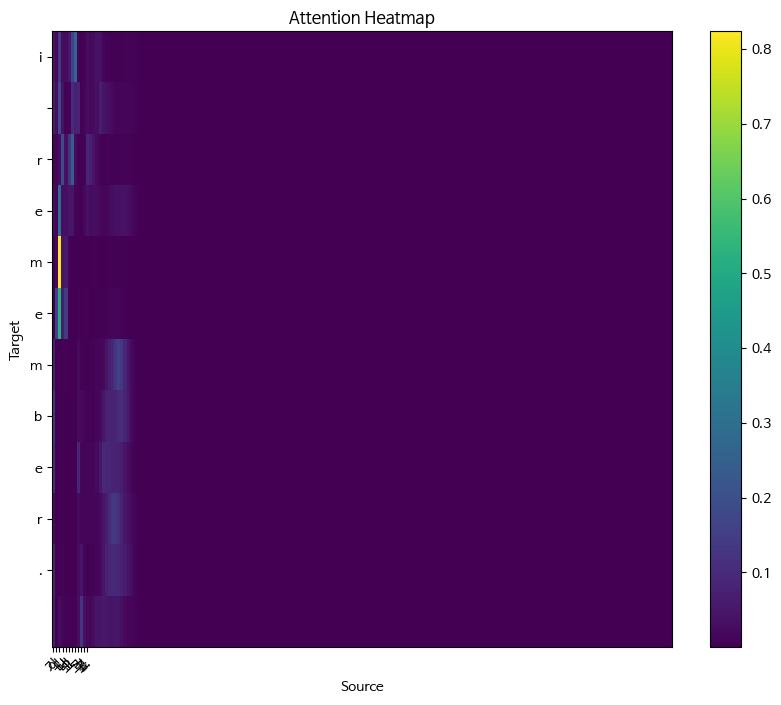

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/attention_sample_1.png


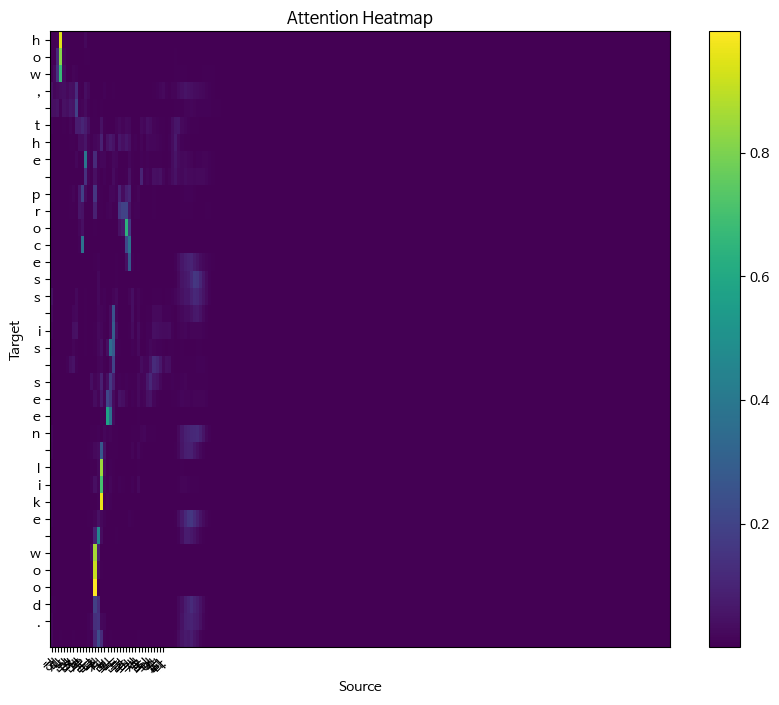

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/attention_sample_2.png


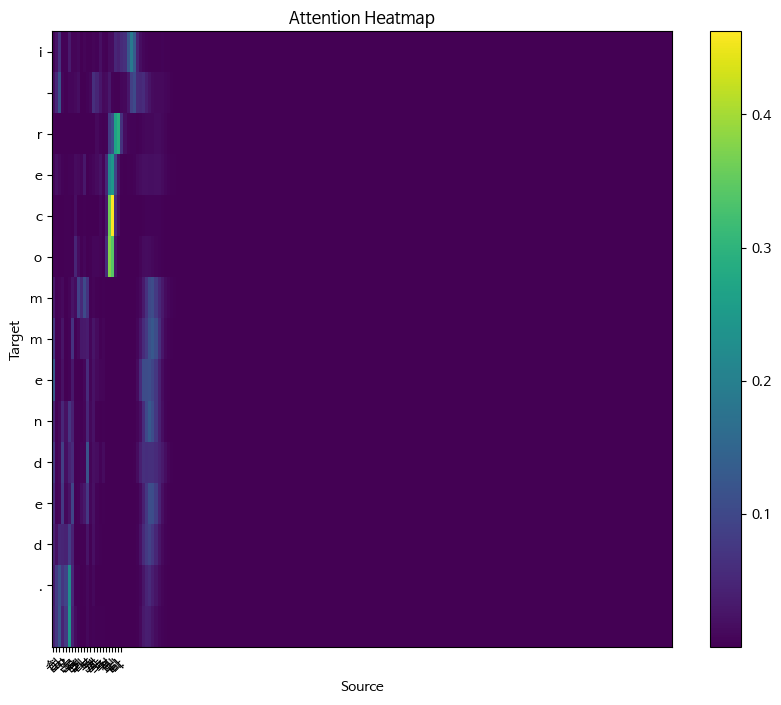

2025-10-17 13:37:07 [D] ................................................................................
2025-10-17 13:37:07 [D] 평가 종료
2025-10-17 13:37:07 [D] ================================================================================
2025-10-17 13:37:07 [I] ================================================================================
2025-10-17 13:37:07 [I] 평가 결과
2025-10-17 13:37:07 [I] ................................................................................
2025-10-17 13:37:07 [I] Metrics:
2025-10-17 13:37:07 [I]    Test Loss:      0.4819
2025-10-17 13:37:07 [I]    Perplexity:     1.62
2025-10-17 13:37:07 [I]    Token Accuracy: 0.8556
2025-10-17 13:37:07 [I]    Seq Accuracy:   0.0200
2025-10-17 13:37:07 [I]    BLEU:           1.04
2025-10-17 13:37:07 [I]    ROUGE-L:        0.4569
2025-10-17 13:37:07 [I]    chrF:           18.63
2025-10-17 13:37:07 [I] Sample Translations:
2025-10-17 13:37:07 [I] .........................................................................

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_syllable_256/AttentionSeq2Seq_syllable_256_20251015_184657/attention_sample_3.png


2025-10-17 13:37:07 [D] 
Translating...
2025-10-17 13:37:07 [D] 
2025-10-17 13:37:07 [D] TRANSLATION RESULT
2025-10-17 13:37:07 [D] ================================================================================
2025-10-17 13:37:07 [D] Input:  안녕하세요
2025-10-17 13:37:07 [D] Output: >milk contaminatory"
2025-10-17 13:37:07 [D] ================================================================================
2025-10-17 13:37:07 [D]            → >milk contaminatory"

2025-10-17 13:37:07 [D] [2/3] Translating: 감사합니다
2025-10-17 13:37:07 [D] 
2025-10-17 13:37:07 [D] TRANSLATION
2025-10-17 13:37:07 [D] ================================================================================
2025-10-17 13:37:07 [D] Input: 감사합니다
2025-10-17 13:37:07 [D] Tokenizer: jamo
2025-10-17 13:37:07 [D] ================================================================================

2025-10-17 13:37:07 [D] Tokenizing...
2025-10-17 13:37:07 [D]    Tokens: ['ㄱ', 'ㅏ', 'ㅁ', 'ㅅ', 'ㅏ', 'ㅎ', 'ㅏ', 'ㅂ', 'ㄴ', 'ㅣ', 'ㄷ', 'ㅏ']


Tokenizing:   0%|          | 0/1031323 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/136175 [00:00<?, ?it/s]

...

2025-10-17 13:39:12 [I] Step 6: 인코딩 후 사이즈 1030323, 136175, 1000
2025-10-17 13:40:00 [D] Loader dataset size: 1030323
2025-10-17 13:40:00 [D] Loader batches: 8050
2025-10-17 13:40:06 [D] Loader dataset size: 136175
2025-10-17 13:40:06 [D] Loader batches: 1064
2025-10-17 13:40:06 [D] Loader dataset size: 1000
2025-10-17 13:40:06 [D] Loader batches: 8
2025-10-17 13:40:06 [I] Step 7: DataLoader 생성 완료
2025-10-17 13:40:06 [I] Step 8: Vocabularies saved to /content/temp/vocab
2025-10-17 13:40:06 [D] Source shape: torch.Size([128, 200])
2025-10-17 13:40:06 [D] Target input shape: torch.Size([128, 200])
2025-10-17 13:40:06 [D] Target output shape: torch.Size([128, 200])
2025-10-17 13:40:07 [I] Step 9: Tokenization pipeline ready!
2025-10-17 13:40:09 [D] ****************************************
2025-10-17 13:40:09 [I] FULL PIPELINE START
2025-10-17 13:40:09 [D] ****************************************
2025-10-17 13:40:10 [I] 이어학습 파일 발견, 이어서 학습: /content/drive/MyDrive/modeling/AttentionSeq2Seq_mo

Epochs:   0%|          | 0/1 [00:00<?, ?it/s]

Training:   0%|          | 0/8050 [00:00<?, ?it/s]

Validating:   0%|          | 0/1064 [00:00<?, ?it/s]

2025-10-17 18:43:06 [D] ................................................................................
2025-10-17 18:43:06 [D] Training completed!
2025-10-17 18:43:06 [D] Model directory: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539
2025-10-17 18:43:06 [D] Best valid loss: 0.4675
2025-10-17 18:43:06 [D] ================================================================================
2025-10-17 18:43:06 [D] Loss curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/training_curves_loss.png


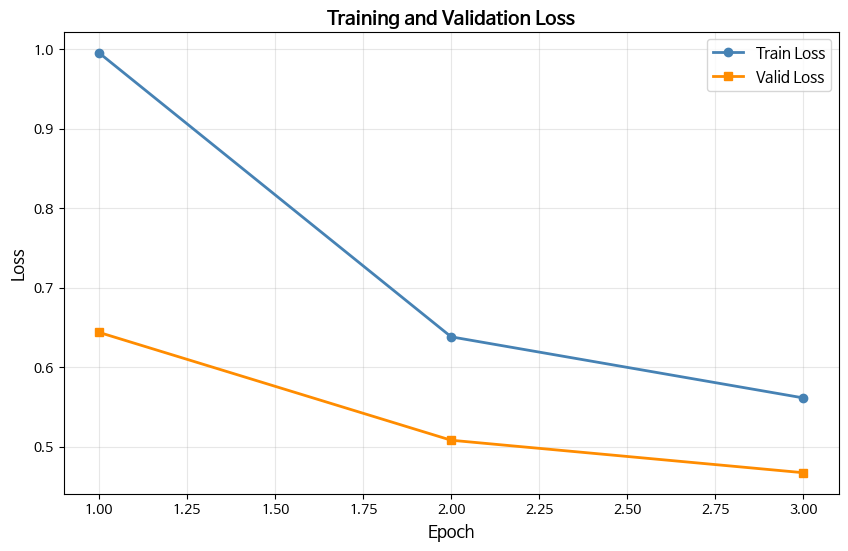

2025-10-17 18:43:07 [D] Accuracy curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/training_curves_accuracy.png


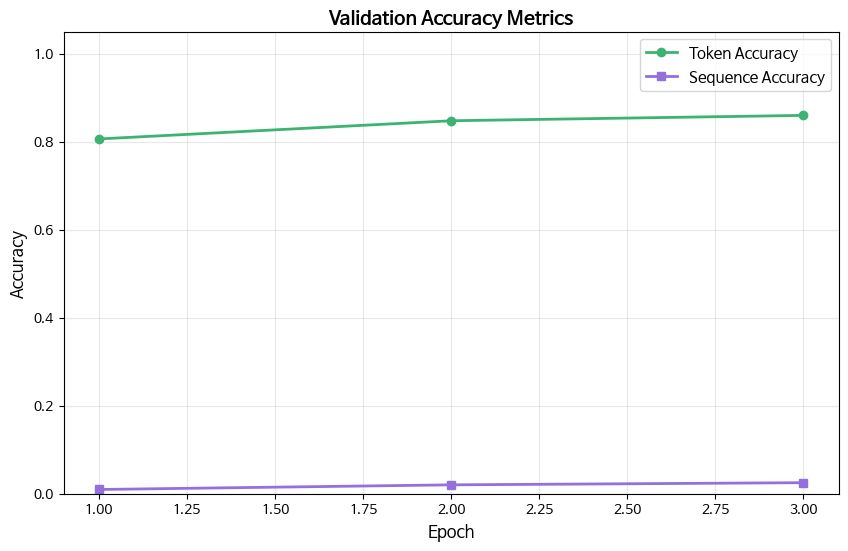

2025-10-17 18:43:07 [D] Quality curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/training_curves_quality.png


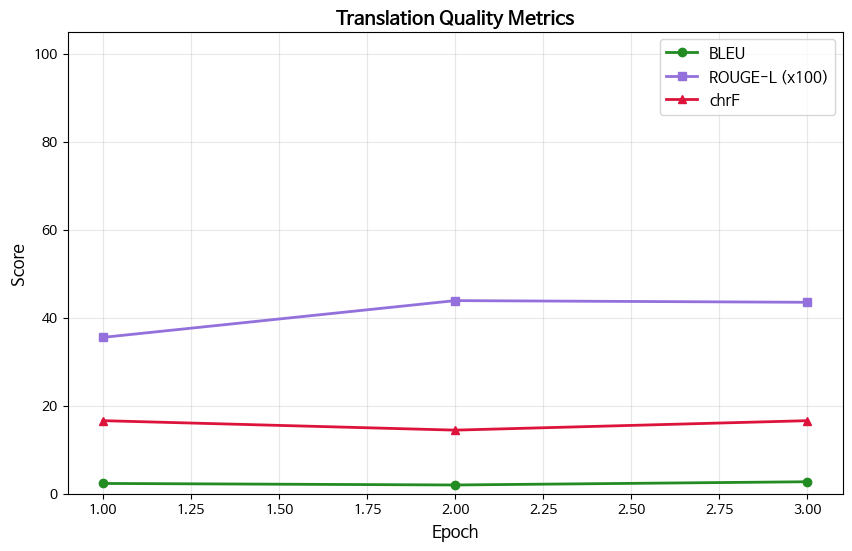

2025-10-17 18:43:07 [D] Training curves visualization completed (3 figures)
2025-10-17 18:43:07 [D] Training curves saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/training_curves.png
2025-10-17 18:43:08 [D] Training curves uploaded to WandB: 3 images
2025-10-17 18:43:08 [D] ................................................................................
2025-10-17 18:43:08 [D] 학습 완료
2025-10-17 18:43:08 [D] ================================================================================
2025-10-17 18:43:08 [D] Model directory: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539
2025-10-17 18:43:08 [I] Best model: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/AttentionSeq2Seq_best.pth
2025-10-17 18:43:08 [D] Best valid loss: 0.4675
2025-10-17 18:43:08 [D] ==================================================

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

2025-10-17 18:43:18 [D] 
Generating 5 sample translations...
2025-10-17 18:43:19 [D] ................................................................................
2025-10-17 18:43:19 [I] 평가 종료
2025-10-17 18:43:19 [D] ................................................................................
2025-10-17 18:43:19 [D] Metrics:
2025-10-17 18:43:19 [D]    Test Loss: 0.4723
2025-10-17 18:43:19 [D]    Perplexity: 1.60
2025-10-17 18:43:19 [D] Sample Translations:
2025-10-17 18:43:19 [D] ................................................................................
2025-10-17 18:43:19 [I] [Sample 1]
2025-10-17 18:43:19 [I]   Source:     기억나네요,그렇죠.
2025-10-17 18:43:19 [I]   Target:     >i remember, right.
2025-10-17 18:43:19 [I]   Prediction: >i remember.
2025-10-17 18:43:19 [I]   Status:     불일치
2025-10-17 18:43:19 [I] [Sample 2]
2025-10-17 18:43:19 [I]   Source:     하지만받아본제품은나무처럼보이는플라스틱재질로되어있습니다.
2025-10-17 18:43:19 [I]   Target:     however, the product i received is made of a plast

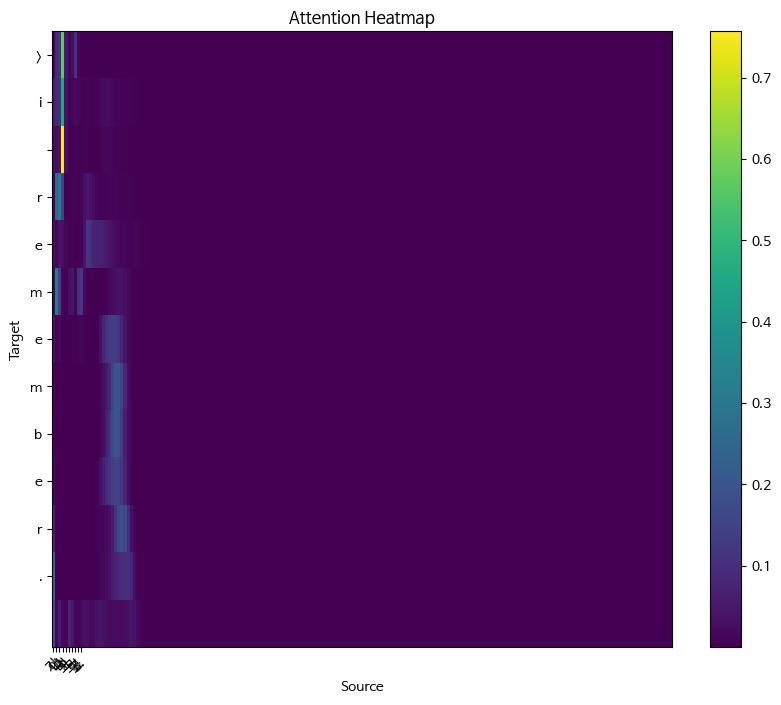

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/attention_sample_1.png


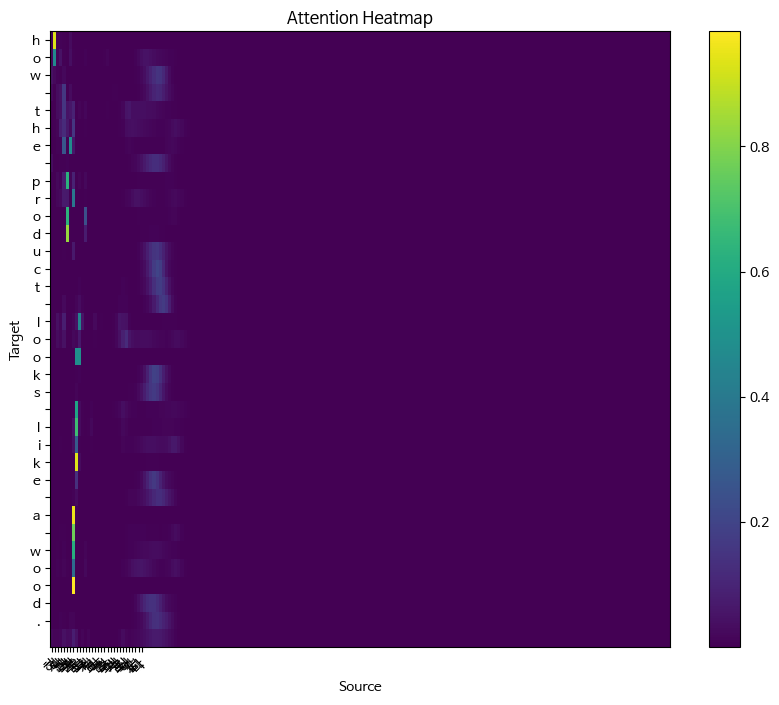

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/attention_sample_2.png


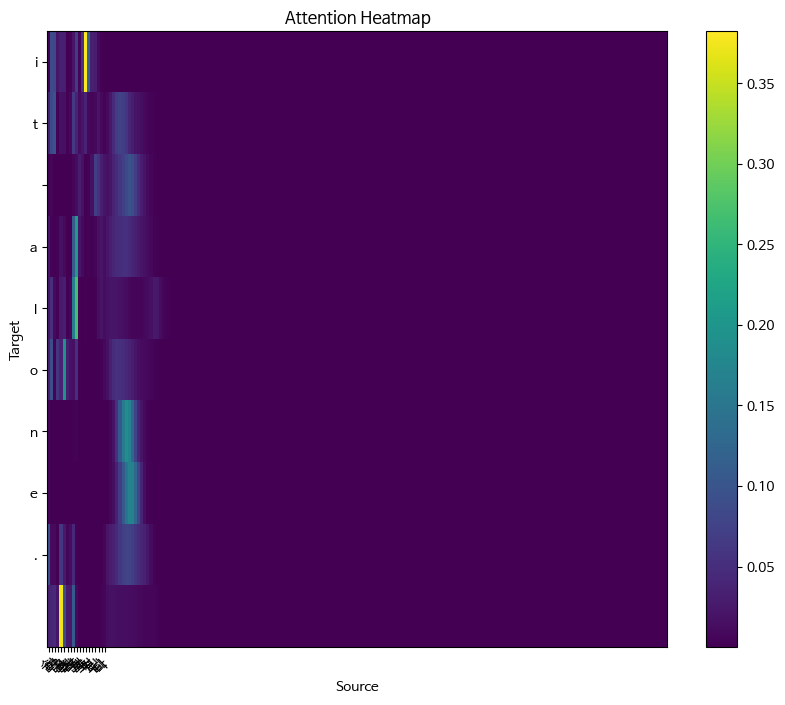

2025-10-17 18:43:24 [D] ................................................................................
2025-10-17 18:43:24 [D] 평가 종료
2025-10-17 18:43:24 [D] ================================================================================
2025-10-17 18:43:24 [I] ================================================================================
2025-10-17 18:43:24 [I] 평가 결과
2025-10-17 18:43:24 [I] ................................................................................
2025-10-17 18:43:24 [I] Metrics:
2025-10-17 18:43:24 [I]    Test Loss:      0.4723
2025-10-17 18:43:24 [I]    Perplexity:     1.60
2025-10-17 18:43:24 [I]    Token Accuracy: 0.8593
2025-10-17 18:43:24 [I]    Seq Accuracy:   0.0200
2025-10-17 18:43:24 [I]    BLEU:           1.17
2025-10-17 18:43:24 [I]    ROUGE-L:        0.4273
2025-10-17 18:43:24 [I]    chrF:           16.74
2025-10-17 18:43:24 [I] Sample Translations:
2025-10-17 18:43:24 [I] .........................................................................

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_morpheme_256/AttentionSeq2Seq_morpheme_256_20251016_222539/attention_sample_3.png


2025-10-17 18:43:24 [D] 
Translating...
2025-10-17 18:43:25 [D] 
2025-10-17 18:43:25 [D] TRANSLATION RESULT
2025-10-17 18:43:25 [D] ================================================================================
2025-10-17 18:43:25 [D] Input:  안녕하세요
2025-10-17 18:43:25 [D] Output: unlike kim jakim jeju tracket.
2025-10-17 18:43:25 [D] ================================================================================
2025-10-17 18:43:25 [D]            → unlike kim jakim jeju tracket.

2025-10-17 18:43:25 [D] [2/3] Translating: 감사합니다
2025-10-17 18:43:25 [D] 
2025-10-17 18:43:25 [D] TRANSLATION
2025-10-17 18:43:25 [D] ================================================================================
2025-10-17 18:43:25 [D] Input: 감사합니다
2025-10-17 18:43:25 [D] Tokenizer: jamo
2025-10-17 18:43:25 [D] ================================================================================

2025-10-17 18:43:25 [D] Tokenizing...
2025-10-17 18:43:25 [D]    Tokens: ['ㄱ', 'ㅏ', 'ㅁ', 'ㅅ', 'ㅏ', 'ㅎ', 'ㅏ', 'ㅂ', 

Tokenizing:   0%|          | 0/1031323 [00:00<?, ?it/s]

Tokenizing:   0%|          | 0/136175 [00:00<?, ?it/s]

...

Training:   0%|          | 0/8050 [00:00<?, ?it/s]

Validating:   0%|          | 0/1064 [00:00<?, ?it/s]

Training:   0%|          | 0/8050 [00:00<?, ?it/s]

Validating:   0%|          | 0/1064 [00:00<?, ?it/s]

2025-10-18 09:55:13 [D] ................................................................................
2025-10-18 09:55:13 [D] Training completed!
2025-10-18 09:55:13 [D] Model directory: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601
2025-10-18 09:55:13 [D] Best valid loss: 0.4645
2025-10-18 09:55:13 [D] ================================================================================
2025-10-18 09:55:13 [D] Loss curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/training_curves_loss.png


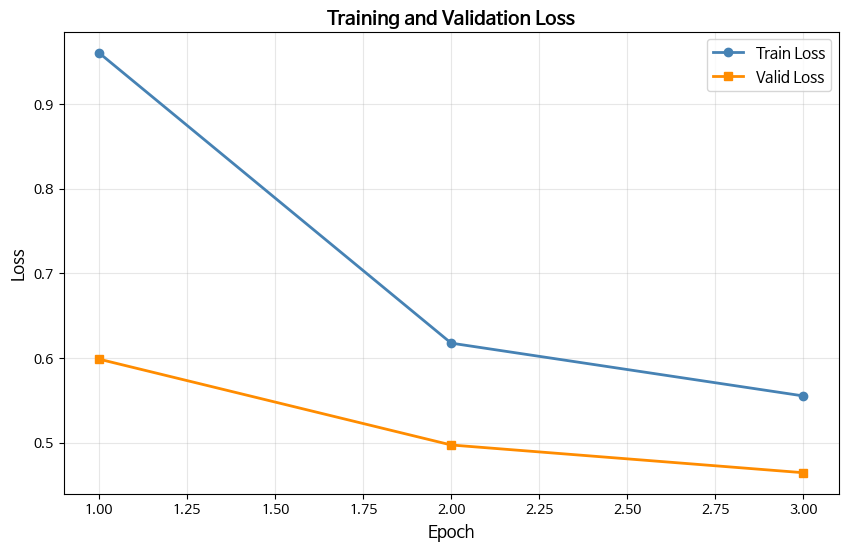

2025-10-18 09:55:14 [D] Accuracy curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/training_curves_accuracy.png


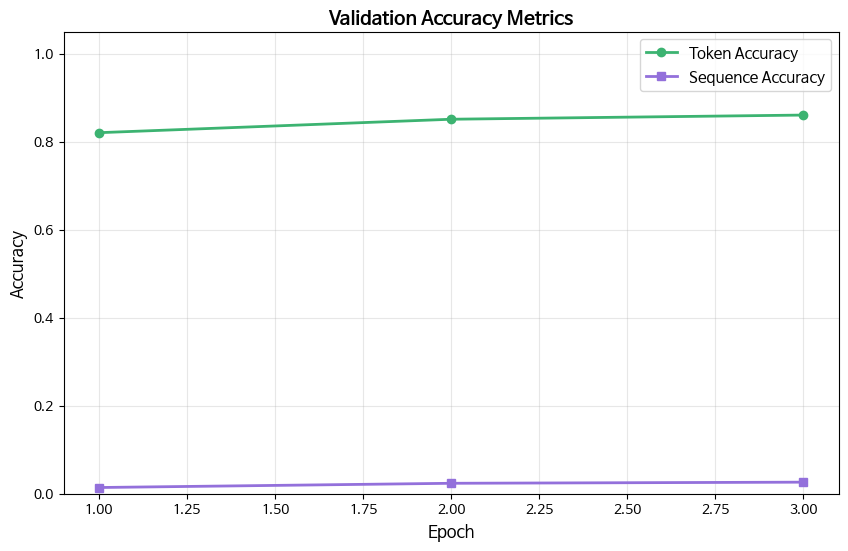

2025-10-18 09:55:14 [D] Quality curve saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/training_curves_quality.png


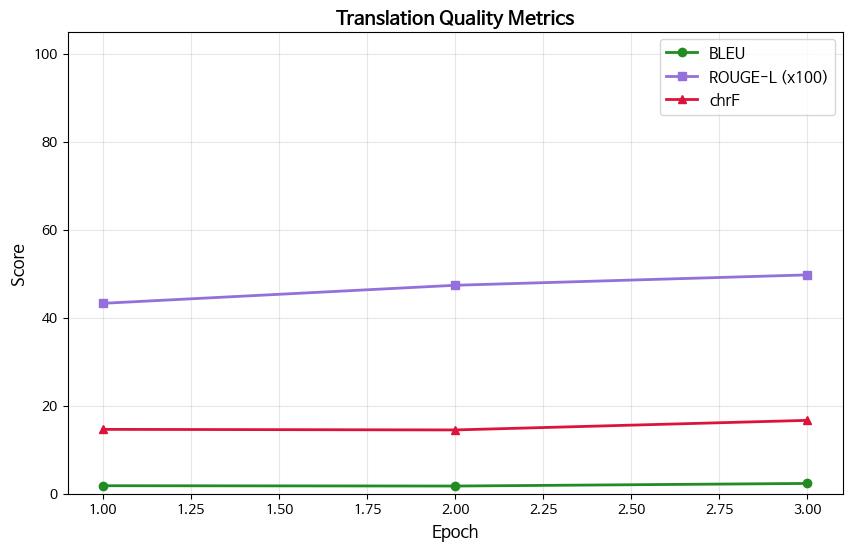

2025-10-18 09:55:14 [D] Training curves visualization completed (3 figures)
2025-10-18 09:55:14 [D] Training curves saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/training_curves.png
2025-10-18 09:55:15 [D] Training curves uploaded to WandB: 3 images
2025-10-18 09:55:15 [D] ................................................................................
2025-10-18 09:55:15 [D] 학습 완료
2025-10-18 09:55:15 [D] ================================================================================
2025-10-18 09:55:15 [D] Model directory: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601
2025-10-18 09:55:15 [I] Best model: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/AttentionSeq2Seq_best.pth
2025-10-18 09:55:15 [D] Best valid loss: 0.4645
2025-10-18 09:55:15 [D] ==========================================================================

Evaluating:   0%|          | 0/8 [00:00<?, ?it/s]

2025-10-18 09:55:25 [D] 
Generating 5 sample translations...
2025-10-18 09:55:26 [D] ................................................................................
2025-10-18 09:55:26 [I] 평가 종료
2025-10-18 09:55:26 [D] ................................................................................
2025-10-18 09:55:26 [D] Metrics:
2025-10-18 09:55:26 [D]    Test Loss: 0.4753
2025-10-18 09:55:26 [D]    Perplexity: 1.61
2025-10-18 09:55:26 [D] Sample Translations:
2025-10-18 09:55:26 [D] ................................................................................
2025-10-18 09:55:26 [I] [Sample 1]
2025-10-18 09:55:26 [I]   Source:     ㄱㅣㅇㅓㄱ ㄴㅏㄴㅔㅇㅛ, ㄱㅡㄹㅓㅎㅈㅛ.
2025-10-18 09:55:26 [I]   Target:     i remember, right.
2025-10-18 09:55:26 [I]   Prediction: i remember.
2025-10-18 09:55:26 [I]   Status:     불일치
2025-10-18 09:55:26 [I] [Sample 2]
2025-10-18 09:55:26 [I]   Source:     ㅎㅏㅈㅣㅁㅏㄴ ㅂㅏㄷㅇㅏㅂㅗㄴ ㅈㅔㅍㅜㅁㅇㅡㄴ ㄴㅏㅁㅜㅊㅓㄹㅓㅁ ㅂㅗㅇㅣㄴㅡㄴ ㅍㅡㄹㄹㅏㅅㅡㅌㅣㄱ ㅈㅐㅈㅣㄹㄹㅗ ㄷㅚㅇㅓㅇㅣㅆㅅㅡㅂㄴㅣㄷㅏ.
2025-10-18 09:55:26 [I]   Targ

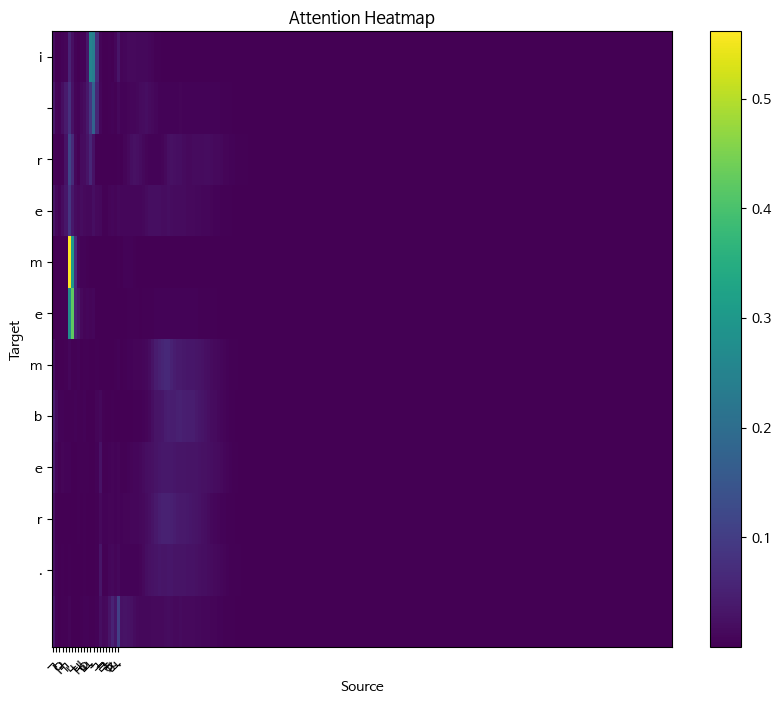

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/attention_sample_1.png


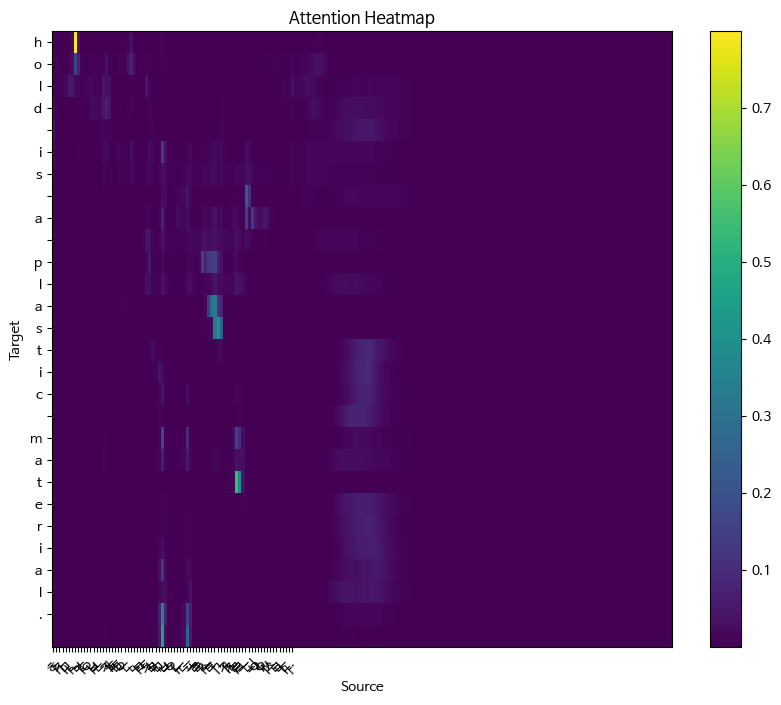

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/attention_sample_2.png


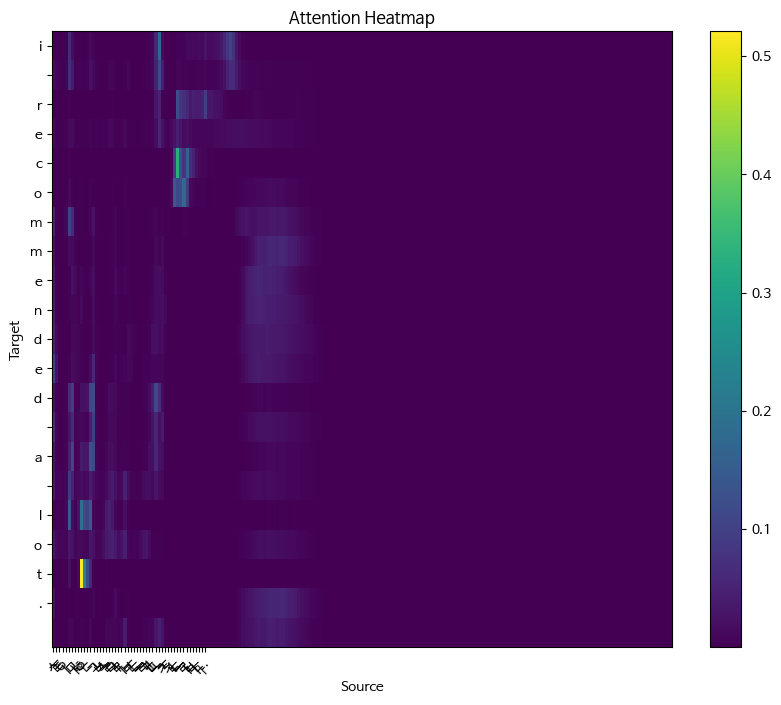

2025-10-18 09:55:29 [D] ................................................................................
2025-10-18 09:55:29 [D] 평가 종료
2025-10-18 09:55:29 [D] ================================================================================
2025-10-18 09:55:29 [I] ================================================================================
2025-10-18 09:55:29 [I] 평가 결과
2025-10-18 09:55:29 [I] ................................................................................
2025-10-18 09:55:29 [I] Metrics:
2025-10-18 09:55:29 [I]    Test Loss:      0.4753
2025-10-18 09:55:29 [I]    Perplexity:     1.61
2025-10-18 09:55:29 [I]    Token Accuracy: 0.8575
2025-10-18 09:55:29 [I]    Seq Accuracy:   0.0210
2025-10-18 09:55:29 [I]    BLEU:           1.46
2025-10-18 09:55:29 [I]    ROUGE-L:        0.4911
2025-10-18 09:55:29 [I]    chrF:           21.50
2025-10-18 09:55:29 [I] Sample Translations:
2025-10-18 09:55:29 [I] .........................................................................

   Saved: /content/drive/MyDrive/modeling/AttentionSeq2Seq_jamo_256/AttentionSeq2Seq_jamo_256_20251017_184601/attention_sample_3.png


2025-10-18 09:55:30 [D] 
Translating...
2025-10-18 09:55:30 [D] 
2025-10-18 09:55:30 [D] TRANSLATION RESULT
2025-10-18 09:55:30 [D] ================================================================================
2025-10-18 09:55:30 [D] Input:  안녕하세요
2025-10-18 09:55:30 [D] Output: hells are your hello.
2025-10-18 09:55:30 [D] ================================================================================
2025-10-18 09:55:30 [D]            → hells are your hello.

2025-10-18 09:55:30 [D] [2/3] Translating: 감사합니다
2025-10-18 09:55:30 [D] 
2025-10-18 09:55:30 [D] TRANSLATION
2025-10-18 09:55:30 [D] ================================================================================
2025-10-18 09:55:30 [D] Input: 감사합니다
2025-10-18 09:55:30 [D] Tokenizer: jamo
2025-10-18 09:55:30 [D] ================================================================================

2025-10-18 09:55:30 [D] Tokenizing...
2025-10-18 09:55:30 [D]    Tokens: ['ㄱ', 'ㅏ', 'ㅁ', 'ㅅ', 'ㅏ', 'ㅎ', 'ㅏ', 'ㅂ', 'ㄴ', 'ㅣ', 'ㄷ', 'ㅏ'

In [ ]:

# 전체 파이프라인
if RUN_PROCESS['전체 파이프라인']:
    kst = pytz.timezone('Asia/Seoul')
    group = datetime.now(kst).strftime('%y.%m.%d_%H%M%S')

    for model in RUN_PROCESS['MODEL']:
        for tokenizer in RUN_PROCESS['TOKENIZER']:
            #RUN_PROCESS['TOKENIZER']=['jamo','syllable', 'morpheme']
            # if 'jamo' == tokenizer:
            #     epochs = 3
            # else:
            #     epochs = 30
            epochs = 3
            logger.info("="*80)
            logger.info(f"FULL PIPELINE: Model={model}, Tokenizer={tokenizer}")

            if torch.cuda.is_available():
                logger.info(f"Memory before: {torch.cuda.memory_allocated()/1e9:.3f}GB")

            # 데이터 로더 생성
            train_loader, valid_loader, test_loader, ko_vocab, mt_vocab = create_loader(
                data_download_path=drive_temp_download_path,
                tokenizer_type=tokenizer,
                DEBUG_ON=DEBUG_ON
                )

            all_results = run_full_pipeline(
                train_loader=train_loader,
                valid_loader=valid_loader,
                test_loader=test_loader,
                ko_vocab=ko_vocab,
                mt_vocab=mt_vocab,
                device=__device,
                model_name=model,
                tokenizer_type=tokenizer,
                embed_dim=256,
                DEBUG_ON=DEBUG_ON,
                #num_epochs=3 if DEBUG_ON else 30,
                num_epochs=3,
                group=group,
                test_sentences=['안녕하세요', '감사합니다', '좋은 하루 되세요']
            )

            # 메모리 정리 (항상 실행)
            cleanup_cuda_memory()
            if torch.cuda.is_available():
                logger.info(f"Memory after:  {torch.cuda.memory_allocated()/1e9:.3f}GB")
                logger.info(f"Reserved:      {torch.cuda.memory_reserved()/1e9:.3f}GB")

# 종합 성능 비교표

| 모델 | 토크나이저 | Perplexity | Token Acc | Seq Acc | BLEU | ROUGE-L | chrF |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| BasicSeq2Seq | 자소 | 2.25 | 0.7474 | 0.0020 | 9.31 | 0.3003 | **28.30** |
| BasicSeq2Seq | 글자 | 2.23 | 0.7498 | 0.0020 | 0.86 | 0.3159 | 9.39 |
| BasicSeq2Seq | 형태소 | **2.15** | 0.7605 | 0.0010 | 0.90 | 0.3243 | 8.75 |
| **AttentionSeq2Seq** | **자소** | 1.61 | 0.8575 | **0.0210** | 1.46 | **0.4911** | 21.50 |
| **AttentionSeq2Seq** | **글자** | 1.62 | 0.8556 | 0.0200 | 1.04 | 0.4569 | 18.63 |
| **AttentionSeq2Seq** | **형태소** | **1.60** | **0.8593** | 0.0200 | 1.17 | 0.4273 | 16.74 |
